# **Telepass: From Tolling to Mobility Platform**

#### Lara Gunseli Safak 

-------------

# **1. Executive Summary**

## Executive Summary

This project examines how Telepass can use customer, pricing, broker, and transaction data to improve insurance quote conversion and inform its wider insurance-platform strategy. The analysis combines 36,173 insurance quotes created between January and June 2020 with customers’ prior transaction activity. The overall quote-to-policy conversion rate was 27.96%.

Exploratory analysis indicates that conversion is more strongly associated with price competitiveness, broker performance, policy timing, and platform engagement than with many demographic or vehicle characteristics. Issued quotes had an average sale price of approximately €399, compared with €467 for non-issued quotes. Conversion also varied considerably across brokers, ranging from 12.83% to 32.10%, suggesting opportunities to improve broker allocation and performance management.

A logistic regression baseline was compared with three neural-network models. The strongest neural network achieved a test ROC-AUC of 0.786, PR-AUC of 0.612, and recall of 0.74 for converted quotes, outperforming the logistic regression baseline. However, its precision of 0.45 means it is better suited to lead ranking and decision support than fully automated customer targeting.

Telepass should prioritise engaged customers, especially those approaching policy renewal, while improving price competitiveness and investigating differences in broker performance. The findings support strengthening Telepass’s brokerage model. However, expansion into direct insurance provision cannot be recommended without claims, loss-ratio, profitability, and underwriting-risk data.


------

# **2. Case Framing and Strategic Hypotheses**

## 2.1 Company Background

Telepass is a company that mainly focuses on electronic tolling on Italy’s motorway network.  It offered drivers a quick and easy way to pass through toll plazas using its onboard device. This also allowed users to avoid stopping to pay and waiting in longer queues. This business gained a strong market position by becoming a trusted brand, generating recurring subscription revenue, offering direct-debit billing and building a large installed customer base. By 2020, Telepass was no longer only a tolling company but had started to expand into a broader mobility ecosystem through TelepassPay and Telepass Broker. By 2020, Telepass served nearly seven million subscribers and processed around 700 million toll transactions a year. As far back as 2016, annual transaction volume had already approached €7 billion and the data sitting behind those transactions had never really been used for anything beyond billing. That gap between the data Telepass held and what it was actually doing with it became the central strategic tension by September 2020.

## 2.2 What Problem Is Telepass Trying To Solve In September 2020?

In September 2020, Telepass had an important data asset and they needed to decide how they should use this data to guide the next phase of their platform strategy. TelepassPay had already collected valuable new behavioural data and expanded from three to fifteen services between 2017 and 2020. Also, the company entered insurance brokerage and debated whether its tolling and TelepassPay data were strong enough to support a shift into direct insurance. The critical decision was not just whether to move beyond tolling but whether Telepass should focus more on improving the brokerage model, continue expanding TelepassPay or pursue a move into direct insurance. However, these decisions should be carefully considered becuase of the COVID-19's uncertainties in mobility demand and the timing of additional investments.

## 2.3 What Telepass Did Well In The Transition? 

Telepass handled several aspects of this transition effectively. It started from a position of genuine strength, with a trusted brand, extensive payment relationships with customers and a simple, consistent service across a fragmented motorway network. Management also correctly recognised the long term challenges. Some of these challenges include evolving mobility patterns, digital payments and shared transport. This meant that Telepass did not rely only on tolling but expanded its business. For example, the company invested heavily in cloud migration, a data lake, new analytics talent and more data-driven internal processes. It also designed TelepassPay to reflect strong platform logic. Instead of focusing only on one off transactions, Telepass used the app to boost engagement across connected services. The bollo auto reminder is a particularly strong example because Telepass explicitly framed it not as a profit source but as a way to create customer value and additional engagements with the customer. Telepass also demonstrated flexibility in dealing with regulations by establishing TelepassPay as a separate entity and operating within privacy and consent constraints. Consent questions distinguished between data used to deliver the service and data used for personalised targeting. This consent architecture allowed Telepass to build analytical capability while remaining compliant and reflects a deliberate rather than reactive approach to data governance.

## 2.4 What Telepass Did Poorly? 

Meanwhile, the transition was still incomplete. Telepass had gathered extensive data over the years but it used for billing purposes instead of using it for strategic insights or service innovation. Its traditional systems were designed around vehicles, registration plates and toll transactions.This limited their effectiveness in a customer centric, multi modal context. Organizationally, the company lagged behind its strategic goals. Senior managers acknowledged that Telepass was not yet fully data driven. They still had limited understanding of modern data infrastructures. Additionally, Telepass struggled to change customer perceptions of the brand. Despite rapid growth in services and revenue through TelepassPay, only about 8% of subscribers had adopted it by September 2020. This shows the platform’s vision had not yet gained widespread customer acceptance.

## 2.5 Strategic Hypotheses

Several hypotheses follow from the case and can guide the later data analysis. 

Hypothesis 1. Customers with prior transaction history in the Telepass ecosystem are more likely to purchase insurance.

Hypothesis 2. Customers with active subscription services, especially Pay and Premium, are more likely to purchase insurance.

Hypothesis 3. More favorable quote conditions, especially lower final price or higher discount, are associated with higher purchase rates.

Hypothesis 4. Quotes including optional coverages differ in purchase rates from quotes without those coverages.

Hypothesis 5. Behavioural variables add predictive value beyond traditional demographic, vehicle and quote variables.

Hypothesis 6. The available platform data appear more suitable for improving brokerage conversion than for supporting full insurance underwriting.



The first group of hypotheses guides the exploratory and predictive analysis directly, while the final hypothesis serves as a broader interpretive expectation about the strategic usefulness of the available data.

------

# **3. Data Preparation and Feature Engineering**

## 3.1 Loading Libraries and Importing Dataset

I begin by loading the two main sheets used in the analysis: Insurance Quotes and Transactions. I inspect each dataset separately before any merge, because they are recorded at different levels of granularity.

In [ ]:
# loading the required libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
# importing the data
file_path = "/Users/larasafak/Desktop/data.xlsx"
quotes_df = pd.read_excel(file_path, sheet_name="Insurance Quotes")
transactions_df = pd.read_excel(file_path, sheet_name="Transactions")

## 3.2 Initial Data Inspection

Before cleaning the data, the basic structure of each table is checked. This includes shape, column names, data types and a preview of the first rows.

In [1161]:
print("Insurance Quotes shape:", quotes_df.shape)
print("Transactions shape:", transactions_df.shape)

Insurance Quotes shape: (36173, 40)
Transactions shape: (49707, 6)


In [1162]:
quotes_df.head()

,client_id,quotation_id,driving_type,car_immatriculation_date,car_brand,car_model,insurance_expires_at,birth_date,gender,county,...,natural_events,theft_fire,kasko,license_revoked,collision,vandalism,key_loss,price_sale,price_full,discount_percent
0,23789,3649,more_than_26,2011-07-20,FORD,C-MAX,2020-06-12,NaN,NaN,FC,...,NaN,22.70,NaN,NaN,121.83,NaN,NaN,325.48,325.48,0.000000
1,10133,28552,more_than_26,2007-03-01,FIAT - INNOCENTI,FIAT CROMA,2020-01-22,NaN,NaN,MS,...,NaN,22.70,NaN,NaN,89.99,NaN,NaN,271.25,306.80,0.115874
2,20785,31958,more_than_26,2017-08-30,NISSAN,NISSAN QASHQAI,2020-10-02,1992-09-22 00:00:00,M,SA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,640.84,684.01,0.063113
3,33892,27614,more_than_26,2017-07-25,FIAT - INNOCENTI,FIAT PANDA,2020-07-25,1996-02-09 00:00:00,M,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2185.38,2204.87,0.008840
4,34153,1529,more_than_26,2006-12-19,FIAT - INNOCENTI,FIAT PUNTO,2020-10-13,2000-01-08 00:00:00,M,CN,...,NaN,24.34,NaN,NaN,156.11,NaN,NaN,207.68,231.20,0.101730


In [1163]:
transactions_df.head()

,client_id,year_month,service_type,telepass_pay,number_transactions,expenditures
0,20785,2020-05-01,PARCHEGGI/TRAGHETTI,0,1,2.00
1,20785,2019-09-01,PARCHEGGI/TRAGHETTI,0,1,2.00
2,34153,2020-02-01,PARCHEGGI/TRAGHETTI,0,1,3.75
3,21141,2020-01-01,PARCHEGGI/TRAGHETTI,0,1,3.50
4,21141,2020-02-01,PARCHEGGI/TRAGHETTI,0,1,7.00


In [ ]:
print(quotes_df.columns.tolist()) #checking the column names in the quotes dataset

['client_id', 'quotation_id', 'driving_type', 'car_immatriculation_date', 'car_brand', 'car_model', 'insurance_expires_at', 'birth_date', 'gender', 'county', 'base_subscription', 'base_type', 'pay_subscription', 'pay_cancellation', 'premium_subscription', 'premium_cancellation', 'operating_system', 'policy_quoted_at', 'broker_id', 'issued', 'guarantees_purchased', 'guarantees_available', 'roadside_assistance', 'driver_injury', 'basic_coverage', 'legal_protection', 'waive_right_compensation', 'uninsured_vehicles', 'protected_bonus', 'windows', 'natural_events', 'theft_fire', 'kasko', 'license_revoked', 'collision', 'vandalism', 'key_loss', 'price_sale', 'price_full', 'discount_percent']


In [ ]:
print(transactions_df.columns.tolist()) # checking the column names in the transactions dataset

['client_id', 'year_month', 'service_type', 'telepass_pay', 'number_transactions', 'expenditures']


In [ ]:
quotes_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36173 entries, 0 to 36172
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   client_id                 36173 non-null  int64         
 1   quotation_id              36173 non-null  int64         
 2   driving_type              36173 non-null  str           
 3   car_immatriculation_date  34463 non-null  datetime64[us]
 4   car_brand                 36173 non-null  str           
 5   car_model                 36173 non-null  object        
 6   insurance_expires_at      36128 non-null  datetime64[us]
 7   birth_date                22530 non-null  object        
 8   gender                    22592 non-null  str           
 9   county                    33346 non-null  str           
 10  base_subscription         36173 non-null  datetime64[us]
 11  base_type                 36173 non-null  str           
 12  pay_subscription          101

In [1167]:
transactions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49707 entries, 0 to 49706
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   client_id            49707 non-null  int64         
 1   year_month           49707 non-null  datetime64[us]
 2   service_type         49707 non-null  str           
 3   telepass_pay         49707 non-null  int64         
 4   number_transactions  49707 non-null  int64         
 5   expenditures         49707 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(3), str(1)
memory usage: 2.3 MB


In [1168]:
quotes_df.describe()

,client_id,quotation_id,car_immatriculation_date,insurance_expires_at,base_subscription,pay_subscription,pay_cancellation,premium_subscription,premium_cancellation,policy_quoted_at,...,natural_events,theft_fire,kasko,license_revoked,collision,vandalism,key_loss,price_sale,price_full,discount_percent
count,36173.000000,36173.00000,34463,36128,36173,10126,10126,23131,23131,36173,...,8565.000000,25357.000000,7100.000000,2.839000e+03,21752.000000,4869.000000,2979.000000,36173.000000,36173.000000,36173.000000
mean,18137.171703,18087.00000,2012-01-25 22:08:58.803934,2020-05-21 02:55:29.760850,2014-09-06 21:35:48.773947,2018-05-15 01:36:42.093620,9995-01-21 22:22:01.113952,2017-02-16 05:42:35.064632,8412-07-07 05:06:24.886112,2020-03-26 15:32:23.958200,...,88.810521,82.764765,246.274625,2.445000e+01,152.506211,81.842988,14.626395,448.363194,478.751115,0.055436
min,1.000000,1.00000,1980-01-02 00:00:00,2014-06-24 00:00:00,1983-12-15 00:00:00,2016-01-17 00:00:00,2017-07-02 00:00:00,2005-10-31 00:00:00,2006-06-04 00:00:00,2020-01-02 00:00:00,...,7.080000,11.830000,85.460000,2.445000e+01,53.540000,4.970000,8.000000,98.400000,98.400000,0.000000
25%,9073.000000,9044.00000,2008-03-31 00:00:00,2020-03-13 00:00:00,2012-04-11 00:00:00,2017-03-30 00:00:00,9998-12-31 00:00:00,2016-01-14 00:00:00,9998-12-31 00:00:00,2020-02-11 00:00:00,...,61.740000,31.390000,157.002500,2.445000e+01,104.707500,47.670000,8.000000,245.530000,257.980000,0.007207
50%,18135.000000,18087.00000,2012-12-11 00:00:00,2020-05-09 00:00:00,2016-11-22 00:00:00,2018-06-23 00:00:00,9998-12-31 00:00:00,2018-01-26 00:00:00,9998-12-31 00:00:00,2020-03-29 00:00:00,...,82.000000,50.510000,211.375000,2.445000e+01,133.590000,72.210000,14.190000,332.420000,354.280000,0.045303
75%,27200.000000,27130.00000,2016-05-31 00:00:00,2020-06-26 00:00:00,2018-07-08 00:00:00,2019-05-27 00:00:00,9998-12-31 00:00:00,2019-07-23 00:00:00,9998-12-31 00:00:00,2020-05-08 00:00:00,...,107.250000,97.610000,289.932500,2.445000e+01,177.700000,110.120000,19.230000,527.160000,567.960000,0.084204
max,36270.000000,36173.00000,2020-06-07 00:00:00,2021-12-31 00:00:00,2020-07-01 00:00:00,2020-07-02 00:00:00,9998-12-31 00:00:00,2020-07-02 00:00:00,9998-12-31 00:00:00,2020-06-17 00:00:00,...,723.400000,1980.110000,1691.630000,2.445000e+01,1120.410000,313.260000,22.010000,3192.950000,3293.160000,0.400020
std,10467.886221,10442.38998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,44.052347,91.845891,138.410974,3.553340e-15,76.283853,46.580312,4.784847,330.947714,355.097687,0.059545


In [1169]:
transactions_df.describe()

,client_id,year_month,telepass_pay,number_transactions,expenditures
count,49707.000000,49707,49707.000000,49707.000000,49707.000000
mean,18121.927696,2019-12-03 08:10:29.223248,0.522281,2.512704,39.242073
min,2.000000,2019-06-01 00:00:00,0.000000,1.000000,0.000000
25%,8904.500000,2019-09-01 00:00:00,0.000000,1.000000,3.316852
50%,18040.000000,2019-12-01 00:00:00,1.000000,1.000000,8.372599
75%,27401.000000,2020-03-01 00:00:00,1.000000,3.000000,30.000000
max,36269.000000,2020-06-01 00:00:00,1.000000,115.000000,1366.426994
std,10544.390778,NaN,0.499508,2.710501,78.186077


In [1170]:
quotes_df.dtypes

client_id                            int64
quotation_id                         int64
driving_type                           str
car_immatriculation_date    datetime64[us]
car_brand                              str
car_model                           object
insurance_expires_at        datetime64[us]
birth_date                          object
gender                                 str
county                                 str
base_subscription           datetime64[us]
base_type                              str
pay_subscription            datetime64[us]
pay_cancellation            datetime64[us]
premium_subscription        datetime64[us]
premium_cancellation        datetime64[us]
operating_system                       str
policy_quoted_at            datetime64[us]
broker_id                            int64
issued                                bool
guarantees_purchased                   str
guarantees_available                   str
roadside_assistance                  int64
driver_inju

In [1171]:
transactions_df.dtypes

client_id                       int64
year_month             datetime64[us]
service_type                      str
telepass_pay                    int64
number_transactions             int64
expenditures                  float64
dtype: object

## 3.3 Data Quality Checks

I now assess key data-quality issues in each dataset, including duplicates, missing values, uniqueness of identifiers and potential outliers.

**Checking Duplicate Rows**

In [1172]:
# checking for duplicated rows in each dataset
print("Duplicate rows in Insurance Quotes:", quotes_df.duplicated().sum())
print("Duplicate rows in Transactions:", transactions_df.duplicated().sum())

Duplicate rows in Insurance Quotes: 0
Duplicate rows in Transactions: 0


I first checked for exact duplicate rows in both datasets. No duplicate rows were found, suggesting that neither table contains repeated records caused by data-entry or export duplication.

**Checking Duplicate Columns**

In [1173]:
#checking for pairs of identical columns in quotes_df
identical_pairs_quotes = []

quote_cols = quotes_df.columns
for i in range(len(quote_cols)):
    for j in range(i + 1, len(quote_cols)):
        if quotes_df[quote_cols[i]].equals(quotes_df[quote_cols[j]]):
            identical_pairs_quotes.append((quote_cols[i], quote_cols[j]))

print("Identical column pairs in Insurance Quotes:")
print(identical_pairs_quotes)

Identical column pairs in Insurance Quotes:
[('basic_coverage', 'price_sale')]


In [1174]:
# checking for pairs of identical columns in transactions_df
identical_pairs_transactions = []

transaction_cols = transactions_df.columns
for i in range(len(transaction_cols)):
    for j in range(i + 1, len(transaction_cols)):
        if transactions_df[transaction_cols[i]].equals(transactions_df[transaction_cols[j]]):
            identical_pairs_transactions.append((transaction_cols[i], transaction_cols[j]))

print("Identical column pairs in Transactions:")
print(identical_pairs_transactions)

Identical column pairs in Transactions:
[]


The duplicate column check shows that basic_coverage and price_sale are identical across all rows in the Insurance Quotes table. This means they contain the same information. This is also mentioned in the dataset description. There is not any  duplicate column pairs in the Transactions table. This will be deal in feature engineering stage.

**Uniqueness Check**

In [1175]:
quotes_df.nunique()

client_id                   36173
quotation_id                36173
driving_type                    3
car_immatriculation_date     5227
car_brand                      76
car_model                    1190
insurance_expires_at          809
birth_date                  12578
gender                          2
county                        110
base_subscription            6494
base_type                       2
pay_subscription             1414
pay_cancellation                5
premium_subscription         3094
premium_cancellation         1249
operating_system                2
policy_quoted_at              168
broker_id                       5
issued                          2
guarantees_purchased          403
guarantees_available          132
roadside_assistance             2
driver_injury                2246
basic_coverage              26271
legal_protection              246
waive_right_compensation       26
uninsured_vehicles              1
protected_bonus              5435
windows       

In [1176]:
transactions_df.nunique()

client_id              12951
year_month                13
service_type              26
telepass_pay               2
number_transactions       46
expenditures           19516
dtype: int64

The uniqueness counts show that the quotes data include both low-cardinality categorical variables and more detailed fields, while the transactions data vary mainly across months, service types, transaction counts and spending levels.

**Uniqueness Check for client_id**

In [1177]:
# checking for unique client_id values in each dataset
quotes_client_counts = quotes_df["client_id"].value_counts().sort_values(ascending=False)
transactions_client_counts = transactions_df["client_id"].value_counts().sort_values(ascending=False)

print("QUOTES")
print("Unique client_id:", quotes_df["client_id"].nunique()) # number of unique clients in quotes dataset
print("Total rows:", len(quotes_df)) # total number of rows in quotes dataset
print("Clients appearing once:", (quotes_client_counts == 1).sum()) # number of clients that appear only once in quotes dataset
print("Clients appearing more than once:", (quotes_client_counts > 1).sum()) # number of clients that appear more than once in quotes dataset
print("Maximum rows for one client:", quotes_client_counts.max()) # maximum number of rows for a single client in quotes dataset

print("\nTRANSACTIONS")
print("Unique client_id:", transactions_df["client_id"].nunique()) # number of unique clients in transactions dataset
print("Total rows:", len(transactions_df)) # total number of rows in transactions dataset
print("Clients appearing once:", (transactions_client_counts == 1).sum()) # number of clients that appear only once in transactions dataset
print("Clients appearing more than once:", (transactions_client_counts > 1).sum()) # number of clients that appear more than once in transactions dataset
print("Maximum rows for one client:", transactions_client_counts.max()) # maximum number of rows for a single client in transactions dataset

QUOTES
Unique client_id: 36173
Total rows: 36173
Clients appearing once: 36173
Clients appearing more than once: 0
Maximum rows for one client: 1

TRANSACTIONS
Unique client_id: 12951
Total rows: 49707
Clients appearing once: 5052
Clients appearing more than once: 7899
Maximum rows for one client: 41


The identifier checks show that the two datasets have different granularity. In the Insurance Quotes table, the number of rows equals the number of unique clients. This shows that each client appears only once. On the other hand, the Transactions table contains many repeated client IDs, which is consistent with customer activity being recorded across multiple months and service types. Therefore, the quotes table should be treated as the base table, while the transactions table will later be aggregated into behavioural features before merging.

In [1178]:
# Repeated client_id in transactions
repeated_transactions = transactions_client_counts[transactions_client_counts > 1]
print("Repeated client_id in transactions:", len(repeated_transactions))
print(repeated_transactions.head(10))

Repeated client_id in transactions: 7899
client_id
32020    41
22103    37
16000    36
9062     35
25216    34
6016     33
16486    33
22936    32
26016    32
18139    32
Name: count, dtype: int64


This check confirms that repeated client IDs in the transactions table are common rather than exceptional. A total of 7,899 clients appear more than once and the most active client appears in 41 rows. This confirms that the table captures repeated customer activity over time.

**Missing Values**

In [1179]:
# checking for missing values
quotes_missing = quotes_df.isna().sum().sort_values(ascending=False)
transactions_missing = transactions_df.isna().sum().sort_values(ascending=False)

print("Missing values in Insurance Quotes:")
print(quotes_missing[quotes_missing > 0])

print("\nMissing values in Transactions:")
print(transactions_missing[transactions_missing > 0])

Missing values in Insurance Quotes:
license_revoked             33334
key_loss                    33194
uninsured_vehicles          33025
vandalism                   31304
kasko                       29073
natural_events              27608
guarantees_purchased        26059
pay_subscription            26047
pay_cancellation            26047
protected_bonus             15614
waive_right_compensation    15288
collision                   14421
birth_date                  13643
gender                      13581
premium_subscription        13042
premium_cancellation        13042
windows                     12432
theft_fire                  10816
county                       2827
car_immatriculation_date     1710
operating_system             1326
legal_protection              762
driver_injury                 743
insurance_expires_at           45
dtype: int64

Missing values in Transactions:
Series([], dtype: int64)


In [1180]:
print("Non Missing values in Insurance Quotes:")
print(quotes_missing[quotes_missing == 0])

print("\nNon Missing values in Transactions:")
print(transactions_missing[transactions_missing == 0])

Non Missing values in Insurance Quotes:
price_sale              0
price_full              0
client_id               0
basic_coverage          0
roadside_assistance     0
guarantees_available    0
quotation_id            0
issued                  0
broker_id               0
policy_quoted_at        0
base_type               0
base_subscription       0
car_model               0
car_brand               0
driving_type            0
discount_percent        0
dtype: int64

Non Missing values in Transactions:
client_id              0
year_month             0
service_type           0
telepass_pay           0
number_transactions    0
expenditures           0
dtype: int64


Missingness is concentrated in the Insurance Quotes table, while the Transactions table appears complete. In the quotes data, missing values are especially common in optional coverage variables and subscription related date fields. This suggests that missingness is partly structural rather than purely random. For example, missing subscription dates may indicate that the customer never subscribed to that service, while missing optional coverage amounts may indicate that the coverage was not included in the quoted package. However, missing demographic fields such as birth date, gender and county are more likely to reflect incomplete customer information. This distinction will matter when deciding how to handle missing values during feature engineering.

The non-missing summary complements the missing-value check by showing which variables are fully complete. In the Insurance Quotes table, key variables such as issued, broker_id, price_sale, price_full and discount_percent have no missing values. In the Transactions table, all columns are complete. This is useful because it shows that the main identifiers, target variable and core transaction fields are available for all observations, while missingness is concentrated in a more limited set of quote related variables.

In [1181]:
quotes_df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
client_id,36173.0,NaN,NaN,NaN,18137.171703,1.0,9073.0,18135.0,27200.0,36270.0,10467.886221
quotation_id,36173.0,NaN,NaN,NaN,18087.0,1.0,9044.0,18087.0,27130.0,36173.0,10442.38998
driving_type,36173,3,more_than_26,32952,NaN,NaN,NaN,NaN,NaN,NaN,NaN
car_immatriculation_date,34463,NaN,NaN,NaN,2012-01-25 22:08:58.803934,1980-01-02 00:00:00,2008-03-31 00:00:00,2012-12-11 00:00:00,2016-05-31 00:00:00,2020-06-07 00:00:00,NaN
car_brand,36173,76,FIAT - INNOCENTI,5408,NaN,NaN,NaN,NaN,NaN,NaN,NaN
car_model,36173,1190,Unknown,4890,NaN,NaN,NaN,NaN,NaN,NaN,NaN
insurance_expires_at,36128,NaN,NaN,NaN,2020-05-21 02:55:29.760850,2014-06-24 00:00:00,2020-03-13 00:00:00,2020-05-09 00:00:00,2020-06-26 00:00:00,2021-12-31 00:00:00,NaN
birth_date,22530,12578,1967-07-02 00:00:00,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,22592,2,M,18938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
county,33346,110,MI,3735,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1182]:
transactions_df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
client_id,49707.0,NaN,NaN,NaN,18121.927696,2.0,8904.5,18040.0,27401.0,36269.0,10544.390778
year_month,49707,NaN,NaN,NaN,2019-12-03 08:10:29.223248,2019-06-01 00:00:00,2019-09-01 00:00:00,2019-12-01 00:00:00,2020-03-01 00:00:00,2020-06-01 00:00:00,NaN
service_type,49707,26,PARCHEGGI/TRAGHETTI,19452,NaN,NaN,NaN,NaN,NaN,NaN,NaN
telepass_pay,49707.0,NaN,NaN,NaN,0.522281,0.0,0.0,1.0,1.0,1.0,0.499508
number_transactions,49707.0,NaN,NaN,NaN,2.512704,1.0,1.0,1.0,3.0,115.0,2.710501
expenditures,49707.0,NaN,NaN,NaN,39.242073,0.0,3.316852,8.372599,30.0,1366.426994,78.186077


The descriptive summaries give a quick overview of the structure of both datasets. In the Insurance Quotes table, they show a mix of customer, subscription and insurance variables, with several fields affected by missing values. They also indicate that some variables have only a few categories, while others are much more detailed. In the Transactions table, the summaries confirm that activity is recorded across multiple months and service types, with variation in both transaction counts and spending. These results help identify which variables may be useful, which may require encoding and they might needs careful treatment because of missingness or limited variation.

## 3.4 Missing Value Assessment and Treatment

As earlier missing results are discussed, the next step would be to assess missing values before checking outliers. In this dataset, missingness is not uniform. Some missing values likely reflect meaningful business states rather than incomplete data. This is especially true for subscription related date fields, where a missing value may indicate that the customer never subscribed to that service. After distinguishing structural missingness from ordinary incomplete information, it will be then moved to outlier checks for the genuinely numeric variables.

### 3.4.1 Structural Missingness In Subscription Related Fields

First, I begin by examining missingness in the subscription related date fields that are base_subscription, pay_subscription, pay_cancellation, premium_subscription and premium_cancellation. These variables are important because missing values may not simply reflect incomplete data. In particular, a missing subscription date may indicate that the customer never subscribed to that service, while cancellation variables may also contain placeholder dates that require separate interpretation. Therefore, before making any treatment decision, I inspect the extent and pattern of missingness in these fields.

In [ ]:
# crreating a list of subscription columns to check for missing values
subscription_cols = [
    "base_subscription",
    "pay_subscription",
    "pay_cancellation",
    "premium_subscription",
    "premium_cancellation"
]

In [ ]:
# creating a summary table for missing values in subscription columns
subscription_missing_summary = pd.DataFrame({
    "missing_count": quotes_df[subscription_cols].isna().sum(),
    "missing_pct": quotes_df[subscription_cols].isna().mean() * 100,
    "non_missing_count": quotes_df[subscription_cols].notna().sum(),
    "non_missing_pct": quotes_df[subscription_cols].notna().mean() * 100
}).sort_values("missing_pct", ascending=False)

subscription_missing_summary

,missing_count,missing_pct,non_missing_count,non_missing_pct
pay_subscription,26047,72.006745,10126,27.993255
pay_cancellation,26047,72.006745,10126,27.993255
premium_subscription,13042,36.054516,23131,63.945484
premium_cancellation,13042,36.054516,23131,63.945484
base_subscription,0,0.000000,36173,100.000000


In [1185]:
quotes_df[subscription_cols].head(10)

,base_subscription,pay_subscription,pay_cancellation,premium_subscription,premium_cancellation
0,2019-06-24,NaT,NaT,2020-06-11,9998-12-31
1,2012-11-12,NaT,NaT,2014-12-29,9998-12-31
2,2019-08-26,2019-08-26,9998-12-31,NaT,NaT
3,2017-09-12,NaT,NaT,2017-09-13,9998-12-31
4,2019-08-29,NaT,NaT,NaT,NaT
5,2016-01-26,NaT,NaT,NaT,NaT
6,2011-05-24,NaT,NaT,2013-03-28,2013-07-31
7,2017-12-12,NaT,NaT,2017-12-12,9998-12-31
8,2016-12-28,2016-12-28,9998-12-31,NaT,NaT
9,2003-07-03,NaT,NaT,2014-12-29,9998-12-31


In [ ]:
# checking the most common observed values in the subscription related columns
for col in subscription_cols:
    print(f"\n{col}")
    print(quotes_df[col].value_counts(dropna=False).head(10))


base_subscription
base_subscription
2016-11-22    123
2016-10-24    107
2016-10-25     95
2016-11-23     94
2016-10-23     86
2016-11-24     83
2016-11-14     82
2016-11-15     81
2017-04-06     67
2017-03-29     63
Name: count, dtype: int64

pay_subscription
pay_subscription
NaT           26047
2016-11-22      113
2016-10-24      100
2016-10-25       85
2016-10-23       82
2016-11-23       74
2016-11-14       74
2016-11-24       68
2016-11-15       65
2016-11-21       54
Name: count, dtype: int64

pay_cancellation
pay_cancellation
NaT           26047
9998-12-31    10121
2020-04-11        2
2019-11-05        1
2017-07-02        1
2020-04-20        1
Name: count, dtype: int64

premium_subscription
premium_subscription
NaT           13042
2014-12-29      976
2016-01-14      916
2016-01-15      756
2020-02-20      155
2013-03-26      118
2013-03-28      111
2011-05-10      105
2013-03-27       84
2011-10-19       81
Name: count, dtype: int64

premium_cancellation
premium_cancellation
999

The subscription elated fields show very different missingness patterns. base_subscription appears complete, while pay_subscription, pay_cancellation, premium_subscription and premium_cancellation contain many missing values. This suggests that these fields are not missing at random and may reflect whether a customer ever enrolled in the corresponding service. In addition, the most common observed values should be inspected carefully, since placeholder dates may be used to indicate subscriptions that have not been cancelled. For this reason, these variables should not be imputed mechanically and will require business aware treatment later in the cleaning process.

In [1187]:
for col in ["pay_cancellation", "premium_cancellation"]:
    print(f"\n{col}")
    print(quotes_df[col].dropna().sort_values().tail(10))


pay_cancellation
11773   9998-12-31
11795   9998-12-31
11803   9998-12-31
11807   9998-12-31
11808   9998-12-31
11814   9998-12-31
11815   9998-12-31
11816   9998-12-31
11791   9998-12-31
36164   9998-12-31
Name: pay_cancellation, dtype: datetime64[us]

premium_cancellation
13439   9998-12-31
13437   9998-12-31
13436   9998-12-31
13435   9998-12-31
13434   9998-12-31
13432   9998-12-31
13431   9998-12-31
13428   9998-12-31
13542   9998-12-31
36171   9998-12-31
Name: premium_cancellation, dtype: datetime64[us]


The subscription fields display structural missingness. base_subscription is fully observed, while the pay related fields are missing for most customers and the premium related fields are missing for a smaller but still substantial share. This suggests that missing values likely indicate that the customer never subscribed to that service. In addition, the frequent appearance of 9998-12-31 in the cancellation fields strongly suggests a placeholder for subscriptions that remain active. These variables therefore contain meaningful status information and should not be treated as ordinary missing dates.

These variables will be transformed later in the feature engineering stage rather than cleaned mechanically at this point, because both missing values and placeholder dates appear to encode meaningful subscription status.

### 3.4.2 Missingness In Optional Insurance Coverage Variables

The next step is to assess missingness in the optional insurance coverage variables. Unlike the subscription fields, these variables describe optional elements of the insurance package. Missing values in these columns may therefore reflect that a particular coverage was not included, not offered or not applicable rather than indicating poor data quality. The extent and pattern of missingness is inspected before deciding how these variables should be treated later in feature engineering.

In [1188]:
optional_cols = [
    "license_revoked",
    "key_loss",
    "uninsured_vehicles",
    "vandalism",
    "kasko",
    "natural_events",
    "protected_bonus",
    "waive_right_compensation",
    "collision",
    "windows",
    "theft_fire",
    "legal_protection",
    "driver_injury"
]

optional_missing_summary = pd.DataFrame({
    "missing_count": quotes_df[optional_cols].isna().sum(),
    "missing_pct": quotes_df[optional_cols].isna().mean() * 100,
    "non_missing_count": quotes_df[optional_cols].notna().sum(),
    "non_missing_pct": quotes_df[optional_cols].notna().mean() * 100
}).sort_values("missing_pct", ascending=False)

optional_missing_summary

,missing_count,missing_pct,non_missing_count,non_missing_pct
license_revoked,33334,92.151605,2839,7.848395
key_loss,33194,91.764576,2979,8.235424
uninsured_vehicles,33025,91.297376,3148,8.702624
vandalism,31304,86.539684,4869,13.460316
kasko,29073,80.372101,7100,19.627899
natural_events,27608,76.322119,8565,23.677881
protected_bonus,15614,43.164791,20559,56.835209
waive_right_compensation,15288,42.263567,20885,57.736433
collision,14421,39.866751,21752,60.133249
windows,12432,34.368175,23741,65.631825


In [1189]:
for col in optional_cols:
    print(f"\n{col}")
    print(quotes_df[col].value_counts(dropna=False).head(10))


license_revoked
license_revoked
NaN      33334
24.45     2839
Name: count, dtype: int64

key_loss
key_loss
NaN      33194
8.00       814
19.23      724
13.62      498
14.19      398
20.37      363
15.01       99
22.01       83
Name: count, dtype: int64

uninsured_vehicles
uninsured_vehicles
NaN     33025
23.0     3148
Name: count, dtype: int64

vandalism
vandalism
NaN       31304
47.67       100
147.55       58
158.90       54
124.85       53
136.20       52
45.29        34
43.86        28
192.95       28
170.25       27
Name: count, dtype: int64

kasko
kasko
NaN       29073
204.00       21
342.00        7
302.00        5
123.91        5
191.24        4
131.92        4
253.00        4
118.05        3
258.09        3
Name: count, dtype: int64

natural_events
natural_events
NaN       27608
35.00        35
82.00        12
124.85       11
28.38        10
102.15       10
32.58         8
136.20        7
64.45         6
27.62         6
Name: count, dtype: int64

protected_bonus
protected_bon

The optional insurance variables display strong structural missingness. Several coverages (license_revoked, key_loss, uninsured_vehicles, vandalism, kasko and natural_events) are missing for a large majority of observations. This suggests that these variables are not simply incomplete records but more likely reflect coverages that were not included, not offered or not applicable for a given quote.

The observed non-missing values also support this interpretation. In some variables, such as license_revoked and uninsured_vehicles, the same price appears whenever the coverage is present, which is consistent with a fixed-price optional add-on. In others, such as key_loss, vandalism, collision, windows and theft_fire, multiple positive values are observed and it suggests that the quoted prices vary across customers or contracts. However, legal_protection and driver_injury are missing only rarely. It can be said that they are much more commonly included in the insurance package.

These patterns shows that missing values in the optional coverage fields should not be treated as ordinary missing numerical data. Instead, they are likely to encode whether a coverage was present in the quote and this should be handled later through business-aware feature engineering.

### 3.4.3 Missingness In Demographic Variables

I examine missingness in the main demographic variables: birth_date, gender and county. Unlike the subscription related and optional coverage fields, missing values in these variables are more likely to reflect incomplete customer information rather than structural absence. Therefore I assess their extent and pattern separately before deciding how they should be handled later in feature engineering.

In [1190]:
demographic_cols = ["birth_date", "gender", "county"]

demographic_missing_summary = pd.DataFrame({
    "missing_count": quotes_df[demographic_cols].isna().sum(),
    "missing_pct": quotes_df[demographic_cols].isna().mean() * 100,
    "non_missing_count": quotes_df[demographic_cols].notna().sum(),
    "non_missing_pct": quotes_df[demographic_cols].notna().mean() * 100
}).sort_values("missing_pct", ascending=False)

demographic_missing_summary

,missing_count,missing_pct,non_missing_count,non_missing_pct
birth_date,13643,37.715976,22530,62.284024
gender,13581,37.544577,22592,62.455423
county,2827,7.815221,33346,92.184779


In [1191]:
for col in demographic_cols:
    print(f"\n{col}")
    print(quotes_df[col].value_counts(dropna=False).head(10))


birth_date
birth_date
NaN                    13643
1967-07-02 00:00:00        8
1976-07-13 00:00:00        8
1988-11-11 00:00:00        7
1971-08-29 00:00:00        7
1966-09-07 00:00:00        7
1981-12-20 00:00:00        7
1975-11-19 00:00:00        7
1976-07-24 00:00:00        7
1982-11-19 00:00:00        7
Name: count, dtype: int64

gender
gender
M      18938
NaN    13581
F       3654
Name: count, dtype: int64

county
county
MI     3735
RM     3437
NaN    2827
TO     1893
VA     1239
MB      997
BG      898
BO      849
FI      836
SA      756
Name: count, dtype: int64


In [1192]:
quotes_df["birth_date"].describe()

count                   22530
unique                  12578
top       1967-07-02 00:00:00
freq                        8
Name: birth_date, dtype: object

### 3.4.4 Missingness In Other Quote Related Variables

A small number of variables with missing values do not fit neatly into the previous groups. These include guarantees_purchased, car_immatriculation_date, operating_system and insurance_expires_at. I inspect them separately because they may require different treatment in later feature engineering.

In [1193]:
remaining_missing_cols = [
    "guarantees_purchased",
    "car_immatriculation_date",
    "operating_system",
    "insurance_expires_at"
]

remaining_missing_summary = pd.DataFrame({
    "missing_count": quotes_df[remaining_missing_cols].isna().sum(),
    "missing_pct": quotes_df[remaining_missing_cols].isna().mean() * 100,
    "non_missing_count": quotes_df[remaining_missing_cols].notna().sum(),
    "non_missing_pct": quotes_df[remaining_missing_cols].notna().mean() * 100
}).sort_values("missing_pct", ascending=False)

remaining_missing_summary

,missing_count,missing_pct,non_missing_count,non_missing_pct
guarantees_purchased,26059,72.039919,10114,27.960081
car_immatriculation_date,1710,4.727283,34463,95.272717
operating_system,1326,3.665718,34847,96.334282
insurance_expires_at,45,0.124402,36128,99.875598


In [1194]:
for col in remaining_missing_cols:
    print(f"\n{col}")
    print(quotes_df[col].value_counts(dropna=False).head(10))


guarantees_purchased
guarantees_purchased
NaN                                                                              26059
RCA                                                                               3944
Infortuni del Conducente - RCA                                                     422
Assistenza Stradale - RCA                                                          400
Infortuni del Conducente - RCA - Tutela Legale                                     370
Furto e Incendio - RCA                                                             218
RCA - Tutela Legale                                                                212
Assistenza Stradale - Infortuni del Conducente - RCA - Tutela Legale               186
Cristalli - Furto e Incendio - RCA                                                 159
Cristalli - Furto e Incendio - Infortuni del Conducente - RCA - Tutela Legale      153
Name: count, dtype: int64

car_immatriculation_date
car_immatriculation_date
NaT       

The remaining variables with missing values require separate interpretation. guarantees_purchased is missing for a large share of observations and the observed values consist of purchased guarantee combinations such as RCA and related packages. This suggests that the variable is only populated when a policy is actually issued, meaning it is tied to the outcome and may contain post-outcome information. For this reason, it should be treated cautiously and excluded from the predictive feature set later.

However, car_immatriculation_date, operating_system and insurance_expires_at appear more consistent with ordinary incomplete information. car_immatriculation_date is still useful for deriving vehicle age, operating_system can be handled as a categorical variable with a missing category if needed and insurance_expires_at has only minimal missingness and remains suitable for feature engineering. These variables require different treatment and should not be handled with a single missing-value rule.

### 3.4.5 Summary of Missing Value Treatment Decisions

The missing-value assessment suggests that different variables require different treatment. Subscription related dates will be handled as status variables rather than imputed mechanically, because both missing values and placeholder dates carry business meaning. Optional insurance coverage variables will be represented using both a coverage-included indicator and a numeric amount, with missing amounts replaced by zero to reflect non-inclusion. Demographic variables such as birth date, gender and county will be treated as ordinary incomplete information and handled through feature derivation, imputation or missing-category encoding. Finally, guarantees_purchased appears to be outcome related and will be excluded from the predictive feature set, while variables such as car_immatriculation_date, operating_system and insurance_expires_at remain useful for later feature engineering.

## 3.5 Outlier and Validity Checks

Before transforming the variables, I inspect the numeric fields for invalid values and potential outliers. At this stage, the goal is not to remove observations automatically but to identify unusual patterns that may reflect data errors, pricing rules or genuine variation across customers.

### 3.5.1 Outliers in Quote Related Numeric Variables

In [1195]:
quote_numeric_cols = [
    "roadside_assistance",
    "driver_injury",
    "basic_coverage",
    "legal_protection",
    "waive_right_compensation",
    "uninsured_vehicles",
    "protected_bonus",
    "windows",
    "natural_events",
    "theft_fire",
    "kasko",
    "license_revoked",
    "collision",
    "vandalism",
    "key_loss",
    "price_sale",
    "price_full",
    "discount_percent"
]

quote_validity = quotes_df[quote_numeric_cols].agg(["min", "max"]).T

quote_validity

,min,max
roadside_assistance,0.00,1.00000
driver_injury,15.71,203.03000
basic_coverage,98.40,3192.95000
legal_protection,9.99,37.01000
waive_right_compensation,1.00,25.30000
uninsured_vehicles,23.00,23.00000
protected_bonus,1.13,455.25000
windows,14.91,164.50000
natural_events,7.08,723.40000
theft_fire,11.83,1980.11000


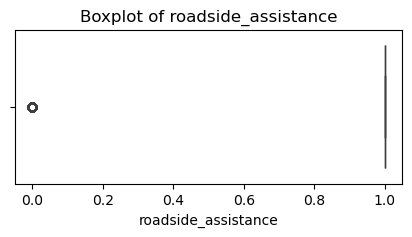

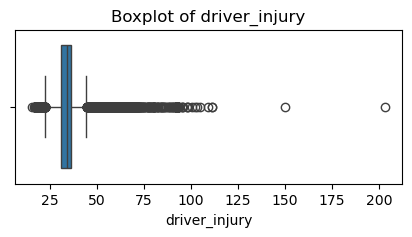

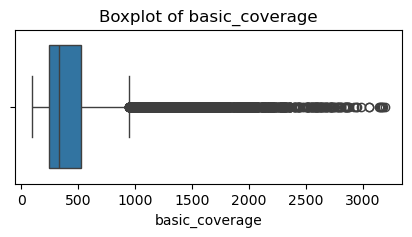

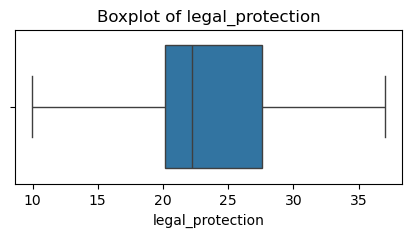

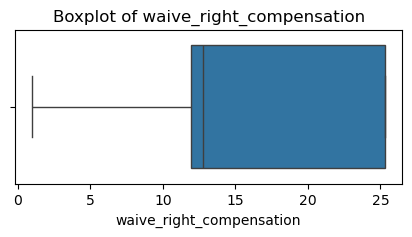

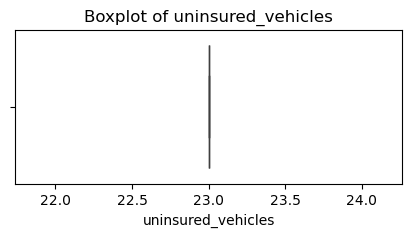

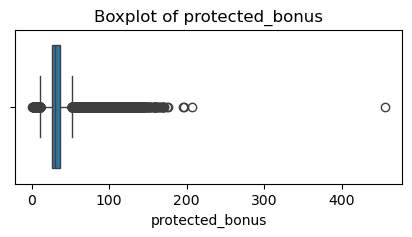

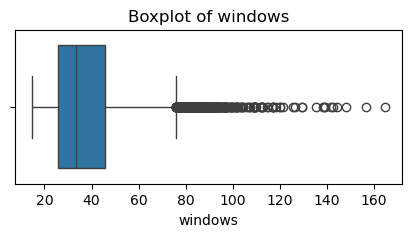

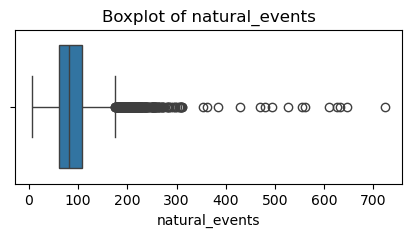

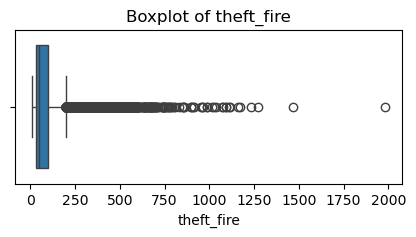

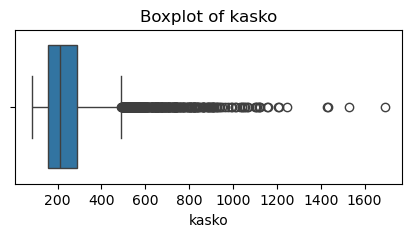

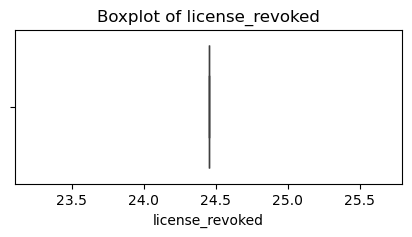

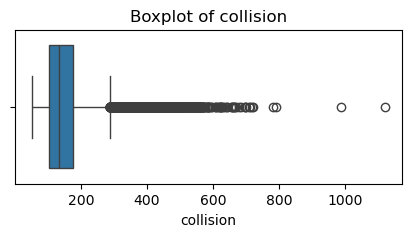

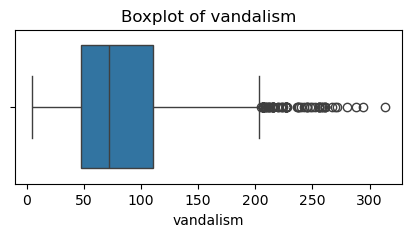

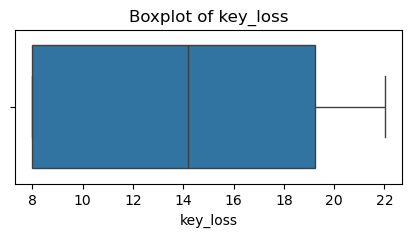

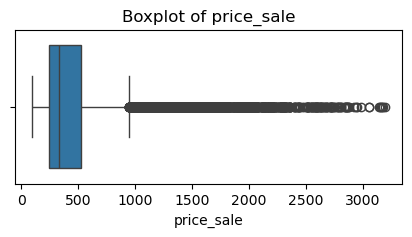

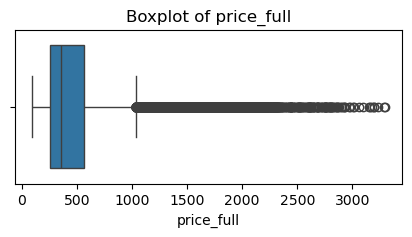

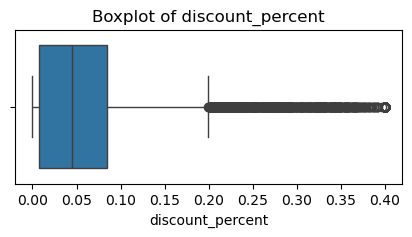

In [1196]:
for col in quote_numeric_cols:
    plt.figure(figsize=(5, 2))
    sns.boxplot(x=quotes_df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.show()

### 3.5.2 Outliers in Transaction Related Numeric Variables

In [1197]:
transaction_numeric_cols = [
    "number_transactions",
    "expenditures"
]

transaction_validity = transactions_df[transaction_numeric_cols].agg(["min", "max"]).T
transaction_validity

,min,max
number_transactions,1.0,115.000000
expenditures,0.0,1366.426994


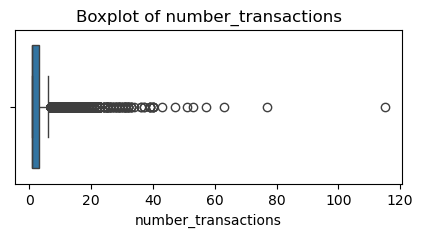

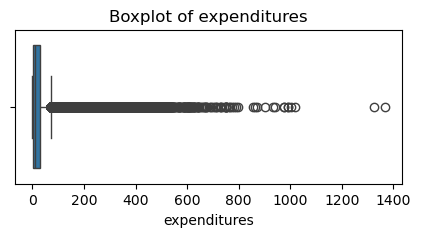

In [1198]:
for col in transaction_numeric_cols:
    plt.figure(figsize=(5, 2))
    sns.boxplot(x=transactions_df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.show()

The validity checks do not reveal obvious impossible values. All quote related prices, discount measures, transaction counts and expenditures are non-negative, which is consistent with the business meaning of these variables. Some fields, such as license_revoked and uninsured_vehicles, take a single fixed value whenever they are present, which is consistent with fixed-price optional coverages rather than data errors.

The boxplots show that many quote related numeric variables are strongly right-skewed, with a concentration of observations at lower or moderate values and a long upper tail. This pattern is especially visible for variables such as driver_injury, basic_coverage, protected_bonus, windows, natural_events, theft_fire, kasko, collision, vandalism, price_sale and price_full. The transaction variables number_transactions and expenditures also display clear right-skewness, with a small number of customers showing much higher activity and spending than the rest.

These observations will not be removed. In this context, many of the apparent outliers are likely to reflect genuine variation in quoted prices or customer activity rather than data-entry errors. The main implication is that some variables may later benefit from handling, scaling or transformation but the current evidence does not justify dropping observations purely on the basis of boxplot outliers.

## 3.6 Data Cleaning and Feature Engineering

Having assessed data quality, missingness and potential outliers, I implement the main cleaning and feature-engineering steps needed to build an analysis-ready dataset. The aim is to preserve the business meaning of the original variables while transforming the raw quote and transaction data into features suitable for later exploratory analysis and predictive modelling.

### 3.6.1 Date Conversion and Standardisation

The first implementation step is to convert all date-like variables into a consistent datetime format. This is necessary because several later features, such as customer age, vehicle age, subscription tenure and days until insurance expiry, depend on accurate date calculations.

In [ ]:
# copying the original datasets before applying transformations
quotes_clean = quotes_df.copy()
transactions_clean = transactions_df.copy()

In [ ]:
# date columns that are in the quotes dataset
quote_date_cols = [
    "car_immatriculation_date",
    "insurance_expires_at",
    "birth_date",
    "base_subscription",
    "pay_subscription",
    "pay_cancellation",
    "premium_subscription",
    "premium_cancellation",
    "policy_quoted_at"
]

# converting quote date columns to datetime
for col in quote_date_cols:
    quotes_clean[col] = pd.to_datetime(quotes_clean[col], errors="coerce")

In [ ]:
#converting year_month in transactions to datetime
transactions_clean["year_month"] = pd.to_datetime(
    transactions_clean["year_month"],
    format="%b-%y",
    errors="coerce"
)

In [ ]:
# cehking of dtypes after conversion
print("Quote date columns:")
print(quotes_clean[quote_date_cols].dtypes)

print("\nTransactions date column:")
print(transactions_clean[["year_month"]].dtypes)

Quote date columns:
car_immatriculation_date    datetime64[us]
insurance_expires_at        datetime64[us]
birth_date                  datetime64[us]
base_subscription           datetime64[us]
pay_subscription            datetime64[us]
pay_cancellation            datetime64[us]
premium_subscription        datetime64[us]
premium_cancellation        datetime64[us]
policy_quoted_at            datetime64[us]
dtype: object

Transactions date column:
year_month    datetime64[us]
dtype: object


In [ ]:
# showing converted date columns
quotes_clean[quote_date_cols].head()

,car_immatriculation_date,insurance_expires_at,birth_date,base_subscription,pay_subscription,pay_cancellation,premium_subscription,premium_cancellation,policy_quoted_at
0,2011-07-20,2020-06-12,NaT,2019-06-24,NaT,NaT,2020-06-11,9998-12-31,2020-03-15
1,2007-03-01,2020-01-22,NaT,2012-11-12,NaT,NaT,2014-12-29,9998-12-31,2020-01-08
2,2017-08-30,2020-10-02,1992-09-22,2019-08-26,2019-08-26,9998-12-31,NaT,NaT,2020-04-29
3,2017-07-25,2020-07-25,1996-02-09,2017-09-12,NaT,NaT,2017-09-13,9998-12-31,2020-03-17
4,2006-12-19,2020-10-13,2000-01-08,2019-08-29,NaT,NaT,NaT,NaT,2020-02-09


In [1204]:
transactions_clean[["year_month"]].head()

,year_month
0,2020-05-01
1,2019-09-01
2,2020-02-01
3,2020-01-01
4,2020-02-01


The date conversion was applied using errors="coerce" so that invalid or placeholder formats are safely converted to missing datetime values rather than causing parsing errors. This creates a consistent basis for the next feature engineering steps.

### 3.6.2 Handling Subscription Related Variables

In this step, the raw subscription date variables are transformed into more interpretable features. Rather than treating missing values as ordinary incomplete dates, I use them to capture whether the customer had subscribed to Pay or Premium services at all. I also use the cancellation fields, including the placeholder date 9998-12-31, to identify whether each subscription was still active at the time of the quote. Finally, I create tenure variables that measure how long the customer had been subscribed by the quote date. This produces features that are more meaningful for later analysis than the raw date fields alone.

In [1346]:
# Placeholder cancellation date used to indicate "not cancelled yet"
placeholder_date = pd.Timestamp("9998-12-31")

In [ ]:
# a customer is counted as subscribed only if the subscription date exists and is on or before the quote date
quotes_clean["has_pay_subscription"] = (
    quotes_clean["pay_subscription"].notna() &
    (quotes_clean["pay_subscription"] <= quotes_clean["policy_quoted_at"])
).astype(int)

quotes_clean["has_premium_subscription"] = (
    quotes_clean["premium_subscription"].notna() &
    (quotes_clean["premium_subscription"] <= quotes_clean["policy_quoted_at"])
).astype(int)

In [ ]:
# a subscription is active at quote time if the customer had already subscribed by the quote date 
# and there is no cancellation date  or the cancellation date is the placeholder 9998-12-31 or 
# the cancellation happened after the quote date

quotes_clean["pay_active_at_quote"] = (
    (quotes_clean["has_pay_subscription"] == 1) &
    (
        quotes_clean["pay_cancellation"].isna() |
        (quotes_clean["pay_cancellation"] == placeholder_date) |
        (quotes_clean["pay_cancellation"] > quotes_clean["policy_quoted_at"])
    )
).astype(int)

quotes_clean["premium_active_at_quote"] = (
    (quotes_clean["has_premium_subscription"] == 1) &
    (
        quotes_clean["premium_cancellation"].isna() |
        (quotes_clean["premium_cancellation"] == placeholder_date) |
        (quotes_clean["premium_cancellation"] > quotes_clean["policy_quoted_at"])
    )
).astype(int)

In [ ]:
# base subscription tenure is only valid if base_subscription exists and is on or before quote date
quotes_clean["base_tenure_days"] = np.where(
    quotes_clean["base_subscription"].notna() &
    (quotes_clean["base_subscription"] <= quotes_clean["policy_quoted_at"]),
    (quotes_clean["policy_quoted_at"] - quotes_clean["base_subscription"]).dt.days,
    np.nan
)

# Pay subscription tenure is only valid if the customer had already subscribed by the quote date
quotes_clean["pay_tenure_days"] = np.where(
    quotes_clean["has_pay_subscription"] == 1,
    (quotes_clean["policy_quoted_at"] - quotes_clean["pay_subscription"]).dt.days,
    np.nan
)

# premium subscription tenure is only valid if the customer had already subscribed by the quote date
quotes_clean["premium_tenure_days"] = np.where(
    quotes_clean["has_premium_subscription"] == 1,
    (quotes_clean["policy_quoted_at"] - quotes_clean["premium_subscription"]).dt.days,
    np.nan
)

In [1350]:
for col in ["base_tenure_days", "pay_tenure_days", "premium_tenure_days"]:
    print(col, "negative values:", (quotes_clean[col] < 0).sum())

base_tenure_days negative values: 0
pay_tenure_days negative values: 0
premium_tenure_days negative values: 0


In [1351]:
subscription_feature_cols = [
    "has_pay_subscription",
    "has_premium_subscription",
    "pay_active_at_quote",
    "premium_active_at_quote",
    "base_tenure_days",
    "pay_tenure_days",
    "premium_tenure_days"
]

quotes_clean[subscription_feature_cols].head()

,has_pay_subscription,has_premium_subscription,pay_active_at_quote,premium_active_at_quote,base_tenure_days,pay_tenure_days,premium_tenure_days
0,0,0,0,0,265.0,NaN,NaN
1,0,1,0,1,2613.0,NaN,1836.0
2,1,0,1,0,247.0,247.0,NaN
3,0,1,0,1,917.0,NaN,916.0
4,0,0,0,0,164.0,NaN,NaN


In [1352]:
for col in [
    "has_pay_subscription",
    "has_premium_subscription",
    "pay_active_at_quote",
    "premium_active_at_quote"
]:
    print(f"\n{col}")
    print(quotes_clean[col].value_counts(dropna=False))


has_pay_subscription
has_pay_subscription
0    26486
1     9687
Name: count, dtype: int64

has_premium_subscription
has_premium_subscription
1    20707
0    15466
Name: count, dtype: int64

pay_active_at_quote
pay_active_at_quote
0    26489
1     9684
Name: count, dtype: int64

premium_active_at_quote
premium_active_at_quote
0    19722
1    16451
Name: count, dtype: int64


The engineered subscription variables behave as expected. Around 27% of customers had already subscribed to Pay by the quote date and almost all of them were still active at that time. Premium subscriptions were more common, with about 57% of customers having subscribed by the quote date, although a smaller share remained active. The tenure variables are only defined for customers who had already subscribed by the quote date, so missing values in those fields are expected for non-subscribers.

The binary subscription-status variables are encoded using 0 and 1 but the tenure variables are left missing for customers who had not subscribed by the quote date. This is intentional, since a tenure of zero would imply a subscription starting exactly on the quote date, which is different from not being subscribed at all.

### 3.6.3 Handling Optional Insurance Coverage Variables

The optional insurance coverage variables are not treated as ordinary missing numerical fields. Earlier checks suggested that missing values in these columns usually indicate that a given coverage was not included in the quote, while non-missing values correspond to valid quoted amounts. I preserve this business meaning by creating coverage-included indicators and replacing missing amounts with zero.

In [1212]:
optional_coverage_cols = [
    "license_revoked",
    "key_loss",
    "uninsured_vehicles",
    "vandalism",
    "kasko",
    "natural_events",
    "protected_bonus",
    "waive_right_compensation",
    "collision",
    "windows",
    "theft_fire",
    "legal_protection",
    "driver_injury"
]

In [ ]:
#creating included/not included indicators
for col in optional_coverage_cols:
    quotes_clean[f"{col}_included"] = quotes_clean[col].notna().astype(int)

In [ ]:
# replacing missing quoted amounts with 0 to represent non-inclusion
for col in optional_coverage_cols:
    quotes_clean[col] = quotes_clean[col].fillna(0)# Replace missing quoted amounts with 0 to represent non-inclusion

In [ ]:
# checking the transformed variables
optional_feature_preview = optional_coverage_cols + [f"{col}_included" for col in optional_coverage_cols[:5]]
quotes_clean[optional_feature_preview].head()

,license_revoked,key_loss,uninsured_vehicles,vandalism,kasko,natural_events,protected_bonus,waive_right_compensation,collision,windows,theft_fire,legal_protection,driver_injury,license_revoked_included,key_loss_included,uninsured_vehicles_included,vandalism_included,kasko_included
0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,25.30,121.83,68.10,22.70,28.33,37.50,0,0,0,0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,37.04,11.92,89.99,34.42,22.70,24.43,33.73,0,0,0,0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.00,25.30,0.00,0.00,0.00,29.50,36.25,0,0,0,0,0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0,0,0
4,0.0,0.0,0.0,0.0,0.0,0.0,25.45,25.30,156.11,36.36,24.34,24.72,39.13,0,0,0,0,0


In [ ]:
#  summaries for a few indicator variables
for col in [
    "license_revoked_included",
    "key_loss_included",
    "uninsured_vehicles_included",
    "vandalism_included",
    "kasko_included"
]:
    print(f"\n{col}")
    print(quotes_clean[col].value_counts(dropna=False))


license_revoked_included
license_revoked_included
0    33334
1     2839
Name: count, dtype: int64

key_loss_included
key_loss_included
0    33194
1     2979
Name: count, dtype: int64

uninsured_vehicles_included
uninsured_vehicles_included
0    33025
1     3148
Name: count, dtype: int64

vandalism_included
vandalism_included
0    31304
1     4869
Name: count, dtype: int64

kasko_included
kasko_included
0    29073
1     7100
Name: count, dtype: int64


In [1217]:
quotes_clean[optional_coverage_cols].isna().sum().sort_values(ascending=False).head() 

license_revoked       0
key_loss              0
uninsured_vehicles    0
vandalism             0
kasko                 0
dtype: int64

The optional coverage variables were transformed in a way that preserves their business meaning. For each coverage, a binary indicator was created to show whether the coverage was included in the quote and missing quoted amounts were replaced with zero to represent non-inclusion. This approach is more appropriate than standard numerical imputation because missingness in these fields appears to reflect absence of the coverage rather than random data loss.

### 3.6.4 Handling Demographic Variables

The demographic variables are handled differently from the previous variable groups because their missingness appears to reflect incomplete customer information rather than structural business states. I derive a more interpretable age feature from birth_date and make missing categories explicit for the categorical fields gender and county.

In [ ]:
# creating age at quote time from birth_date
quotes_clean["age_at_quote"] = np.where(
    quotes_clean["birth_date"].notna() &
    (quotes_clean["birth_date"] <= quotes_clean["policy_quoted_at"]),
    ((quotes_clean["policy_quoted_at"] - quotes_clean["birth_date"]).dt.days / 365.25),
    np.nan
)

In [ ]:
# round age for readability
quotes_clean["age_at_quote"] = quotes_clean["age_at_quote"].round(0)

In [ ]:
# making missing categories explicit for categorical demographic fields
quotes_clean["gender"] = quotes_clean["gender"].fillna("Unknown")
quotes_clean["county"] = quotes_clean["county"].fillna("Unknown")

In [ ]:
quotes_clean[["birth_date", "policy_quoted_at", "age_at_quote", "gender", "county"]].head()

,birth_date,policy_quoted_at,age_at_quote,gender,county
0,NaT,2020-03-15,NaN,Unknown,FC
1,NaT,2020-01-08,NaN,Unknown,MS
2,1992-09-22,2020-04-29,28.0,M,SA
3,1996-02-09,2020-03-17,24.0,M,Unknown
4,2000-01-08,2020-02-09,20.0,M,CN


In [ ]:
# summary of transformed demographic variables
print("Missing values in age_at_quote:", quotes_clean["age_at_quote"].isna().sum())

print("\nGender distribution:")
print(quotes_clean["gender"].value_counts(dropna=False))

print("\nCounty distribution:")
print(quotes_clean["county"].value_counts(dropna=False).head(10))

Missing values in age_at_quote: 13643

Gender distribution:
gender
M          18938
Unknown    13581
F           3654
Name: count, dtype: int64

County distribution:
county
MI         3735
RM         3437
Unknown    2827
TO         1893
VA         1239
MB          997
BG          898
BO          849
FI          836
SA          756
Name: count, dtype: int64


In [1223]:
quotes_clean["age_at_quote"].describe()

count    22530.000000
mean        46.402264
std         12.604468
min         14.000000
25%         37.000000
50%         46.000000
75%         55.000000
max        145.000000
Name: age_at_quote, dtype: float64

In [1224]:
print("Ages below 16:", (quotes_clean["age_at_quote"] < 16).sum())
print("Ages above 100:", (quotes_clean["age_at_quote"] > 100).sum())

Ages below 16: 1
Ages above 100: 1


In [1225]:
invalid_age_rows = quotes_clean.loc[
    (quotes_clean["age_at_quote"] < 16) | (quotes_clean["age_at_quote"] > 100),
    ["client_id", "quotation_id", "birth_date", "policy_quoted_at", "age_at_quote", "driving_type"]
]

invalid_age_rows

,client_id,quotation_id,birth_date,policy_quoted_at,age_at_quote,driving_type
12299,10987,27520,1874-12-12,2020-05-04,145.0,more_than_26
34216,34416,17836,2006-07-16,2020-04-10,14.0,more_than_26


In [1226]:
invalid_age_mask = (quotes_clean["age_at_quote"] < 16) | (quotes_clean["age_at_quote"] > 100)
quotes_clean.loc[invalid_age_mask, "age_at_quote"] = np.nan
quotes_clean.loc[invalid_age_mask, "birth_date"] = pd.NaT

In [1227]:
print("Ages below 16:", (quotes_clean["age_at_quote"] < 16).sum())
print("Ages above 100:", (quotes_clean["age_at_quote"] > 100).sum())

Ages below 16: 0
Ages above 100: 0


Inspection of the extreme age values shows that two observations are implausible: one derived age of 145 and one derived age of 14. The latter is also inconsistent with the recorded driving type of more_than_26, which further suggests a data-quality problem in the raw birth date. These cases are therefore treated as invalid demographic information and the corresponding age values are set to missing rather than retained as genuine observations.

### 3.6.5 Creating Quote Level Engineered Features

Next, I derive additional quote-level features from the cleaned quote data. The purpose of this step is to convert raw dates and price information into variables that are easier to interpret and more useful for later analysis. In particular, I create features related to vehicle age, time until insurance expiry and the monetary value of the discount offered in the quote.

**Vehicle Age at Quote**

In [ ]:
# vehicle age in completed years at the quote date
quotes_clean["vehicle_age_at_quote"] = (
    quotes_clean["policy_quoted_at"].dt.year - quotes_clean["car_immatriculation_date"].dt.year
    - (
        (quotes_clean["policy_quoted_at"].dt.month < quotes_clean["car_immatriculation_date"].dt.month) |
        (
            (quotes_clean["policy_quoted_at"].dt.month == quotes_clean["car_immatriculation_date"].dt.month) &
            (quotes_clean["policy_quoted_at"].dt.day < quotes_clean["car_immatriculation_date"].dt.day)
        )
    ).astype(int)
)

quotes_clean.loc[quotes_clean["car_immatriculation_date"].isna(), "vehicle_age_at_quote"] = np.nan

**Days until Insurance Expiry**

In [ ]:
# raw difference between expiry date and quote date
quotes_clean["days_to_insurance_expiry"] = (
    quotes_clean["insurance_expires_at"] - quotes_clean["policy_quoted_at"]
).dt.days

#  was the current insurance already expired at quote time?
quotes_clean["insurance_already_expired"] = np.where(
    quotes_clean["days_to_insurance_expiry"].notna() &
    (quotes_clean["days_to_insurance_expiry"] < 0),
    1,
    0
)

# keeping remaining days only for still-active insurance
quotes_clean["days_to_insurance_expiry_active"] = np.where(
    quotes_clean["days_to_insurance_expiry"].notna() &
    (quotes_clean["days_to_insurance_expiry"] >= 0),
    quotes_clean["days_to_insurance_expiry"],
    np.nan
)

# how many days had passed since insurance already expired
quotes_clean["days_since_insurance_expiry"] = np.where(
    quotes_clean["days_to_insurance_expiry"].notna() &
    (quotes_clean["days_to_insurance_expiry"] < 0),
    -quotes_clean["days_to_insurance_expiry"],
    np.nan
)

**Discount Amount**

In [1230]:
# Absolute discount amount
quotes_clean["discount_amount"] = quotes_clean["price_full"] - quotes_clean["price_sale"]

In [1231]:
quote_engineered_cols = [
    "age_at_quote",
    "vehicle_age_at_quote",
    "insurance_already_expired",
    "days_to_insurance_expiry_active",
    "days_since_insurance_expiry",
    "discount_amount",
    "discount_percent"
]

quotes_clean[quote_engineered_cols].head()

,age_at_quote,vehicle_age_at_quote,insurance_already_expired,days_to_insurance_expiry_active,days_since_insurance_expiry,discount_amount,discount_percent
0,NaN,8.0,0,89.0,NaN,0.00,0.000000
1,NaN,12.0,0,14.0,NaN,35.55,0.115874
2,28.0,2.0,0,156.0,NaN,43.17,0.063113
3,24.0,2.0,0,130.0,NaN,19.49,0.008840
4,20.0,13.0,0,247.0,NaN,23.52,0.101730


In [1232]:
quotes_clean[quote_engineered_cols].describe()

,age_at_quote,vehicle_age_at_quote,insurance_already_expired,days_to_insurance_expiry_active,days_since_insurance_expiry,discount_amount,discount_percent
count,22528.000000,34463.000000,36173.000000,32952.000000,3176.000000,36173.000000,36173.000000
mean,46.399325,7.648609,0.087800,65.617808,49.921914,30.387921,0.055436
std,12.586046,5.278409,0.283008,90.623732,143.655764,55.249458,0.059545
min,19.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,37.000000,3.000000,0.000000,13.000000,3.000000,2.590000,0.007207
50%,46.000000,7.000000,0.000000,28.000000,8.000000,15.910000,0.045303
75%,55.000000,11.000000,0.000000,64.000000,18.000000,35.030000,0.084204
max,91.000000,40.000000,1.000000,687.000000,2069.000000,947.970000,0.400020


In [1233]:
print("Vehicle ages below 0:", (quotes_clean["vehicle_age_at_quote"] < 0).sum())
print("Vehicle ages above 50:", (quotes_clean["vehicle_age_at_quote"] > 50).sum())

print("Days to insurance expiry below 0:", (quotes_clean["days_to_insurance_expiry"] < 0).sum())

Vehicle ages below 0: 0
Vehicle ages above 50: 0
Days to insurance expiry below 0: 3176


In [1234]:
negative_expiry_rows = quotes_clean.loc[
    quotes_clean["days_to_insurance_expiry"] < 0,
    ["client_id", "quotation_id", "policy_quoted_at", "insurance_expires_at", "days_to_insurance_expiry"]
].sort_values("days_to_insurance_expiry")

negative_expiry_rows.head(20)

,client_id,quotation_id,policy_quoted_at,insurance_expires_at,days_to_insurance_expiry
5010,34609,21102,2020-03-06,2014-07-07,-2069.0
16326,17594,30253,2020-02-04,2014-06-24,-2051.0
17842,7884,18640,2020-01-10,2015-04-13,-1733.0
285,9607,27841,2020-05-01,2016-02-09,-1543.0
35272,29600,34338,2020-04-01,2016-02-04,-1518.0
15045,1159,7719,2020-04-22,2016-04-17,-1466.0
24549,16606,26525,2020-03-19,2016-04-07,-1442.0
25809,24616,1567,2020-03-07,2016-05-01,-1406.0
29991,1234,30504,2020-03-02,2016-07-10,-1331.0
5144,24506,29067,2020-02-27,2016-11-07,-1207.0


In [1235]:
# Indicator: was the current insurance already expired at quote time?
quotes_clean["insurance_already_expired"] = (
    quotes_clean["days_to_insurance_expiry"] < 0
).astype(int)

In [1236]:
print("Expired at quote:", quotes_clean["insurance_already_expired"].sum())

Expired at quote: 3176


The insurance expiry date was transformed into separate features rather than being used as a single raw day difference. A binary indicator was created to show whether the previous insurance was already expired at the quote date. For policies that were still active, the remaining number of days until expiry was retained. For policies that had already expired, a separate variable measured how many days had passed since expiry. This avoids mixing positive and negative durations in one variable and preserves the business meaning of both situations more clearly.

### 3.6.6 Preparing Transaction Based Behavioural Features

Because the Transactions table contains multiple rows per customer, it cannot be merged directly with the quote-level data without duplicating observations. First it is prepared for aggregation. Since transaction activity is recorded only at month level, I only use months strictly before the quote month when constructing behavioural features, in order to avoid using information that may occur after the quote date within the same month.

In [ ]:
# creating a separate working copy for transaction feature preparation
transactions_features = transactions_clean.copy()

In [ ]:
# standardising the transaction month to month-start timestamps
transactions_features["transaction_month"] = (
    transactions_features["year_month"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

In [1239]:
service_raw = transactions_features["service_type"]

transactions_features["service_type_clean"] = np.where(
    service_raw.notna(),
    service_raw.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
        .str.strip("_"),
    np.nan
)

In [ ]:
# creating a helper variable: average spend per transaction row
transactions_features["avg_spend_per_transaction"] = np.where(
    transactions_features["number_transactions"] > 0,
    transactions_features["expenditures"] / transactions_features["number_transactions"],
    np.nan
)

In [ ]:
# previewing of the prepared transaction table
transactions_features[
    [
        "client_id",
        "transaction_month",
        "service_type",
        "service_type_clean",
        "telepass_pay",
        "number_transactions",
        "expenditures",
        "avg_spend_per_transaction"
    ]
].head()

,client_id,transaction_month,service_type,service_type_clean,telepass_pay,number_transactions,expenditures,avg_spend_per_transaction
0,20785,2020-05-01,PARCHEGGI/TRAGHETTI,parcheggi_traghetti,0,1,2.00,2.00
1,20785,2019-09-01,PARCHEGGI/TRAGHETTI,parcheggi_traghetti,0,1,2.00,2.00
2,34153,2020-02-01,PARCHEGGI/TRAGHETTI,parcheggi_traghetti,0,1,3.75,3.75
3,21141,2020-01-01,PARCHEGGI/TRAGHETTI,parcheggi_traghetti,0,1,3.50,3.50
4,21141,2020-02-01,PARCHEGGI/TRAGHETTI,parcheggi_traghetti,0,1,7.00,7.00


In [ ]:
# basic checks in transactions features
print("Rows in prepared transactions table:", len(transactions_features))
print("Unique clients:", transactions_features["client_id"].nunique())
print("Unique transaction months:", transactions_features["transaction_month"].nunique())

print("\nTop cleaned service types:")
print(transactions_features["service_type_clean"].value_counts().head(10))

Rows in prepared transactions table: 49707
Unique clients: 12951
Unique transaction months: 13

Top cleaned service types:
service_type_clean
parcheggi_traghetti        19452
parcheggio_strisce_blu     13738
fuel_con_app                6567
turbo_ricarica_carta        3319
assicurazione_infortuni     3238
bollo_auto                  1332
accesso_area_c_milano        730
mobilit_condivisa            384
treni                        170
trasporto_pubblico           141
Name: count, dtype: int64


### 3.6.7 Merging The Analysis Ready Dataset

Transaction records are linked to quotes by client_id but they are not merged directly in raw form because this would duplicate quote rows. Instead, each customer’s prior transaction history is restricted to months before the quote month and then aggregated into behavioural features. The resulting summary table is finally merged back to the quote-level dataset so that the final analysis-ready data remain at one row per quote.

In [ ]:
#quote side helper table
quotes_for_merge = quotes_clean[["quotation_id", "client_id", "policy_quoted_at"]].copy()

# quote month at month-start
quotes_for_merge["quote_month"] = (
    quotes_for_merge["policy_quoted_at"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

quotes_for_merge.head()

,quotation_id,client_id,policy_quoted_at,quote_month
0,3649,23789,2020-03-15,2020-03-01
1,28552,10133,2020-01-08,2020-01-01
2,31958,20785,2020-04-29,2020-04-01
3,27614,33892,2020-03-17,2020-03-01
4,1529,34153,2020-02-09,2020-02-01


In [ ]:
# linking quotes to all transactions for the same client
quote_tx_link = quotes_for_merge.merge(
    transactions_features,
    on="client_id",
    how="left"
)

quote_tx_link.head()

,quotation_id,client_id,policy_quoted_at,quote_month,year_month,service_type,telepass_pay,number_transactions,expenditures,transaction_month,service_type_clean,avg_spend_per_transaction
0,3649,23789,2020-03-15,2020-03-01,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN
1,28552,10133,2020-01-08,2020-01-01,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN
2,31958,20785,2020-04-29,2020-04-01,2020-05-01,PARCHEGGI/TRAGHETTI,0.0,1.0,2.0,2020-05-01,parcheggi_traghetti,2.0
3,31958,20785,2020-04-29,2020-04-01,2019-09-01,PARCHEGGI/TRAGHETTI,0.0,1.0,2.0,2019-09-01,parcheggi_traghetti,2.0
4,27614,33892,2020-03-17,2020-03-01,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN


In [ ]:
# keeping only transaction history strictly before the quote month and this is conservative and avoids same month leakage
quote_tx_history = quote_tx_link.loc[
    quote_tx_link["transaction_month"].notna() &
    (quote_tx_link["transaction_month"] < quote_tx_link["quote_month"])
].copy()

quote_tx_history.head()

,quotation_id,client_id,policy_quoted_at,quote_month,year_month,service_type,telepass_pay,number_transactions,expenditures,transaction_month,service_type_clean,avg_spend_per_transaction
3,31958,20785,2020-04-29,2020-04-01,2019-09-01,PARCHEGGI/TRAGHETTI,0.0,1.0,2.00,2019-09-01,parcheggi_traghetti,2.00000
12,10960,21141,2020-01-15,2020-01-01,2019-10-01,PARCHEGGI/TRAGHETTI,0.0,1.0,2.80,2019-10-01,parcheggi_traghetti,2.80000
15,11661,12199,2020-04-05,2020-04-01,2020-02-01,FUEL CON APP,1.0,5.0,15.00,2020-02-01,fuel_con_app,3.00000
16,11661,12199,2020-04-05,2020-04-01,2020-03-01,FUEL CON APP,1.0,8.0,30.01,2020-03-01,fuel_con_app,3.75125
23,24382,22347,2020-06-10,2020-06-01,2020-05-01,ASSICURAZIONE INFORTUNI,0.0,1.0,0.00,2020-05-01,assicurazione_infortuni,0.00000


In [ ]:
# aggregating prior transaction history to one row per quote
transaction_agg = (
    quote_tx_history
    .groupby(["quotation_id", "quote_month"], as_index=False)
    .agg(
        tx_history_rows=("transaction_month", "size"),
        tx_active_months=("transaction_month", "nunique"),
        tx_service_diversity=("service_type_clean", "nunique"),
        tx_total_transactions=("number_transactions", "sum"),
        tx_total_expenditures=("expenditures", "sum"),
        tx_last_transaction_month=("transaction_month", "max"),
        tx_telepass_pay_transactions=(
            "number_transactions",
            lambda s: s[quote_tx_history.loc[s.index, "telepass_pay"] == 1].sum()
        )
    )
)

transaction_agg["tx_avg_spend_per_transaction"] = np.where(
    transaction_agg["tx_total_transactions"] > 0,
    transaction_agg["tx_total_expenditures"] / transaction_agg["tx_total_transactions"],
    np.nan
)

transaction_agg["tx_telepass_pay_share"] = np.where(
    transaction_agg["tx_total_transactions"] > 0,
    transaction_agg["tx_telepass_pay_transactions"] / transaction_agg["tx_total_transactions"],
    np.nan
)

transaction_agg.head()


,quotation_id,quote_month,tx_history_rows,tx_active_months,tx_service_diversity,tx_total_transactions,tx_total_expenditures,tx_last_transaction_month,tx_telepass_pay_transactions,tx_avg_spend_per_transaction,tx_telepass_pay_share
0,3,2020-02-01,5,5,1,9.0,15.600000,2020-01-01,0.0,1.733333,0.0
1,5,2020-05-01,5,5,1,14.0,450.000000,2020-04-01,0.0,32.142857,0.0
2,15,2020-05-01,3,3,1,4.0,4.000000,2019-11-01,4.0,1.000000,1.0
3,17,2020-03-01,2,2,1,2.0,14.000000,2019-11-01,0.0,7.000000,0.0
4,25,2020-03-01,1,1,1,1.0,39.869876,2020-02-01,0.0,39.869876,0.0


In [ ]:
# months since the last observed transaction month
transaction_agg["months_since_last_transaction"] = (
    (transaction_agg["quote_month"].dt.year - transaction_agg["tx_last_transaction_month"].dt.year) * 12
    + (transaction_agg["quote_month"].dt.month - transaction_agg["tx_last_transaction_month"].dt.month)
)

transaction_agg.head()

,quotation_id,quote_month,tx_history_rows,tx_active_months,tx_service_diversity,tx_total_transactions,tx_total_expenditures,tx_last_transaction_month,tx_telepass_pay_transactions,tx_avg_spend_per_transaction,tx_telepass_pay_share,months_since_last_transaction
0,3,2020-02-01,5,5,1,9.0,15.600000,2020-01-01,0.0,1.733333,0.0,1
1,5,2020-05-01,5,5,1,14.0,450.000000,2020-04-01,0.0,32.142857,0.0,1
2,15,2020-05-01,3,3,1,4.0,4.000000,2019-11-01,4.0,1.000000,1.0,6
3,17,2020-03-01,2,2,1,2.0,14.000000,2019-11-01,0.0,7.000000,0.0,4
4,25,2020-03-01,1,1,1,1.0,39.869876,2020-02-01,0.0,39.869876,0.0,1


In [ ]:
#merging aggregated behavioural features back to the quote-level data
analysis_ready_df = quotes_clean.merge(
    transaction_agg.drop(columns=["quote_month"]),
    on="quotation_id",
    how="left"
)

analysis_ready_df.head()

,client_id,quotation_id,driving_type,car_immatriculation_date,car_brand,car_model,insurance_expires_at,birth_date,gender,county,...,tx_history_rows,tx_active_months,tx_service_diversity,tx_total_transactions,tx_total_expenditures,tx_last_transaction_month,tx_telepass_pay_transactions,tx_avg_spend_per_transaction,tx_telepass_pay_share,months_since_last_transaction
0,23789,3649,more_than_26,2011-07-20,FORD,C-MAX,2020-06-12,NaT,Unknown,FC,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
1,10133,28552,more_than_26,2007-03-01,FIAT - INNOCENTI,FIAT CROMA,2020-01-22,NaT,Unknown,MS,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
2,20785,31958,more_than_26,2017-08-30,NISSAN,NISSAN QASHQAI,2020-10-02,1992-09-22,M,SA,...,1.0,1.0,1.0,1.0,2.0,2019-09-01,0.0,2.0,0.0,7.0
3,33892,27614,more_than_26,2017-07-25,FIAT - INNOCENTI,FIAT PANDA,2020-07-25,1996-02-09,M,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
4,34153,1529,more_than_26,2006-12-19,FIAT - INNOCENTI,FIAT PUNTO,2020-10-13,2000-01-08,M,CN,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN


In [ ]:
# filling count or total features with 0 when no prior transaction history exists
zero_fill_cols = [
    "tx_history_rows",
    "tx_active_months",
    "tx_service_diversity",
    "tx_total_transactions",
    "tx_total_expenditures"
]

analysis_ready_df[zero_fill_cols] = analysis_ready_df[zero_fill_cols].fillna(0)

# history indicator 
analysis_ready_df["tx_history_available"] = (
    analysis_ready_df["tx_history_rows"] > 0
).astype(int)

analysis_ready_df.head()

,client_id,quotation_id,driving_type,car_immatriculation_date,car_brand,car_model,insurance_expires_at,birth_date,gender,county,...,tx_active_months,tx_service_diversity,tx_total_transactions,tx_total_expenditures,tx_last_transaction_month,tx_telepass_pay_transactions,tx_avg_spend_per_transaction,tx_telepass_pay_share,months_since_last_transaction,tx_history_available
0,23789,3649,more_than_26,2011-07-20,FORD,C-MAX,2020-06-12,NaT,Unknown,FC,...,0.0,0.0,0.0,0.0,NaT,NaN,NaN,NaN,NaN,0
1,10133,28552,more_than_26,2007-03-01,FIAT - INNOCENTI,FIAT CROMA,2020-01-22,NaT,Unknown,MS,...,0.0,0.0,0.0,0.0,NaT,NaN,NaN,NaN,NaN,0
2,20785,31958,more_than_26,2017-08-30,NISSAN,NISSAN QASHQAI,2020-10-02,1992-09-22,M,SA,...,1.0,1.0,1.0,2.0,2019-09-01,0.0,2.0,0.0,7.0,1
3,33892,27614,more_than_26,2017-07-25,FIAT - INNOCENTI,FIAT PANDA,2020-07-25,1996-02-09,M,Unknown,...,0.0,0.0,0.0,0.0,NaT,NaN,NaN,NaN,NaN,0
4,34153,1529,more_than_26,2006-12-19,FIAT - INNOCENTI,FIAT PUNTO,2020-10-13,2000-01-08,M,CN,...,0.0,0.0,0.0,0.0,NaT,NaN,NaN,NaN,NaN,0


In [ ]:
# cheking the analtysis-ready dataset
print("Rows in analysis_ready_df:", len(analysis_ready_df))
print("Unique quotation_id:", analysis_ready_df["quotation_id"].nunique())
print("Quotes with prior transaction history:", analysis_ready_df["tx_history_available"].sum())

analysis_ready_df[
    [
        "quotation_id",
        "client_id",
        "tx_history_available",
        "tx_active_months",
        "tx_total_transactions",
        "tx_total_expenditures",
        "tx_service_diversity",
        "months_since_last_transaction"
    ]
].head()

Rows in analysis_ready_df: 36173
Unique quotation_id: 36173
Quotes with prior transaction history: 10919


,quotation_id,client_id,tx_history_available,tx_active_months,tx_total_transactions,tx_total_expenditures,tx_service_diversity,months_since_last_transaction
0,3649,23789,0,0.0,0.0,0.0,0.0,NaN
1,28552,10133,0,0.0,0.0,0.0,0.0,NaN
2,31958,20785,1,1.0,1.0,2.0,1.0,7.0
3,27614,33892,0,0.0,0.0,0.0,0.0,NaN
4,1529,34153,0,0.0,0.0,0.0,0.0,NaN


The transaction records were successfully transformed into quote-level behavioural features. Rather than merging repeated transaction rows directly, each customer’s prior transaction history was restricted to months before the quote month and aggregated into summary measures such as total spending, total transactions, number of active months, service diversity and recency of activity. These features were then merged back to the quote-level data, preserving one row per quote in the final analysis-ready dataset.

In [1251]:
analysis_ready_df.head()

,client_id,quotation_id,driving_type,car_immatriculation_date,car_brand,car_model,insurance_expires_at,birth_date,gender,county,...,tx_active_months,tx_service_diversity,tx_total_transactions,tx_total_expenditures,tx_last_transaction_month,tx_telepass_pay_transactions,tx_avg_spend_per_transaction,tx_telepass_pay_share,months_since_last_transaction,tx_history_available
0,23789,3649,more_than_26,2011-07-20,FORD,C-MAX,2020-06-12,NaT,Unknown,FC,...,0.0,0.0,0.0,0.0,NaT,NaN,NaN,NaN,NaN,0
1,10133,28552,more_than_26,2007-03-01,FIAT - INNOCENTI,FIAT CROMA,2020-01-22,NaT,Unknown,MS,...,0.0,0.0,0.0,0.0,NaT,NaN,NaN,NaN,NaN,0
2,20785,31958,more_than_26,2017-08-30,NISSAN,NISSAN QASHQAI,2020-10-02,1992-09-22,M,SA,...,1.0,1.0,1.0,2.0,2019-09-01,0.0,2.0,0.0,7.0,1
3,33892,27614,more_than_26,2017-07-25,FIAT - INNOCENTI,FIAT PANDA,2020-07-25,1996-02-09,M,Unknown,...,0.0,0.0,0.0,0.0,NaT,NaN,NaN,NaN,NaN,0
4,34153,1529,more_than_26,2006-12-19,FIAT - INNOCENTI,FIAT PUNTO,2020-10-13,2000-01-08,M,CN,...,0.0,0.0,0.0,0.0,NaT,NaN,NaN,NaN,NaN,0


In [1252]:
# checking for missing values
analysis_ready = analysis_ready_df.isna().sum().sort_values(ascending=False)

print("Missing values in Insurance Quotes:")
print(analysis_ready[analysis_ready > 0])


Missing values in Insurance Quotes:
days_since_insurance_expiry        32997
pay_tenure_days                    26486
guarantees_purchased               26059
pay_subscription                   26047
pay_cancellation                   26047
months_since_last_transaction      25254
tx_telepass_pay_share              25254
tx_avg_spend_per_transaction       25254
tx_telepass_pay_transactions       25254
tx_last_transaction_month          25254
premium_tenure_days                15466
age_at_quote                       13645
birth_date                         13645
premium_subscription               13042
premium_cancellation               13042
days_to_insurance_expiry_active     3221
vehicle_age_at_quote                1710
car_immatriculation_date            1710
operating_system                    1326
base_tenure_days                     557
insurance_expires_at                  45
days_to_insurance_expiry              45
dtype: int64


In [1253]:
print(analysis_ready[analysis_ready == 0])

collision_included                   0
key_loss_included                    0
uninsured_vehicles_included          0
vandalism_included                   0
license_revoked_included             0
kasko_included                       0
natural_events_included              0
protected_bonus_included             0
waive_right_compensation_included    0
client_id                            0
windows_included                     0
theft_fire_included                  0
legal_protection_included            0
driver_injury_included               0
insurance_already_expired            0
tx_history_rows                      0
tx_active_months                     0
tx_service_diversity                 0
tx_total_transactions                0
tx_total_expenditures                0
discount_amount                      0
discount_percent                     0
premium_active_at_quote              0
policy_quoted_at                     0
basic_coverage                       0
driver_injury            

### 3.6.8 Final Analysis Ready Adjustments Before EDA


The purpose of this final cleanup step is not to redefine those earlier decisions but to prepare a cleaner version of the dataset for exploratory analysis. In particular, I remove variables that could introduce leakage, make any small remaining categorical missingness explicit and add missingness indicators for selected engineered numeric variables. Keeping these adjustments together at the end helps separate the substantive transformation logic from the final preparation of the analysis-ready dataset.

In [1254]:
# Final cleanup before EDA
analysis_ready_df = analysis_ready_df.copy()

# Drop leakage / redundant columns
analysis_ready_df = analysis_ready_df.drop(
    columns=["guarantees_purchased", "basic_coverage"],
    errors="ignore"
)

# Small categorical cleanup
analysis_ready_df["operating_system"] = analysis_ready_df["operating_system"].fillna("Unknown")

# Missingness flags for informative numeric missings
analysis_ready_df["age_missing"] = analysis_ready_df["age_at_quote"].isna().astype(int)
analysis_ready_df["vehicle_age_missing"] = analysis_ready_df["vehicle_age_at_quote"].isna().astype(int)
analysis_ready_df["expiry_active_missing"] = analysis_ready_df["days_to_insurance_expiry_active"].isna().astype(int)

analysis_ready_df["base_tenure_missing"] = analysis_ready_df["base_tenure_days"].isna().astype(int)
analysis_ready_df["pay_tenure_missing"] = analysis_ready_df["pay_tenure_days"].isna().astype(int)
analysis_ready_df["premium_tenure_missing"] = analysis_ready_df["premium_tenure_days"].isna().astype(int)

analysis_ready_df["tx_avg_spend_missing"] = analysis_ready_df["tx_avg_spend_per_transaction"].isna().astype(int)
analysis_ready_df["tx_pay_share_missing"] = analysis_ready_df["tx_telepass_pay_share"].isna().astype(int)
analysis_ready_df["tx_recency_missing"] = analysis_ready_df["months_since_last_transaction"].isna().astype(int)

The final analysis-ready dataset keeps structurally meaningful missing values in selected numeric variables, because replacing them mechanically with zero would change their interpretation. Instead, obvious leakage and redundancy are removed, simple categorical missingness is made explicit and additional missingness indicators are created for variables where absence itself may carry information.

----

# **4. Exploratory Analysis**

This section explores the analysis-ready dataset in order to understand the main characteristics of quoted customers, the structure of issued and non-issued policies and the behavioural patterns that may help explain conversion. The exploratory analysis is guided by the hypotheses developed earlier in the case framing section. It therefore moves from a general overview of the outcome variable to a more focused inspection of traditional customer and quote characteristics, ecosystem engagement, TelepassPay adoption, optional coverages and the informational role of missingness.

In [1255]:
eda_df = analysis_ready_df.copy()

## 4.1 Outcome Overview

The exploratory analysis begins with the target variable, issued, which indicates whether the quoted insurance policy was ultimately purchased. Examining its distribution provides a first view of the conversion rate in the dataset and establishes the baseline imbalance, if any, that later analyses and predictive models must account for. This section therefore summarises the number and proportion of issued and non-issued quotes before moving to the characteristics associated with each group.

issued
0    26059
1    10114
Name: count, dtype: int64
Conversion rate: 27.96%


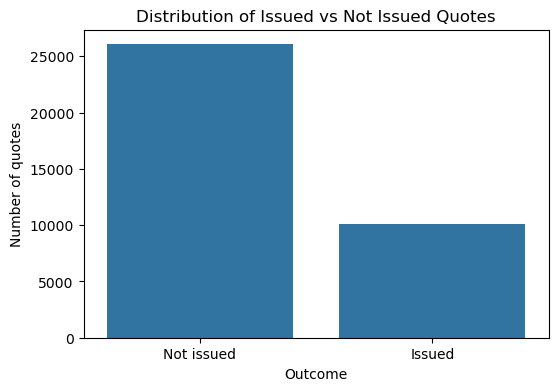

In [1256]:
# Convert issued from True/False to 1/0
eda_df["issued"] = eda_df["issued"].astype(int)

# Optional readable labels for plots
eda_df["issued_label"] = eda_df["issued"].map({
    0: "Not issued",
    1: "Issued"
})

# Quick checks
print(eda_df["issued"].value_counts().sort_index())
print(f"Conversion rate: {eda_df['issued'].mean() * 100:.2f}%")

# Bar chart
plt.figure(figsize=(6, 4))
sns.countplot(data=eda_df, x="issued_label", order=["Not issued", "Issued"])
plt.title("Distribution of Issued vs Not Issued Quotes")
plt.xlabel("Outcome")
plt.ylabel("Number of quotes")
plt.show()

The outcome variable shows a clear class imbalance. Of the 36,173 insurance quotes in the dataset, 10,114 resulted in a purchased policy, corresponding to a conversion rate of 27.96%, while 26,059 did not convert. This indicates that non-issued quotes form the majority class, which should be taken into account in later predictive modelling and evaluation.

In [1257]:
monthly_outcome = (
    eda_df.groupby(eda_df["policy_quoted_at"].dt.to_period("M"))["issued"]
    .agg(["count", "mean"])
    .reset_index()
)

monthly_outcome["policy_quoted_at"] = monthly_outcome["policy_quoted_at"].astype(str)
monthly_outcome["conversion_rate_pct"] = monthly_outcome["mean"] * 100

monthly_outcome

,policy_quoted_at,count,mean,conversion_rate_pct
0,2020-01,6501,0.248423,24.842332
1,2020-02,6164,0.279689,27.968851
2,2020-03,6261,0.266092,26.609168
3,2020-04,6373,0.292798,29.279774
4,2020-05,6897,0.290561,29.056111
5,2020-06,3977,0.311541,31.154136


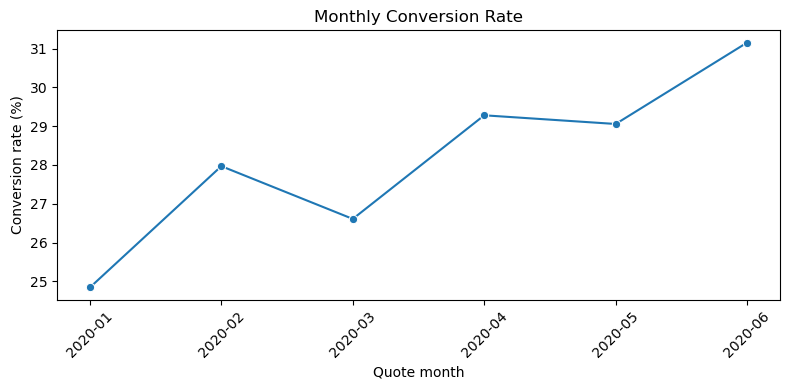

In [1258]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=monthly_outcome, x="policy_quoted_at", y="conversion_rate_pct", marker="o")
plt.title("Monthly Conversion Rate")
plt.xlabel("Quote month")
plt.ylabel("Conversion rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The monthly conversion rate shows a mild upward trend over the observed period. Conversion starts at about 24.8% in January, rises overall through the first half of 2020 and reaches its highest level in June at about 31.2%. There is some month-to-month fluctuation, especially in March but the general pattern suggests that quote conversion improved over time.

This increase in June should be interpreted with some caution, since the number of quotes in June is lower than in earlier months, which may make the final monthly rate slightly less stable.

## 4.2 Traditional Customer and Quote Profile

This section compares issued and non-issued quotes using traditional customer, vehicle and quote characteristics. The aim is to assess whether conversion is already associated with standard profile variables before moving to behavioural and ecosystem-based features in the following sections.

### 4.2.1 Customer Profile

**Numeric Summary for Age**

In [1259]:
customer_numeric_summary = (
    eda_df.groupby("issued_label")["age_at_quote"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

customer_numeric_summary

,count,mean,median,std,min,max
issued_label,,,,,,
Issued,6359,47.97,47.0,12.71,19.0,91.0
Not issued,16169,45.78,45.0,12.48,19.0,90.0


**Age Boxplot**

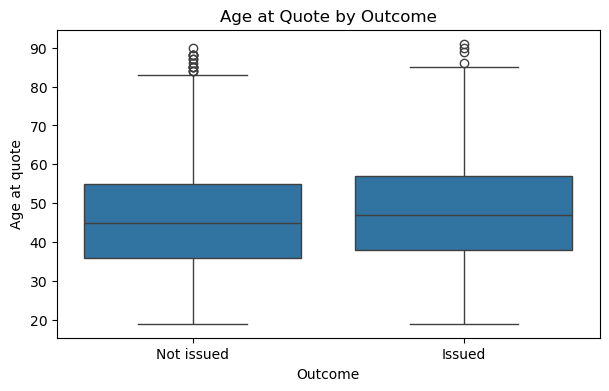

In [1260]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=eda_df, x="issued_label", y="age_at_quote")
plt.title("Age at Quote by Outcome")
plt.xlabel("Outcome")
plt.ylabel("Age at quote")
plt.show()

**Gender Distribution by Outcome**

In [1261]:
gender_dist = pd.crosstab(eda_df["gender"], eda_df["issued_label"], normalize="columns") * 100
gender_dist.round(2)

issued_label,Issued,Not issued
gender,,
F,11.65,9.50
M,51.39,52.73
Unknown,36.96,37.77


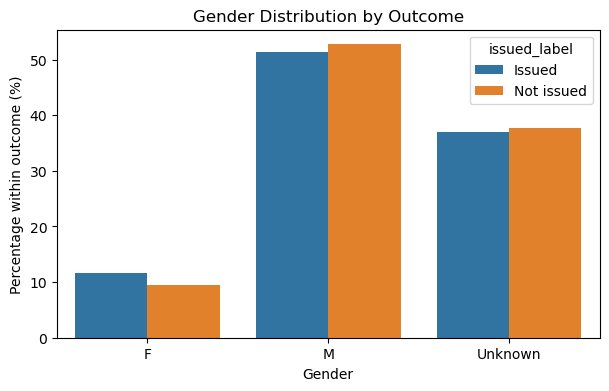

In [1262]:
gender_plot = (
    pd.crosstab(eda_df["gender"], eda_df["issued_label"], normalize="columns") * 100
).reset_index().melt(id_vars="gender", var_name="issued_label", value_name="pct")

plt.figure(figsize=(7, 4))
sns.barplot(data=gender_plot, x="gender", y="pct", hue="issued_label")
plt.title("Gender Distribution by Outcome")
plt.xlabel("Gender")
plt.ylabel("Percentage within outcome (%)")
plt.show()

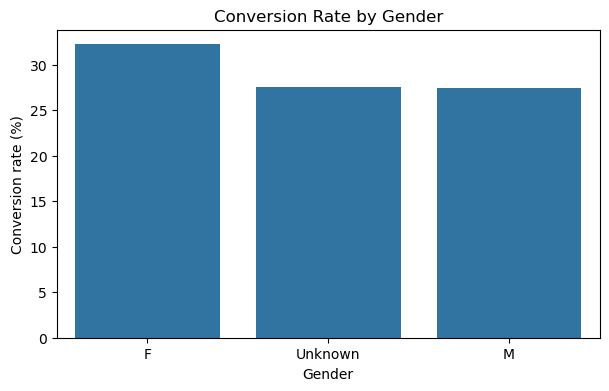

In [1263]:
gender_rate = (
    eda_df.groupby("gender")["issued"]
    .mean()
    .mul(100)
    .reset_index(name="conversion_rate_pct")
    .sort_values("conversion_rate_pct", ascending=False)
)

plt.figure(figsize=(7, 4))
sns.barplot(data=gender_rate, x="gender", y="conversion_rate_pct")
plt.title("Conversion Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Conversion rate (%)")
plt.show()

**Base Type by Outcome**

In [1264]:
base_type_dist = pd.crosstab(eda_df["base_type"], eda_df["issued_label"], normalize="columns") * 100
base_type_dist.round(2)

issued_label,Issued,Not issued
base_type,,
FA,97.35,97.75
OR,2.65,2.25


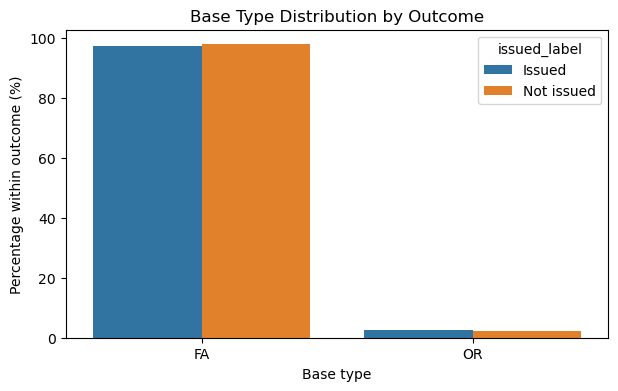

In [1265]:
base_type_plot = (
    pd.crosstab(eda_df["base_type"], eda_df["issued_label"], normalize="columns") * 100
).reset_index().melt(id_vars="base_type", var_name="issued_label", value_name="pct")

plt.figure(figsize=(7, 4))
sns.barplot(data=base_type_plot, x="base_type", y="pct", hue="issued_label")
plt.title("Base Type Distribution by Outcome")
plt.xlabel("Base type")
plt.ylabel("Percentage within outcome (%)")
plt.show()

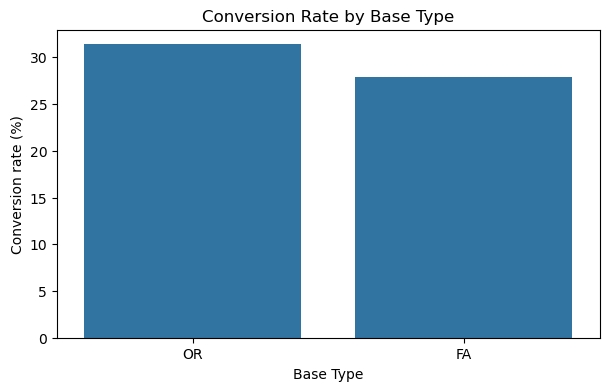

In [1266]:
base_type_rate = (
    eda_df.groupby("base_type")["issued"]
    .mean()
    .mul(100)
    .reset_index(name="conversion_rate_pct")
    .sort_values("conversion_rate_pct", ascending=False)
)

plt.figure(figsize=(7, 4))
sns.barplot(data=base_type_rate, x="base_type", y="conversion_rate_pct")
plt.title("Conversion Rate by Base Type")
plt.xlabel("Base Type")
plt.ylabel("Conversion rate (%)")
plt.show()

**Driving Type by Outcome**

In [1267]:
driving_type_dist = pd.crosstab(eda_df["driving_type"], eda_df["issued_label"], normalize="columns") * 100
driving_type_dist.round(2)

issued_label,Issued,Not issued
driving_type,,
between_23_and_25,4.61,5.08
less_than_23,3.67,4.07
more_than_26,91.72,90.85


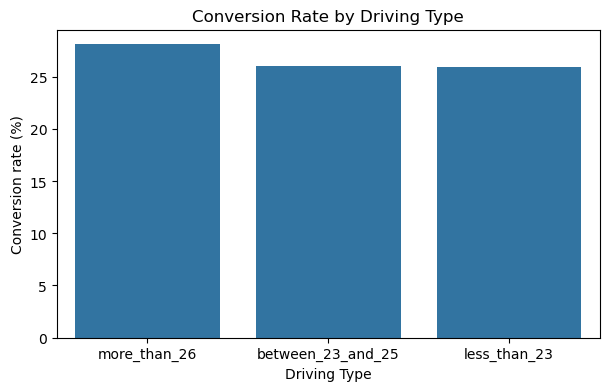

In [1268]:
driving_type_rate = (
    eda_df.groupby("driving_type")["issued"]
    .mean()
    .mul(100)
    .reset_index(name="conversion_rate_pct")
    .sort_values("conversion_rate_pct", ascending=False)
)

plt.figure(figsize=(7, 4))
sns.barplot(data=driving_type_rate, x="driving_type", y="conversion_rate_pct")
plt.title("Conversion Rate by Driving Type")
plt.xlabel("Driving Type")
plt.ylabel("Conversion rate (%)")
plt.show()

**County Top 10**

In [1269]:
top_counties = eda_df["county"].value_counts().head(10).index
county_subset = eda_df[eda_df["county"].isin(top_counties)]

county_plot = (
    pd.crosstab(county_subset["county"], county_subset["issued_label"], normalize="index") * 100
).reset_index()

county_plot

issued_label,county,Issued,Not issued
0,BG,31.737194,68.262806
1,BO,28.032980,71.967020
2,FI,27.033493,72.966507
3,MB,34.102307,65.897693
4,MI,34.082999,65.917001
5,RM,32.324702,67.675298
6,SA,14.550265,85.449735
7,TO,29.529847,70.470153
8,Unknown,16.731518,83.268482
9,VA,35.108959,64.891041


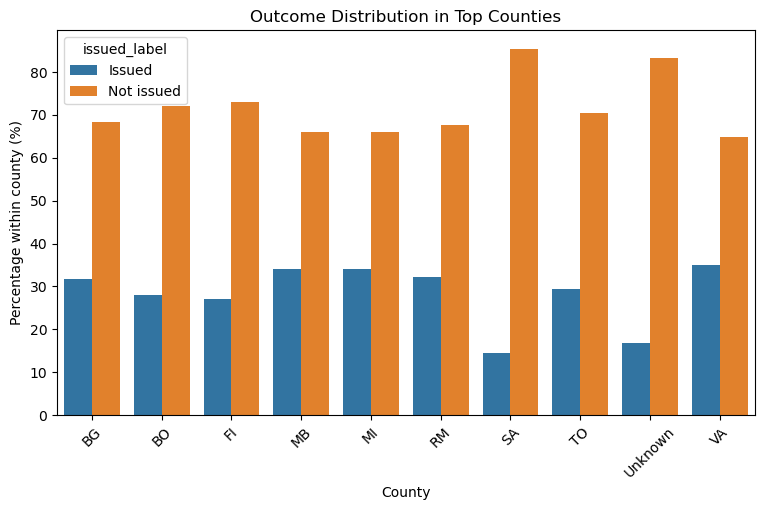

In [1270]:
county_plot_long = county_plot.melt(id_vars="county", var_name="issued_label", value_name="pct")

plt.figure(figsize=(9, 5))
sns.barplot(data=county_plot_long, x="county", y="pct", hue="issued_label")
plt.title("Outcome Distribution in Top Counties")
plt.xlabel("County")
plt.ylabel("Percentage within county (%)")
plt.xticks(rotation=45)
plt.show()

The customer profile analysis suggests that issued quotes are associated with slightly older customers. The mean age among issued quotes is about 48 years, compared with around 46 years for non-issued quotes, while the overall age distributions remain fairly similar. Gender composition also shows only modest differences: issued quotes contain a slightly higher share of female customers and a slightly lower share of missing or unknown gender values. Base type appears almost identical across the two groups, indicating that this variable does not meaningfully distinguish conversion in this sample. Driving type shows a similarly small pattern, with issued quotes being marginally more concentrated among older driver segments. County-level differences appear more noticeable, as some provinces such as VA, MI and MB show relatively higher issuance rates, while SA and unknown county records show much lower conversion. It can be said that the traditional customer characteristics seem to have some relationship with conversion but the effects are generally moderate rather than decisive.

### 4.2.2 Vehicle Profile

**Vehicle Age Boxplot**

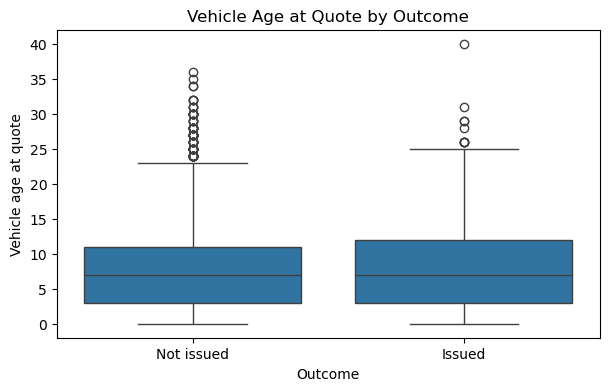

In [1271]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=eda_df, x="issued_label", y="vehicle_age_at_quote")
plt.title("Vehicle Age at Quote by Outcome")
plt.xlabel("Outcome")
plt.ylabel("Vehicle age at quote")
plt.show()

**Top Car Brands Only**

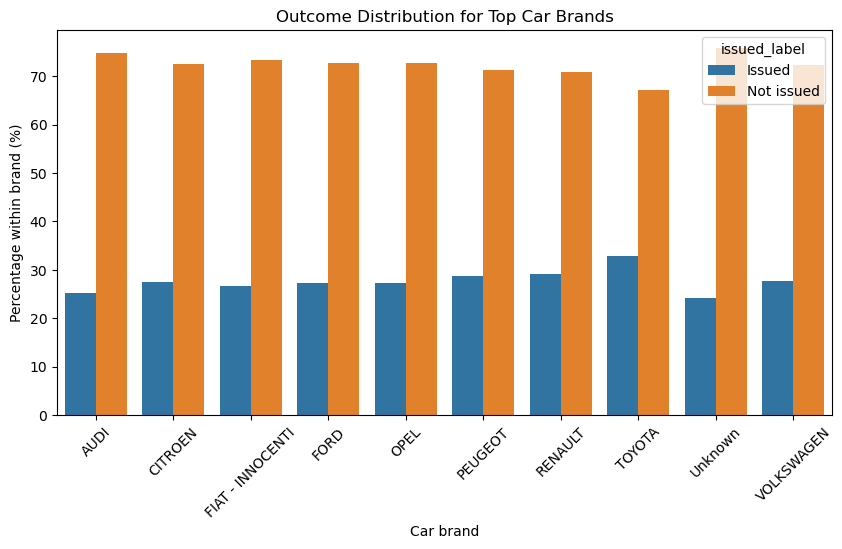

In [1272]:
top_brands = eda_df["car_brand"].value_counts().head(10).index
brand_subset = eda_df[eda_df["car_brand"].isin(top_brands)]

brand_plot = (
    pd.crosstab(brand_subset["car_brand"], brand_subset["issued_label"], normalize="index") * 100
).reset_index()

brand_plot_long = brand_plot.melt(id_vars="car_brand", var_name="issued_label", value_name="pct")

plt.figure(figsize=(10, 5))
sns.barplot(data=brand_plot_long, x="car_brand", y="pct", hue="issued_label")
plt.title("Outcome Distribution for Top Car Brands")
plt.xlabel("Car brand")
plt.ylabel("Percentage within brand (%)")
plt.xticks(rotation=45)
plt.show()

The customer profile evidence suggests that traditional customer characteristics are associated with insurance conversion but the effects are generally modest rather than decisive. Issued quotes are linked to slightly older customers: the mean age at quote is about 48 years for issued quotes, compared with about 46 years for non-issued quotes and the two age distributions remain broadly similar in general. Gender differences are also limited. Female customers show the highest conversion rate at roughly 32%, while male and unknown-gender customers are both closer to 28%. This shows that only moderate separation is appread by gender.

Base type shows a somewhat clearer pattern. OR customers have a conversion rate of around 31%, compared with about 28% for FA customers, although OR represents a relatively small share of the sample and should therefore be interpreted with some caution. Driving type follows a similarly mild gradient: customers in the more_than_26 category convert slightly more often than those in the younger driving groups, which is consistent with the age results but not large enough to suggest a strong standalone effect.

Geographic variation is more noticeable. Among the top counties, conversion rates are highest in provinces such as VA, MB, MI and RM, while SA and unknown county records show materially lower conversion. This suggests that location may capture meaningful differences in customer mix, broker effectiveness or local offer conditions. The descriptive results show that traditional customer profile variables do carry information about conversion but mainly in a moderate and supportive way rather than as dominant predictors.

### 4.2.3 Quote Profile

**Price Summary**

In [1273]:
quote_numeric_summary = (
    eda_df.groupby("issued_label")[["price_sale", "discount_percent"]]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

quote_numeric_summary

price_sale                         discount_percent               \
                  count    mean  median     std            count  mean median   
issued_label                                                                    
Issued            10114  399.47  304.60  293.91            10114  0.05   0.04   
Not issued        26059  467.34  345.64  342.38            26059  0.06   0.05   

                    
               std  
issued_label        
Issued        0.05  
Not issued    0.06

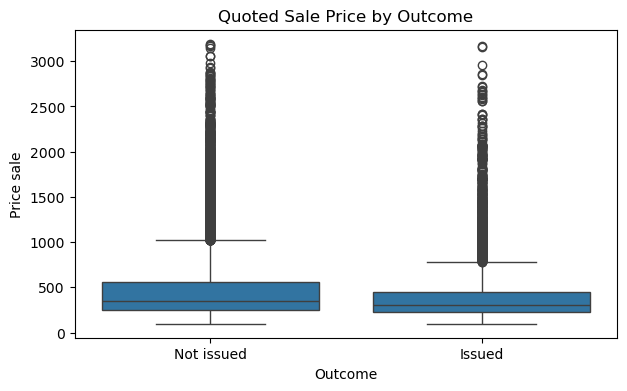

In [1274]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=eda_df, x="issued_label", y="price_sale")
plt.title("Quoted Sale Price by Outcome")
plt.xlabel("Outcome")
plt.ylabel("Price sale")
plt.show()

**Discount Boxplot**

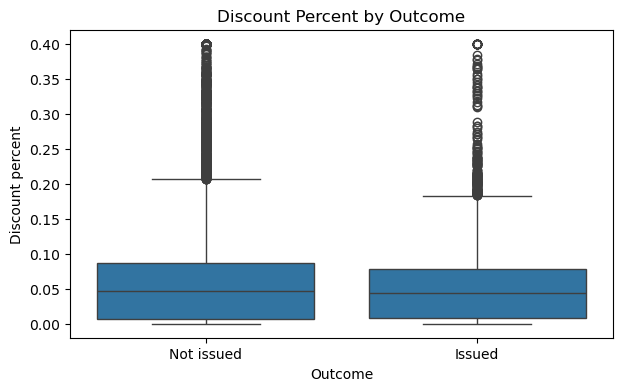

In [1275]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=eda_df, x="issued_label", y="discount_percent")
plt.title("Discount Percent by Outcome")
plt.xlabel("Outcome")
plt.ylabel("Discount percent")
plt.show()

The vehicle profile results show only modest differences between issued and non-issued quotes. Vehicle age is slightly higher for issued quotes, suggesting that customers insuring somewhat older vehicles may be marginally more likely to convert, although the two distributions overlap substantially. The comparison across the most common car brands also does not reveal large contrasts: most brands display fairly similar issuance rates, with only limited variation across manufacturers. Toyota appears to have a somewhat higher conversion share than several other brands, while the unknown brand category performs less strongly. Overall, vehicle related characteristics provide some descriptive context but on their own they do not appear to create a sharp separation between issued and non-issued quotes.

Taken together, the traditional customer and quote profile variables show some association with conversion, especially through quoted price but most differences remain moderate. This motivates the next sections, where ecosystem engagement and prior behavioural activity are examined as potentially stronger explanations of quote issuance.

## 4.3 Ecosystem Engagement and Prior Activity

This section examines whether prior engagement within the Telepass ecosystem is associated with insurance quote conversion. Unlike the traditional profile variables in the previous section, these features reflect actual behavioural history before the quote date, including prior transaction presence, activity frequency, transaction volume, spending intensity and diversity of service usage. The purpose is to assess whether customers who are more embedded in the platform appear more likely to convert.

### 4.3.1 Prior Transaction History Availability

I started by separating customers with and without observed transaction history before the quote month. This provides the simplest behavioural distinction in the dataset. If customers with prior activity show a higher conversion rate, this would offer initial descriptive support for the idea that ecosystem engagement is positively associated with insurance uptake.

In [1276]:
# Safety check: create readable labels if they do not already exist
if "issued_label" not in eda_df.columns:
    eda_df["issued_label"] = eda_df["issued"].map({
        0: "Not issued", 1: "Issued",
        False: "Not issued", True: "Issued"
    })

eda_df["tx_history_label"] = eda_df["tx_history_available"].map({
    0: "No prior history", 1: "Prior history",
    False: "No prior history", True: "Prior history"
})

# Count table
tx_history_counts = pd.crosstab(eda_df["tx_history_label"], eda_df["issued_label"])
tx_history_counts

issued_label,Issued,Not issued
tx_history_label,,
No prior history,6927,18327
Prior history,3187,7732


In [1277]:
# Conversion rate within history groups
tx_history_conversion = (
    pd.crosstab(
        eda_df["tx_history_label"],
        eda_df["issued_label"],
        normalize="index"
    ) * 100
).round(2)

tx_history_conversion

issued_label,Issued,Not issued
tx_history_label,,
No prior history,27.43,72.57
Prior history,29.19,70.81


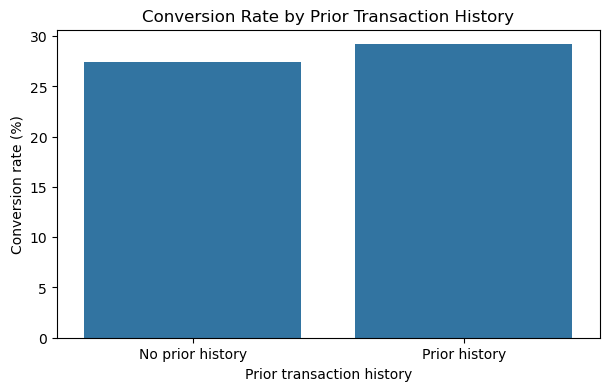

In [1278]:
# Plot issued share by prior history group
tx_history_plot = (
    eda_df.groupby("tx_history_label")["issued"]
    .mean()
    .mul(100)
    .reset_index(name="conversion_rate_pct")
)

plt.figure(figsize=(7, 4))
sns.barplot(data=tx_history_plot, x="tx_history_label", y="conversion_rate_pct")
plt.title("Conversion Rate by Prior Transaction History")
plt.xlabel("Prior transaction history")
plt.ylabel("Conversion rate (%)")
plt.show()

Customers with prior transaction history show a slightly higher insurance conversion rate than customers without such history. Among quotes for customers with no prior history, 27.43% were issued, compared with 29.19% for customers with observed prior history. This suggests that previous platform activity is positively associated with conversion, although the difference is modest rather than large. Descriptively, this provides initial support for the view that customers already engaged in the Telepass ecosystem may be somewhat more receptive to insurance offers.

### 4.3.2 Intensity of Prior Activity

Whether customers with more intensive past platform activity were more likely to purchase the quoted insurance policy was examined. For this purpose, comparison of the number of historical transaction rows, the number of active months, the total number of transactions and the total amount previously spent within the platform across issued and non-issued quotes is shown in this section. 

In [1279]:
# Restrict intensity analysis to customers with prior transaction history
hist_df = eda_df[eda_df["tx_history_available"] == 1].copy()

hist_df.shape

(10919, 87)

In [1280]:
# Summary table for intensity variables
intensity_summary = (
    hist_df.groupby("issued_label")[
        ["tx_history_rows", "tx_active_months", "tx_total_transactions", "tx_total_expenditures"]
    ]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

intensity_summary

tx_history_rows                    tx_active_months               \
                       count  mean median   std            count  mean median   
issued_label                                                                    
Issued                  3187  3.22    2.0  3.35             3187  2.85    2.0   
Not issued              7732  3.16    2.0  3.28             7732  2.80    2.0   

                   tx_total_transactions                       \
               std                 count   mean median    std   
issued_label                                                    
Issued        2.50                  3187  11.22    5.0  17.92   
Not issued    2.45                  7732   6.66    2.0  13.11   

             tx_total_expenditures                         
                             count    mean median     std  
issued_label                                               
Issued                        3187  179.99  21.09  434.82  
Not issued                    7732   95.66  10.60  265.60

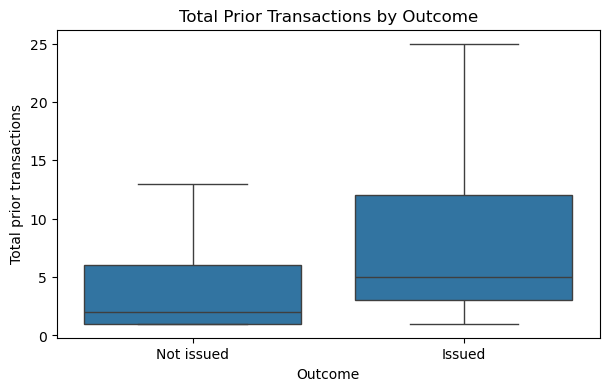

In [1281]:
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=hist_df,
    x="issued_label",
    y="tx_total_transactions",
    showfliers=False
)
plt.title("Total Prior Transactions by Outcome")
plt.xlabel("Outcome")
plt.ylabel("Total prior transactions")
plt.show()

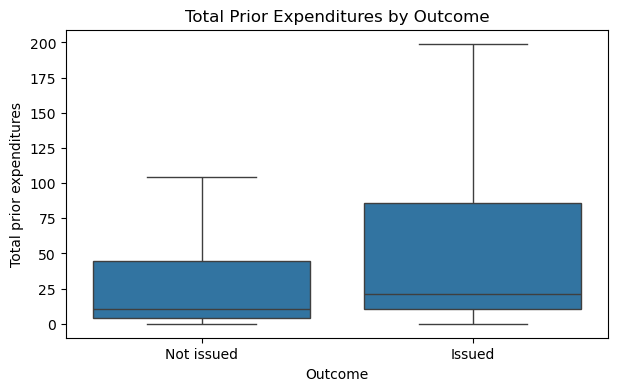

In [1282]:
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=hist_df,
    x="issued_label",
    y="tx_total_expenditures",
    showfliers=False
)
plt.title("Total Prior Expenditures by Outcome")
plt.xlabel("Outcome")
plt.ylabel("Total prior expenditures")
plt.show()

In [1283]:
# Optional extra variable: average spend per transaction
avg_spend_summary = (
    hist_df.groupby("issued_label")["tx_avg_spend_per_transaction"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

avg_spend_summary

,count,mean,median,std,min,max
issued_label,,,,,,
Issued,3187,19.26,4.79,50.63,0.12,624.55
Not issued,7732,14.19,4.13,32.45,0.00,436.70


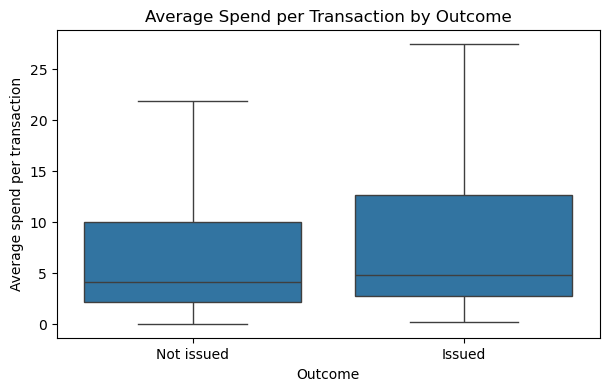

In [1284]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=hist_df, x="issued_label", y="tx_avg_spend_per_transaction", showfliers=False)
plt.title("Average Spend per Transaction by Outcome")
plt.xlabel("Outcome")
plt.ylabel("Average spend per transaction")
plt.show()

Conditional on having prior transaction history, issued quotes are associated with somewhat stronger behavioural engagement. The number of prior transaction rows and active months is very similar across issued and non-issued groups, with both groups showing a median of two historical rows and two active months. However, larger differences emerge for transaction volume and spending. Customers in the issued group have a higher mean number of prior transactions (11.22 versus 6.66) and substantially higher mean prior expenditures (179.99 versus 95.66). Average spend per transaction is also somewhat higher among issued quotes. Taken together, these patterns suggest that deeper economic engagement with the platform is more strongly associated with conversion than simple activity presence alone.

### 4.3.3 Breadth and Recency of Prior Engagement

Behavioural engagement is not only about transaction volume but also about how broadly and how recently customers used the platform. Service diversity captures the number of distinct service categories used before the quote, while recency measures how long it had been since the customer’s last observed transaction. If issued quotes are associated with greater service diversity and more recent activity, this would further support the view that embedded platform users are more receptive to insurance offers.

In [1285]:
# Summary table for diversity and recency
breadth_recency_summary = (
    hist_df.groupby("issued_label")[
        ["tx_service_diversity", "months_since_last_transaction"]
    ]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

breadth_recency_summary

tx_service_diversity                               \
                            count  mean median   std  min  max   
issued_label                                                     
Issued                       3187  1.30    1.0  0.68  1.0  8.0   
Not issued                   7732  1.27    1.0  0.64  1.0  9.0   

             months_since_last_transaction                                
                                     count  mean median   std  min   max  
issued_label                                                              
Issued                                3187  3.83    3.0  2.86  1.0  12.0  
Not issued                            7732  3.73    3.0  2.80  1.0  12.0

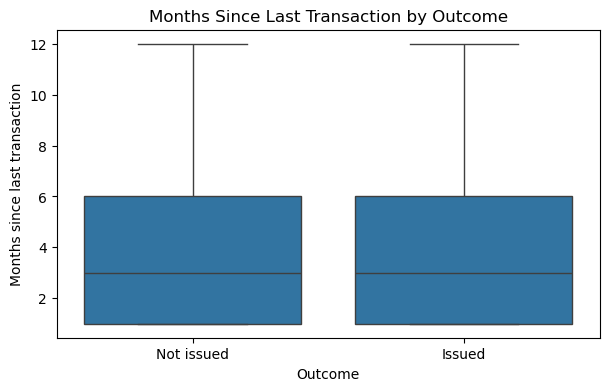

In [1286]:
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=hist_df,
    x="issued_label",
    y="months_since_last_transaction",
    showfliers=False
)
plt.title("Months Since Last Transaction by Outcome")
plt.xlabel("Outcome")
plt.ylabel("Months since last transaction")
plt.show()

The descriptive evidence for breadth and recency is weaker. Service diversity differs only slightly between the two groups, with both issued and non-issued quotes showing a median of one service category used before the quote. Recency also appears very similar, with the median time since the last transaction equal to three months in both groups. Although the issued group shows marginally higher mean service diversity and slightly longer mean recency, these differences are small and do not suggest strong behavioural separation. Therefore, at the EDA stage, breadth and recency appear less informative than transaction volume and expenditure intensity.

It can be concluded that prior ecosystem engagement is related to insurance conversion but not all engagement measures contribute equally. The existence of prior transaction history is associated with a slightly higher conversion rate, while stronger differences appear in total transaction volume, total expenditures and average spending intensity. On the other hand, service diversity and recency show only weak descriptive differences between issued and non-issued quotes. This indicates that behavioural variables may add useful information beyond traditional customer and quote characteristics but the most promising behavioural signals appear to come from transaction intensity rather than breadth or recency.

## 4.4 TelepassPay Adoption and Service Usage

This section examines whether prior use of TelepassPay is associated with insurance conversion. Since TelepassPay related behavioural variables are only meaningful for customers with prior transaction history, the analysis is restricted to quotes for which historical platform activity is observed. We first compare the share of prior transactions conducted through TelepassPay across issued and non-issued quotes and then examine whether customers with any observed TelepassPay usage differ in conversion from those with none.

### 4.4.1 TelepassPay Usage Among Customers With Prior History

Among customers with prior transaction history, issued quotes show a slightly higher average TelepassPay share than non-issued quotes. The mean share of prior transactions conducted through TelepassPay is 0.351 for issued quotes compared with 0.319 for non issued quotes. However, the median is 0.0 in both groups and this indicates that a large proportion of customers had no observed TelepassPay usage at all. This suggests that TelepassPay intensity is related to conversion in the expected direction but the separation is modest and the distribution is highly concentrated at the lower bound.

In [1287]:
# Restrict to customers with prior transaction history
pay_hist_df = eda_df[eda_df["tx_history_available"] == 1].copy()

# Summary table for TelepassPay share
telepass_pay_summary = (
    pay_hist_df.groupby("issued_label")["tx_telepass_pay_share"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(3)
)

telepass_pay_summary

,count,mean,median,std,min,max
issued_label,,,,,,
Issued,3187,0.351,0.0,0.456,0.0,1.0
Not issued,7732,0.319,0.0,0.447,0.0,1.0


### 4.4.2 TelepassPay Adopter vs Non Adopter

A clearer pattern emerges when customers are divided into TelepassPay adopters and non adopters. Among customers with prior history, those with any observed TelepassPay usage have a conversion rate of 31.11%, compared with 28.08% among those with no TelepassPay usage. This provides descriptive support for the hypothesis that TelepassPay adoption is associated with stronger insurance uptake. It suggests that customers who already use TelepassPay may be more embedded in the Telepass ecosystem and therefore more responsive to brokerage offers.

In [1288]:
# Indicator: any prior TelepassPay usage
pay_hist_df["telepass_pay_user"] = (
    pay_hist_df["tx_telepass_pay_share"] > 0
).map({
    False: "No TelepassPay usage",
    True: "Has TelepassPay usage"
})

In [1289]:
telepass_user_counts = pd.crosstab(
    pay_hist_df["telepass_pay_user"],
    pay_hist_df["issued_label"]
)

telepass_user_counts

issued_label,Issued,Not issued
telepass_pay_user,,
Has TelepassPay usage,1242,2750
No TelepassPay usage,1945,4982


In [1290]:
telepass_user_conversion = (
    pd.crosstab(
        pay_hist_df["telepass_pay_user"],
        pay_hist_df["issued_label"],
        normalize="index"
    ) * 100
).round(2)

telepass_user_conversion

issued_label,Issued,Not issued
telepass_pay_user,,
Has TelepassPay usage,31.11,68.89
No TelepassPay usage,28.08,71.92


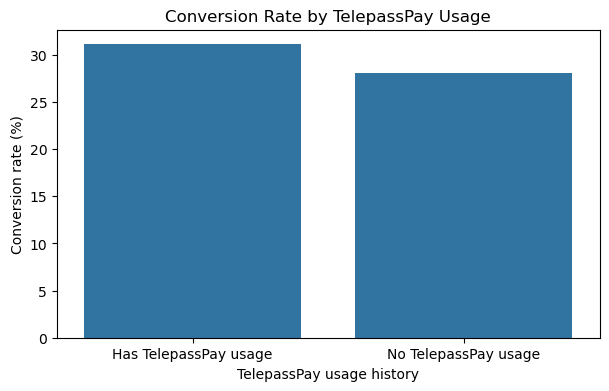

In [1291]:
telepass_user_plot = (
    pay_hist_df.groupby("telepass_pay_user")["issued"]
    .mean()
    .mul(100)
    .reset_index(name="conversion_rate_pct")
)

plt.figure(figsize=(7, 4))
sns.barplot(
    data=telepass_user_plot,
    x="telepass_pay_user",
    y="conversion_rate_pct"
)
plt.title("Conversion Rate by TelepassPay Usage")
plt.xlabel("TelepassPay usage history")
plt.ylabel("Conversion rate (%)")
plt.show()

In [ ]:
pay_hist_df["telepass_pay_share_group"] = pd.cut(
    pay_hist_df["tx_telepass_pay_share"],
    bins=[-0.001, 0, 0.25, 0.50, 0.75, 1.00],
    labels=[
        "0%",
        "0–25%",
        "25–50%",
        "50–75%",
        "75–100%"
    ]
)

telepass_group_conversion = (
    pay_hist_df.groupby("telepass_pay_share_group")["issued"]
    .mean()
    .mul(100)
    .reset_index(name="conversion_rate_pct")
)

telepass_group_conversion

,telepass_pay_share_group,conversion_rate_pct
0,0%,28.078533
1,0–25%,38.095238
2,25–50%,20.996441
3,50–75%,37.755102
4,75–100%,31.159420


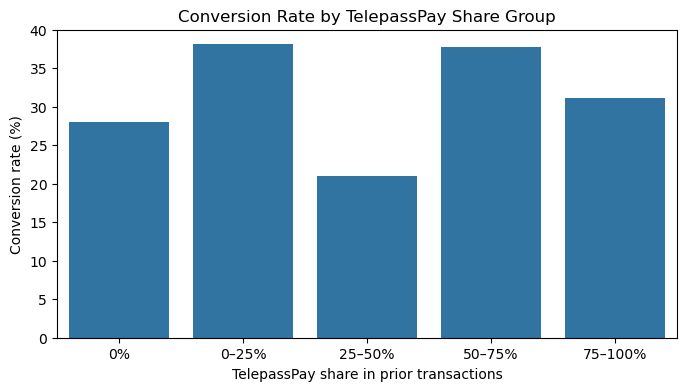

In [1293]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=telepass_group_conversion,
    x="telepass_pay_share_group",
    y="conversion_rate_pct"
)
plt.title("Conversion Rate by TelepassPay Share Group")
plt.xlabel("TelepassPay share in prior transactions")
plt.ylabel("Conversion rate (%)")
plt.show()

When TelepassPay share is grouped into intervals, conversion rates do not increase monotonically with the share of TelepassPay transactions. Some positive usage groups perform better than the zero usage group but the relationship is not strictly linear. This implies that the presence of TelepassPay usage may be more informative than its exact intensity at the descriptive stage.

It can be said that TelepassPay usage is positively associated with insurance conversion, although the relationship is moderate rather than strong. The most interpretable result is the higher conversion rate among customers with any prior TelepassPay usage. This supports the view that TelepassPay adoption signals deeper platform engagement and may contribute useful predictive value beyond traditional quote characteristics.

## 4.5 Quote Composition and Optional Coverages

This section examines whether the composition of the insurance quote is associated with conversion. I compare the main pricing variables, including quoted sale price and discount rate, across issued and non-issued quotes. Then the optional coverage indicators to assess whether richer or more customized quotes are linked to a higher likelihood of purchase. was analysed.

### 4.5.1 Core Quote Composition

In [1294]:
quote_price_summary = (
    eda_df.groupby("issued_label")[["price_sale", "discount_percent", "discount_amount"]]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

quote_price_summary

price_sale                         discount_percent               \
                  count    mean  median     std            count  mean median   
issued_label                                                                    
Issued            10114  399.47  304.60  293.91            10114  0.05   0.04   
Not issued        26059  467.34  345.64  342.38            26059  0.06   0.05   

                   discount_amount                       
               std           count   mean median    std  
issued_label                                             
Issued        0.05           10114  23.17  14.59  37.30  
Not issued    0.06           26059  33.19  16.49  60.57

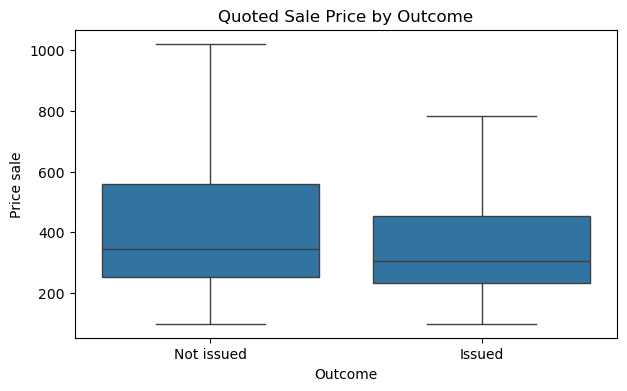

In [1295]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=eda_df, x="issued_label", y="price_sale", showfliers=False)
plt.title("Quoted Sale Price by Outcome")
plt.xlabel("Outcome")
plt.ylabel("Price sale")
plt.show()

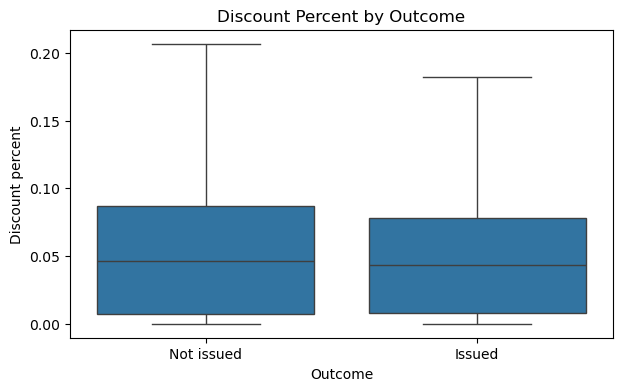

In [1296]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=eda_df, x="issued_label", y="discount_percent", showfliers=False)
plt.title("Discount Percent by Outcome")
plt.xlabel("Outcome")
plt.ylabel("Discount percent")
plt.show()

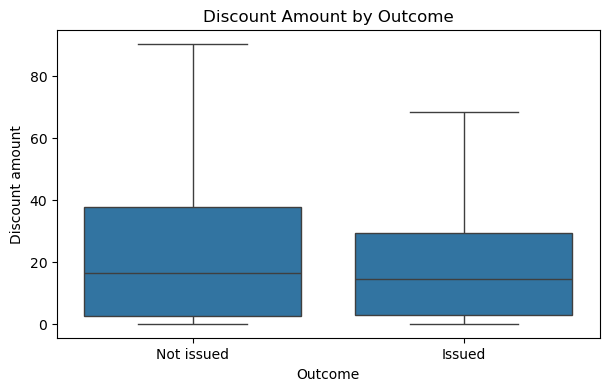

In [1297]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=eda_df, x="issued_label", y="discount_amount", showfliers=False)
plt.title("Discount Amount by Outcome")
plt.xlabel("Outcome")
plt.ylabel("Discount amount")
plt.show()

The core quote pricing variables show a clearer relationship with conversion than most other quote composition features. Issued quotes have a lower quoted sale price on average and at the median than non-issued quotes, which suggests that affordability is more closely linked to conversion. However, issued quotes do not show higher average discount percentages or discount amounts. If anything, the discount measures are slightly lower among issued quotes. Taken together, this suggests that conversion is more clearly associated with the final quoted price level than with discount size alone.

### 4.5.2 Optional Coverages and Add-ons

In [1298]:
coverage_cols = [
    "license_revoked_included",
    "key_loss_included",
    "uninsured_vehicles_included",
    "vandalism_included",
    "kasko_included",
    "natural_events_included",
    "protected_bonus_included",
    "waive_right_compensation_included",
    "collision_included",
    "windows_included",
    "theft_fire_included",
    "legal_protection_included",
    "driver_injury_included"
]

In [1299]:
coverage_by_outcome = (
    eda_df.groupby("issued_label")[coverage_cols]
    .mean()
    .mul(100)
    .T
    .round(2)
    .sort_values("Issued", ascending=False)
)

coverage_by_outcome

issued_label,Issued,Not issued
driver_injury_included,96.98,98.32
legal_protection_included,96.80,98.32
theft_fire_included,72.51,69.16
windows_included,67.90,64.75
collision_included,62.56,59.19
protected_bonus_included,58.23,56.30
waive_right_compensation_included,57.23,57.93
natural_events_included,22.43,24.16
kasko_included,19.79,19.56
vandalism_included,12.45,13.85


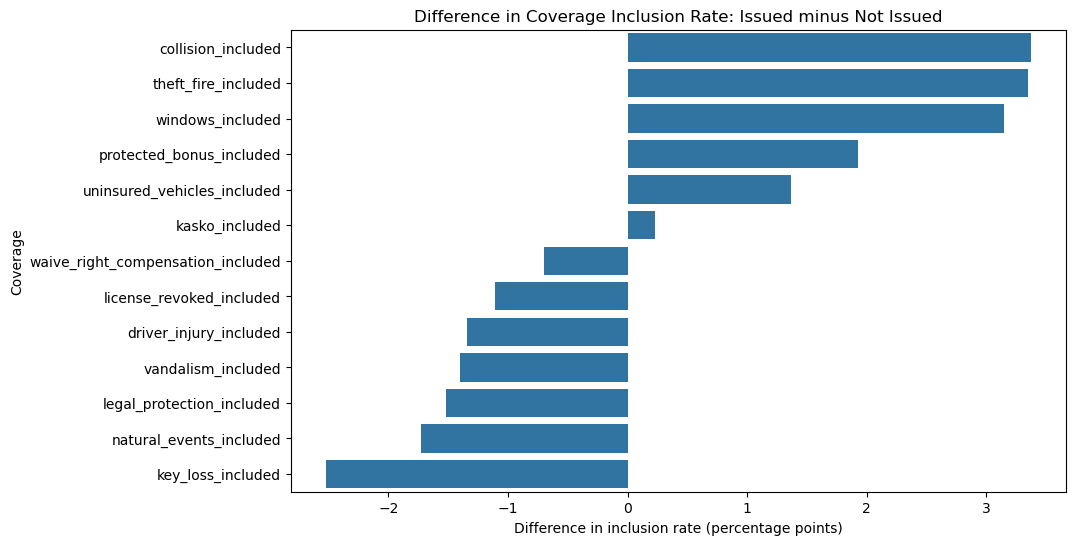

In [1300]:
coverage_plot = coverage_by_outcome.reset_index().rename(columns={"index": "coverage"})
coverage_plot["difference"] = coverage_plot["Issued"] - coverage_plot["Not issued"]
coverage_plot = coverage_plot.sort_values("difference", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=coverage_plot, x="difference", y="coverage")
plt.title("Difference in Coverage Inclusion Rate: Issued minus Not Issued")
plt.xlabel("Difference in inclusion rate (percentage points)")
plt.ylabel("Coverage")
plt.show()

In [1301]:
eda_df["optional_coverage_count"] = eda_df[coverage_cols].sum(axis=1)

coverage_count_summary = (
    eda_df.groupby("issued_label")["optional_coverage_count"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

coverage_count_summary

,count,mean,median,std,min,max
issued_label,,,,,,
Issued,10114,5.90,7.0,2.21,0,10
Not issued,26059,5.87,7.0,2.17,0,10


The optional coverage indicators show only modest differences between issued and non-issued quotes. Some coverages, such as collision, theft and fire, windows and protected bonus, appear slightly more often in issued quotes, while others, including key loss, natural events and legal protection, are somewhat more common among non-issued quotes. However, these differences are small in magnitude. This is reinforced by the summary of the total number of optional coverages, which is almost identical across the two groups. Therefore, the EDA suggests that quote composition may contain some descriptive information but it does not appear to be a strong standalone driver of conversion compared with broader pricing or behavioural variables.

### 4.5.3 Broker Differences

In [1302]:
broker_summary = (
    eda_df.groupby("broker_id")["issued"]
    .agg(["count", "mean"])
    .reset_index()
)

broker_summary["conversion_rate_pct"] = broker_summary["mean"] * 100
broker_summary = broker_summary.sort_values(
    ["conversion_rate_pct", "count"], ascending=[False, False]
).round(2)

broker_summary

,broker_id,count,mean,conversion_rate_pct
1,2,9968,0.32,32.10
3,4,4038,0.29,28.70
0,1,17559,0.27,27.42
2,3,2839,0.25,25.11
4,5,1769,0.13,12.83


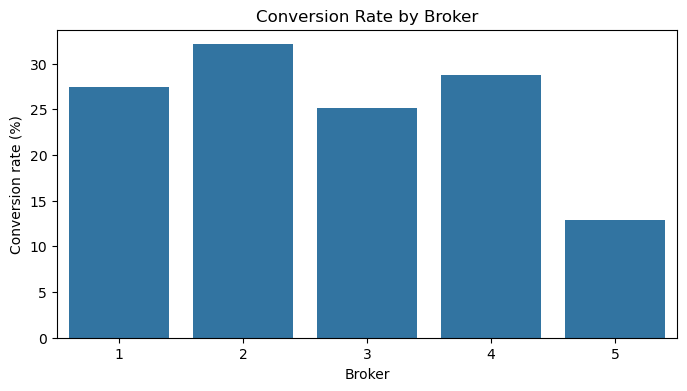

In [1303]:
broker_plot = broker_summary[broker_summary["count"] >= 300].copy()

plt.figure(figsize=(8, 4))
sns.barplot(data=broker_plot, x="broker_id", y="conversion_rate_pct")
plt.title("Conversion Rate by Broker")
plt.xlabel("Broker")
plt.ylabel("Conversion rate (%)")
plt.show()

Broker-level differences are one of the clearest patterns in the quote-side analysis. Conversion rates vary materially across brokers, from about 13% for broker 5 to about 32% for broker 2, with brokers 1, 3 and 4 falling in between. These are not trivial differences and they persist even though each broker handles a substantial number of quotes, which makes it less likely that the pattern is driven purely by very small sample sizes.

This result suggests that broker assignment may matter for conversion, potentially reflecting differences in pricing strategy, customer targeting, quote quality, sales approach or the match between broker and customer segment. At the EDA stage, this should not be interpreted as causal evidence that one broker is inherently better, since brokers may receive systematically different kinds of customers or offers. However, it does indicate that broker identity contains meaningful descriptive information and deserves attention both in the business interpretation and in the later predictive modeling stage.

Overall, the descriptive evidence suggests that quote composition matters mainly through the affordability and structure of the offer rather than through substantially richer optional coverage bundles. Issued quotes tend to be cheaper, while discount measures and the total number of add-on protections do not differ enough to indicate a strong coverage-driven conversion pattern. However, broker-level differences are much more pronounced, with some brokers consistently associated with higher conversion rates than others. At this stage, quote-side variables appear to offer useful descriptive information, with broker identity and core pricing features looking more informative than optional coverage breadth alone.

## 4.6 Missingness as Information

### 4.6.1 Overview of Remaining Missingness Indicators

This section examines whether missing values in the final analysis-ready dataset behave as informative signals rather than pure data noise. Since missingness indicators were explicitly engineered during data preparation, the goal here is not to revisit raw data cleaning but to assess whether the absence of certain information is systematically associated with quote conversion or with particular customer groups.

In [1304]:
missing_cols = [
    "age_missing",
    "vehicle_age_missing",
    "expiry_active_missing",
    "base_tenure_missing",
    "pay_tenure_missing",
    "premium_tenure_missing"
]

missing_labels = {
    "age_missing": "Age missing",
    "vehicle_age_missing": "Vehicle age missing",
    "expiry_active_missing": "Insurance expiry missing",
    "base_tenure_missing": "Base tenure missing",
    "pay_tenure_missing": "Pay tenure missing",
    "premium_tenure_missing": "Premium tenure missing"
}

missing_summary = (
    eda_df[missing_cols]
    .mean()
    .mul(100)
    .rename(index=missing_labels)
    .sort_values(ascending=False)
    .round(2)
)

missing_summary

Pay tenure missing          73.22
Premium tenure missing      42.76
Age missing                 37.72
Insurance expiry missing     8.90
Vehicle age missing          4.73
Base tenure missing          1.54
dtype: float64

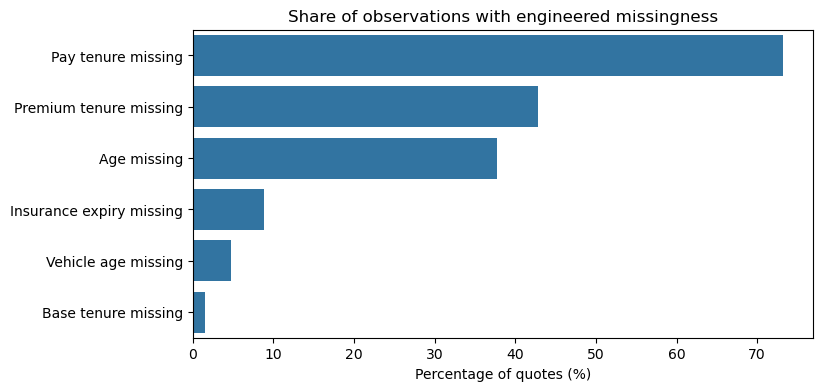

In [1305]:
plt.figure(figsize=(8, 4))
sns.barplot(
    x=missing_summary.values,
    y=missing_summary.index
)
plt.title("Share of observations with engineered missingness")
plt.xlabel("Percentage of quotes (%)")
plt.ylabel("")
plt.show()

Although missing values were already addressed during data preparation, several engineered missingness indicators remain in the final analysis dataset. These should not be interpreted as unresolved cleaning problems. Instead, they capture two different situations. First, some missingness is structural: subscription tenure variables are undefined when the corresponding service was never active, which explains the high missing shares for pay and premium tenure. Second, some missingness reflects incomplete customer or policy information, particularly for age and insurance expiry information.

This distinction is important for interpretation. The structural missingness in tenure variables is itself informative about prior service adoption, while the remaining missingness in demographic and policy related variables highlights limits in the richness of the available data. Taken together, these patterns suggest that Telepass’s platform data are more suitable for analysing brokerage conversion than for supporting full insurance underwriting. In other words, the dataset is strong for studying quote uptake behaviour but less complete for building a full risk-pricing view of the customer.

## 4.7 Explotaroy Analysis Sumary

The exploratory analysis shows that both traditional quote characteristics and behavioural platform variables are associated with insurance conversion but they do not contribute equally. Traditional customer and quote profile variables reveal some descriptive differences between issued and non-issued quotes, particularly in age and quoted sale price. However discount related measures appear less clearly differentiated across the two groups. These differences are moderate and do not by themselves create strong separation between issued and non-issued quotes.

On the other hand, behavioural variables provide more informative descriptive signals. Customers with prior transaction history show somewhat higher conversion rates than those with no observed history and stronger differences appear in measures of transaction intensity such as total prior transactions, total expenditures and average spend per transaction. TelepassPay related features also show a positive descriptive association with issuance, with customers who had prior TelepassPay usage displaying somewhat higher conversion rates than non-users. In comparison, breadth and recency indicators such as service diversity and months since last transaction appear less informative at the descriptive stage. Optional coverage variables show only small differences across outcomes, suggesting that quote composition alone is unlikely to be the main driver of conversion.

In conclusion, the EDA gives preliminary support to the idea that behavioural variables add useful information beyond traditional demographic, vehicle and quote-level features. The patterns also suggest that this dataset is better suited to analysing brokerage conversion than to supporting a full underwriting view. That conclusion is consistent with the remaining informative missingness in several demographic and tenure related variables. For that reason, the next section moves from descriptive analysis to predictive modelling to test whether these patterns translate into measurable out-of-sample performance.

---

# **5. Predictive Model**

## 5.1 Modelling Objective and Evaluation Strategy

The aim of this section is to predict whether an insurance quote is ultimately purchased, captured by the variable issued. It id treated as a binary classification problem, where the task is to distinguish between quotes that convert and quotes that do not.

The same final analysis-ready dataset was used across all models so that the comparison is fair. This matters because I want any difference in performance to come from the modelling approach itself rather than from giving one model more information than another.

Because the purchased quote class is the minority class, I account for imbalance through class weights. I also separate the data into training, validation and test sets. The training set is used to fit the models, the validation set is used to monitor performance and guide tuning choices and the test set is held back until the end so that it provides an honest estimate of out-of-sample performance.

The main focus was on ROC-AUC and PR-AUC. ROC-AUC is useful because it measures how well a model separates the two classes across thresholds, while PR-AUC is especially relevant here because the target class is imbalanced. The threshold-based measures such as accuracy, classification reports and confusion matrices are reported to understand the practical trade-offs in prediction.

## 5.2 Final Modelling Dataset

I begin the modelling stage from the final analysis ready dataframe created in the earlier sections. The aim is not to keep every possible variable but to keep the variables that are realistic, informative and safe to use in prediction.

I remove identifiers, raw date fields, helper labels used only for earlier analysis, clear leakage variables and highly redundant features. This is important because a predictive model should rely only on information that would genuinely be available at the point when a quote is being assessed. Including leakage variables would make the results look stronger than they really are and would weaken the credibility of the modelling exercise.

The resulting modelling dataset combines quote attributes, customer characteristics, subscription related variables, behavioural variables and selected optional coverage information. In other words, it is broad enough to capture commercial and behavioural signal but still restricted to variables that make sense in a real prediction setting.

In [ ]:
model_df = eda_df.copy()

# converting target to binary outcome again to be sure 
model_df["issued"] = model_df["issued"].astype(int)

# deciding which columns to drop before modelling
drop_cols = [
    # identifiers / helper labels
    "client_id",
    "quotation_id",
    "issued_label",
    "tx_history_label",

    # raw dates
    "birth_date",
    "car_immatriculation_date",
    "insurance_expires_at",
    "base_subscription",
    "pay_subscription",
    "pay_cancellation",
    "premium_subscription",
    "premium_cancellation",
    "policy_quoted_at",
    "tx_last_transaction_month",

    # leakage / unusable text
    "guarantees_available",
    "guarantees_purchased",

    # redundant pricing variables
    "basic_coverage",
    "price_full",
    "discount_amount",

    # redundant expiry variables
    "days_to_insurance_expiry",
    "days_since_insurance_expiry",

    # very sparse / high-cardinality fields to exclude
    "county",
    "car_model",

    # keeping price columns for most coverages
    "driver_injury_included",
    "legal_protection_included",
    "waive_right_compensation_included",
    "protected_bonus_included",
    "windows_included",
    "natural_events_included",
    "theft_fire_included",
    "kasko_included",
    "collision_included",
    "vandalism_included",
    "key_loss_included",

    # for these two, keep the included flags and drop raw price fields
    "license_revoked",
    "uninsured_vehicles",

    # redundant transaction count summary
    "tx_history_rows",
    "tx_telepass_pay_transactions",
]

# dropping specified columns
model_df = model_df.drop(columns=[c for c in drop_cols if c in model_df.columns], errors="ignore")

# Convert boolean columns to 0/1
bool_cols = model_df.select_dtypes(include=["bool"]).columns.tolist()
for col in bool_cols:
    model_df[col] = model_df[col].astype(int)

print("Model dataframe shape:", model_df.shape)
print("Target share (issued=1):")
print(model_df["issued"].value_counts(normalize=True).round(4))

Model dataframe shape: (36173, 52)
Target share (issued=1):
issued
0    0.7204
1    0.2796
Name: proportion, dtype: float64


In [1307]:
model_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36173 entries, 0 to 36172
Data columns (total 52 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   driving_type                     36173 non-null  str    
 1   car_brand                        36173 non-null  str    
 2   gender                           36173 non-null  str    
 3   base_type                        36173 non-null  str    
 4   operating_system                 36173 non-null  str    
 5   broker_id                        36173 non-null  int64  
 6   issued                           36173 non-null  int64  
 7   roadside_assistance              36173 non-null  int64  
 8   driver_injury                    36173 non-null  float64
 9   legal_protection                 36173 non-null  float64
 10  waive_right_compensation         36173 non-null  float64
 11  protected_bonus                  36173 non-null  float64
 12  windows                      

In [ ]:
# checking for missing values in the model dataframe
model_df.isnull().sum().sort_values(ascending=False).head(20)

pay_tenure_days                    26486
months_since_last_transaction      25254
tx_avg_spend_per_transaction       25254
tx_telepass_pay_share              25254
premium_tenure_days                15466
age_at_quote                       13645
days_to_insurance_expiry_active     3221
vehicle_age_at_quote                1710
base_tenure_days                     557
tx_total_transactions                  0
license_revoked_included               0
uninsured_vehicles_included            0
insurance_already_expired              0
tx_active_months                       0
tx_service_diversity                   0
tx_avg_spend_missing                   0
premium_tenure_missing                 0
tx_recency_missing                     0
tx_pay_share_missing                   0
tx_history_available                   0
dtype: int64

In [ ]:
model_df = model_df.copy()

#structural zero-fills
model_df.loc[model_df["has_pay_subscription"] == 0, "pay_tenure_days"] = 0
model_df.loc[model_df["has_premium_subscription"] == 0, "premium_tenure_days"] = 0

model_df.loc[model_df["tx_history_available"] == 0, "tx_telepass_pay_share"] = 0
model_df.loc[model_df["tx_history_available"] == 0, "tx_avg_spend_per_transaction"] = 0
model_df.loc[model_df["tx_history_available"] == 0, "months_since_last_transaction"] = 0

In [ ]:
# checking for missing values in the final model dataframe again
model_df.isnull().sum().sort_values(ascending=False).head(20)

age_at_quote                       13645
days_to_insurance_expiry_active     3221
vehicle_age_at_quote                1710
base_tenure_days                     557
premium_tenure_days                    0
license_revoked_included               0
uninsured_vehicles_included            0
insurance_already_expired              0
tx_active_months                       0
tx_service_diversity                   0
tx_total_transactions                  0
tx_total_expenditures                  0
tx_avg_spend_per_transaction           0
driving_type                           0
months_since_last_transaction          0
tx_history_available                   0
age_missing                            0
vehicle_age_missing                    0
expiry_active_missing                  0
base_tenure_missing                    0
dtype: int64

In [ ]:
#capping rare categories in car_brand to "Other"
top10_brands = model_df["car_brand"].value_counts().nlargest(10).index.tolist()
model_df["car_brand"] = model_df["car_brand"].where(
    model_df["car_brand"].isin(top10_brands), other="Other"
)
print("car_brand unique values after capping:", model_df["car_brand"].nunique())

car_brand unique values after capping: 11


A small number of deterministic transformations were applied before modelling where the meaning of the variable made the correct value structurally clear. For example, if a customer had no Pay subscription, pay_tenure_days was set to zero and if no prior transaction history was available, variables such as tx_telepass_pay_share, tx_avg_spend_per_transaction and months_since_last_transaction were also set to zero. I treat these as rule-based completions rather than statistical imputations, because they follow directly from the business meaning of the variables.

The car_brand was capped to the ten most frequent categories and grouped the remaining brands into an Other category. The reason is to avoid creating a large number of sparse dummy variables for rare brands, which would add noise and make the model harder to estimate reliably.

## 5.3 Train Validation and Test Split

The data splitted into training, validation and test sets using stratified sampling so that the share of purchased quotes remains similar across all three splits. I chose this structure because of a clean separation between model fitting, model development and final evaluation.

The training set is used to estimate the models. The validation set is used to monitor performance and make tuning decisions, such as choosing the regularisation strength in logistic regression or selecting neural network hyperparameters. The test set is left untouched until the very end. I do this because once the test set starts influencing modelling choices, it is no longer a true out-of-sample check.

This setup is especially useful here because I compare several models in sequence. Using the same fixed split across all of them makes the final comparison more transparent.

In [ ]:
X = model_df.drop(columns="issued") # dropping the target variable 
y = model_df["issued"].astype(int) # identifying target variable 

# splitting into train and temp sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30, # to keep 70% for training and 30% for temp (validation + test)
    stratify=y, #to maintain the same class distribution in train and temp sets
    random_state=42 #same random state for reproducibility
)

# Second split: validation vs test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50, # to split the temp set equally into validation and test
    stratify=y_temp, #to maintain the same class distribution in train and temp sets
    random_state=42 # same random state for reproducibility
)

# displaying the shapes and target distribution in each split
print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

print("\nIssued share by split:")
print("Train:", round(y_train.mean(), 4))
print("Validation:", round(y_val.mean(), 4))
print("Test:", round(y_test.mean(), 4))

Train shape: (25321, 51) (25321,)
Validation shape: (5426, 51) (5426,)
Test shape: (5426, 51) (5426,)

Issued share by split:
Train: 0.2796
Validation: 0.2796
Test: 0.2796


The class proportions remain very similar across the three splits, which suggests that stratification worked as intended and that no split is unusually favourable or unusually difficult.

## 5.4 Preprocessing and Class Weights

Before fitting any predictive model, I transform the data into a form that the algorithms can use consistently. The modelling dataset contains both numeric and categorical variables and some variables still contain missing values. Rather than manually preprocessing the full dataset in advance, I build the preprocessing into a pipeline so that all transformations are learned from the training set only and then applied in exactly the same way to the validation and test sets. This helps prevent data leakage.

For numeric variables, median imputation was used and followed by standardisation. Median imputation is appropriate because several monetary and behavioural variables are skewed and standardisation is useful because models such as logistic regression and neural networks are sensitive to feature scale. For categorical variables,  most-frequent imputation was used and later  one-hot encoding is applied so that categories can be used numerically without imposing an artificial ordering.

I also compute class weights from the training labels. The reason is that the purchased quote class is less common and without weighting the models could achieve superficially good accuracy by leaning too heavily toward the majority non-purchased class. Class weighting encourages the models to pay more attention to the commercially important minority class.

In [ ]:
categorical_cols = [ # creating list of categorical columns 
    "gender",
    "base_type",
    "driving_type",
    "operating_system",
    "broker_id",
    "car_brand"
]

numeric_cols = [col for col in X_train.columns if col not in categorical_cols] # creating list of numeric columns by excluding categorical ones

In [ ]:
numeric_transformer = Pipeline([ # creating numeric transformer pipeline with median imputation and standard scaling
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([ #creating categorical transformer pipeline with most frequent imputation and one-hot encoding (dropping first category to avoid multicollinearity)
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore",  drop='first'))
])

preprocessor = ColumnTransformer([ #combining numeric and categorical transformers into a single preprocessor
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [ ]:
# fitting the preprocessor on the training data and transforming all splits
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

In [ ]:
classes = np.array([0, 1]) # defining class labels for computing class weights (0 for not issued, 1 for issued)
weights = compute_class_weight(
    class_weight="balanced", # using balanced class weights to handle class imbalance in the target variable
    classes=classes, 
    y=y_train # using the original target variable from the training set to compute class weights
)

class_weight_dict = dict(zip(classes, weights)) # creating a dictionary mapping class labels to their corresponding weights for use in model training
print(class_weight_dict)

{np.int64(0): np.float64(0.6940683076585713), np.int64(1): np.float64(1.7882062146892654)}


The computed class weights reflect the imbalance in the target variable. In practice, this means that errors on purchased quotes are penalised more heavily during estimation. This approach would make the models less likely to ignore the minority class.

## 5.5 Logistic Regression

I start the modelling stage with logistic regression because it provides a strong and interpretable benchmark for a binary classification problem. This is a sensible first step: if a simple linear model already performs well, then any more complex model needs to improve on it by a meaningful margin to justify the additional complexity.

Logistic regression is especially useful here because it produces calibrated probabilities, works well with tabular data and gives me a clear baseline before moving to neural networks. I first estimate a default version, then a tuned version where I search over the regularisation strength.

### 5.5.1 Default Logistic Regression

As a first benchmark, I fit a default logistic regression model with L2 regularisation. At this stage, I do not tune any hyperparameters. The aim is simply to establish a fair linear baseline using the full final feature set and the preprocessing pipeline defined above.

I expect this model to perform reasonably well if the relationship between the predictors and quote conversion is mostly linear or close to linear. Even if it is not the final best model, it is important because it tells me how much predictive signal can be extracted before introducing more flexible neural network architectures.

In [ ]:
# Default logistic regression benchmark
lr_default = LogisticRegression(
    penalty="l2", 
    C=1.0,
    solver="liblinear",   # stable choice for binary classification
    class_weight=class_weight_dict,
    max_iter=2000,
    random_state=42
)

lr_default.fit(X_train_proc, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*","{np.int64(0): np.float64(0.6940683076585713), np.int64(1): np.float64(1.7882062146892654)}"
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver 

In [1318]:
# Predicted classes
lr_default_pred_val  = lr_default.predict(X_val_proc)
lr_default_pred_test = lr_default.predict(X_test_proc)

# Predicted probabilities
lr_default_prob_val  = lr_default.predict_proba(X_val_proc)[:, 1]
lr_default_prob_test = lr_default.predict_proba(X_test_proc)[:, 1]

In [1319]:
# Validation results
lr_default_acc_val = accuracy_score(y_val, lr_default_pred_val)
lr_default_auc_val = roc_auc_score(y_val, lr_default_prob_val)
lr_default_pr_val  = average_precision_score(y_val, lr_default_prob_val)

print("Default Logistic Regression - Validation")
print("Accuracy :", round(lr_default_acc_val, 4))
print("ROC-AUC  :", round(lr_default_auc_val, 4))
print("PR-AUC   :", round(lr_default_pr_val, 4))

# Test results
lr_default_acc_test = accuracy_score(y_test, lr_default_pred_test)
lr_default_auc_test = roc_auc_score(y_test, lr_default_prob_test)
lr_default_pr_test  = average_precision_score(y_test, lr_default_prob_test)

print("\nDefault Logistic Regression - Test")
print("Accuracy :", round(lr_default_acc_test, 4))
print("ROC-AUC  :", round(lr_default_auc_test, 4))
print("PR-AUC   :", round(lr_default_pr_test, 4))


Default Logistic Regression - Validation
Accuracy : 0.6062
ROC-AUC  : 0.6917
PR-AUC   : 0.4295

Default Logistic Regression - Test
Accuracy : 0.6017
ROC-AUC  : 0.6925
PR-AUC   : 0.4375


In [1320]:
print("\nClassification Report:")
print(classification_report(y_test, lr_default_pred_test))


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.56      0.67      3909
           1       0.39      0.71      0.50      1517

    accuracy                           0.60      5426
   macro avg       0.61      0.64      0.58      5426
weighted avg       0.71      0.60      0.62      5426



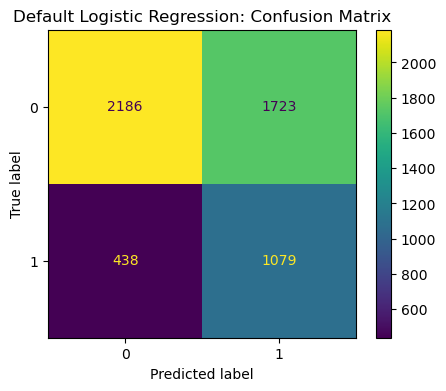

In [1321]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, lr_default_pred_test, ax=ax)
ax.set_title("Default Logistic Regression: Confusion Matrix")
plt.show()

The default logistic regression gives a useful first benchmark. On the validation set, it achieves a ROC-AUC of 0.6917 and a PR-AUC of 0.4295. This suggests that the available quote, customer and behavioural variables do contain meaningful predictive signal even without any tuning. This is important because it shows that the dataset is informative enough to support a real classification model rather than just a weak baseline.

On the test set, the model achieves a ROC-AUC of 0.6925 and a PR-AUC of 0.4375, so its out-of-sample performance is very similar to what was observed on the validation set. This consistency is reassuring, because it suggests that the model is not simply fitting noise in the development stage.

The classification report and confusion matrix show the main trade-off quite clearly. The model identifies a reasonable share of issued quotes but it does so at the cost of a relatively large number of false positives. This means that it is more willing to flag potential purchasers, even if that means incorrectly classifying some non-purchased quotes as purchased. This might be because of using class weights, the model is deliberately encouraged to pay more attention to the minority issued class. 

### 5.5.2 Tuned Logistic Regression

The logistic regression model was tuned by varying the regularisation strength parameter, C. Since ` is the inverse of penalty strength, smaller values correspond to stronger regularisation and larger values correspond to weaker regularisation. I focus on this parameter because regularisation affects how strongly the model shrinks coefficients, which in turn influences generalisation.

Following the earlier coursework feedback, the tuning was carried out in two stages. First, I run a broad log-scale search across a wide range of C values to identify the strongest region. Then I refine the search locally around the best broad-stage candidate. I prefer this approach because it is more systematic than choosing a narrow grid immediately and makes the final choice easier to justify.

In [ ]:
c_grid_broad = np.logspace(-4, 4, 9) # defining a broad grid of C values for logistic regression regularization 

lr_broad_results = [] # list to store results for each C value in the grid

for c in c_grid_broad:
    lr_broad = LogisticRegression(
        penalty="l2", # using L2 regularization to prevent overfitting while allowing all features to contribute
        C=c, # regularization strength (inverse of lambda), with a broad range to explore different levels of regularization
        solver="liblinear", # stable choice for binary classification and small to medium-sized datasets
        class_weight=class_weight_dict,
        max_iter=2000,
        random_state=42 #  setting random state for reproducibility of results across runs
    )

    lr_broad.fit(X_train_proc, y_train) # fitting the model on the processed training data

    y_val_prob_lr_broad = lr_broad.predict_proba(X_val_proc)[:, 1] # predicting probabilities for the positive class (issued as 1) on the validation set

    lr_broad_results.append({
        "C": c, # appending results for the current C value to the results list
        "val_roc_auc": roc_auc_score(y_val, y_val_prob_lr_broad), # calculating ROC-AUC score for the validation set predictions 
        "val_pr_auc": average_precision_score(y_val, y_val_prob_lr_broad) # calculating Precision-Recall AUC score for the validation set predictions and storing it 
    })

lr_broad_results = pd.DataFrame(lr_broad_results).sort_values( # sorting the results by validation ROC-AUC 
    "val_roc_auc", ascending=False # in descending order to identify the best performing C value based on this metric
)

lr_broad_results.round(4)

,C,val_roc_auc,val_pr_auc
3,0.1000,0.6923,0.4302
4,1.0000,0.6917,0.4295
5,10.0000,0.6916,0.4291
6,100.0000,0.6916,0.4289
8,10000.0000,0.6916,0.4288
7,1000.0000,0.6916,0.4288
2,0.0100,0.6904,0.4285
1,0.0010,0.6779,0.4219
0,0.0001,0.6560,0.4061


In [ ]:
# identifying the best C value from the broad search based on validation ROC-AUC
best_c_broad = lr_broad_results.iloc[0]["C"]
print("Best C from broad search:", best_c_broad)

Best C from broad search: 0.1


The broad search shows that very small values of C, which imply stronger regularisation, perform worse than the middle part of the search range. Validation ROC-AUC improves as the regularisation becomes less aggressive and then stabilises around a relatively narrow region. This suggests that some coefficient shrinkage is useful but that overly strong regularisation removes too much predictive signal.

In [ ]:
# Based on the broad search results, we can define a finer grid of C values around the best performing C to further refine our model tuning and potentially achieve better performance on the validation set
c_grid_fine = [0.03, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30]

lr_fine_results = []

for c in c_grid_fine:
    lr_fine = LogisticRegression( # creating a logistic regression model  
        penalty="l2", #with L2 regularization
        C=c, # the current C value from the fine grid
        solver="liblinear",
        class_weight=class_weight_dict,
        max_iter=2000, # setting a higher max_iter to ensure convergence, especially for smaller C values which can lead to stronger regularization and potentially slower convergence
        random_state=42 # setting random state for reproducibility of results across runs
    )

    lr_fine.fit(X_train_proc, y_train) # fitting the model on the processed training data

    y_val_prob_lr_fine = lr_fine.predict_proba(X_val_proc)[:, 1]

    lr_fine_results.append({
        "C": c,
        "val_roc_auc": roc_auc_score(y_val, y_val_prob_lr_fine),
        "val_pr_auc": average_precision_score(y_val, y_val_prob_lr_fine)
    })

lr_fine_results = pd.DataFrame(lr_fine_results).sort_values(
    "val_roc_auc", ascending=False
)

lr_fine_results.round(4)

,C,val_roc_auc,val_pr_auc
1,0.05,0.6924,0.4304
2,0.08,0.6923,0.4303
3,0.10,0.6923,0.4302
4,0.15,0.6922,0.4301
0,0.03,0.6921,0.4301
5,0.20,0.6921,0.4300
6,0.30,0.6920,0.4299


In [1325]:
best_c_final = lr_fine_results.iloc[0]["C"]
print("Best final C:", best_c_final)

Best final C: 0.05


The fine search confirms that the strongest validation performance is achieved in a narrow region around C = 0.05 to 0.10. The differences across the top-performing values are very small, which suggests that the model is reasonably stable in this part of the parameter space. I therefore select C = 0.05 as the final tuned value.

In [ ]:
lr_tuned = LogisticRegression( # creating a logistic regression model with the best C value identified from the fine grid search
    penalty="l2",
    C=float(best_c_final),
    solver="liblinear",
    class_weight=class_weight_dict,
    max_iter=2000,
    random_state=42
)

lr_tuned.fit(X_train_proc, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.05
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*","{np.int64(0): np.float64(0.6940683076585713), np.int64(1): np.float64(1.7882062146892654)}"
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver

In [ ]:
# validation predictions and probabilities with the tuned model
y_val_pred_lr_tuned = lr_tuned.predict(X_val_proc)
y_val_prob_lr_tuned = lr_tuned.predict_proba(X_val_proc)[:, 1]

print("Validation accuracy:", round(accuracy_score(y_val, y_val_pred_lr_tuned), 4))
print("Validation ROC-AUC :", round(roc_auc_score(y_val, y_val_prob_lr_tuned), 4))
print("Validation PR-AUC  :", round(average_precision_score(y_val, y_val_prob_lr_tuned), 4))

# test predictions and probabilities with the tuned model
y_test_pred_lr_tuned = lr_tuned.predict(X_test_proc)
y_test_prob_lr_tuned = lr_tuned.predict_proba(X_test_proc)[:, 1]

lr_tuned_acc_test = accuracy_score(y_test, y_test_pred_lr_tuned)
lr_tuned_auc_test = roc_auc_score(y_test, y_test_prob_lr_tuned)
lr_tuned_pr_test  = average_precision_score(y_test, y_test_prob_lr_tuned)

print("\nTuned Logistic Regression - Test")
print("Accuracy :", round(lr_tuned_acc_test, 4))
print("ROC-AUC  :", round(lr_tuned_auc_test, 4))
print("PR-AUC   :", round(lr_tuned_pr_test, 4))

Validation accuracy: 0.6062
Validation ROC-AUC : 0.6924
Validation PR-AUC  : 0.4304

Tuned Logistic Regression - Test
Accuracy : 0.6006
ROC-AUC  : 0.6921
PR-AUC   : 0.4359


The tuned logistic regression improves validation performance slightly relative to the default benchmark but the gain is very small. On the validation set, the model achieves a ROC-AUC of 0.6924 and a PR-AUC of 0.4304, which is only marginally above the untuned version. On the test set, the model achieves a ROC-AUC of 0.6921 and a PR-AUC of 0.4359, so its out-of-sample performance is essentially unchanged.

This result suggests that tuning the regularisation strength makes the model-selection process more disciplined but it does not materially change the predictive power of the logistic regression model. The classification report and confusion matrix also remain very similar to the default specification, which indicates that tuning does not substantially alter the practical trade-off between identifying purchased quotes and generating false positives.


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.56      0.67      3909
           1       0.38      0.71      0.50      1517

    accuracy                           0.60      5426
   macro avg       0.61      0.63      0.58      5426
weighted avg       0.71      0.60      0.62      5426



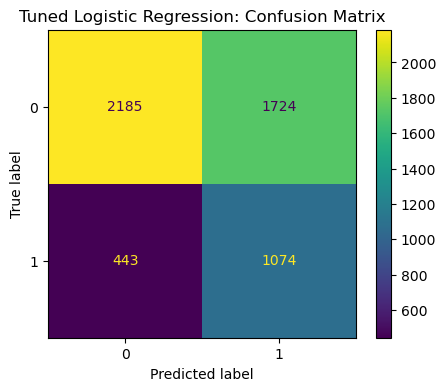

In [ ]:
#  classification report and confusion matrix for the tuned logistic regression model on the test set 
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_lr_tuned))

#confusion matrix 
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_lr_tuned, ax=ax)
ax.set_title("Tuned Logistic Regression: Confusion Matrix")
plt.show()

The classification report shows that the tuned logistic regression still performs unevenly across the two classes. For the non-purchased class (0), precision is relatively high at 0.83, which means that when the model predicts a quote will not be purchased, it is often correct. For the purchased class (1), recall is stronger at 0.71, which means the model is able to identify a reasonable share of actual purchasers. However, precision for the purchased class remains low at 0.38, so many quotes predicted as purchased are in fact false positives.

The model is more willing to flag potential purchasers, which helps minority-class recall but this comes at the cost of lower precision and only moderate accuracy. Because class weights were used, this pattern is not surprising.

The confusion matrix makes the trade-off more concrete. The tuned model correctly identifies 1,074 purchased quotes but it also incorrectly classifies 1,724 non-purchased quotes as purchased. At the same time, 443 purchased quotes are still missed. So although the model is fairly sensitive to the purchased class, that sensitivity comes with a high false-positive rate.

In practical terms, this means the model could be useful as a screening tool if Telepass prefers to capture more potential purchasers even at the cost of contacting or targeting some customers who would not convert. However, if false positives are costly, then this threshold-level performance is less attractive.

The tuned logistic regression is slightly more systematic than the default benchmark but its practical prediction pattern remains very similar. The main value of tuning here is therefore in making model selection more disciplined rather than in producing a materially different classifier.

## 5.6 Feedforward Neural Network

After establishing logistic regression as a linear benchmark, I next estimate feedforward neural networks. A feedforward network is appropriate here because the dataset is structured and tabular rather than sequential or image-based. The neural network therefore provides a more flexible alternative to logistic regression, allowing for non-linear effects and interactions between the predictors.

I develop the neural network models in stages. First, I estimate a simple unregularised network to establish a neural benchmark. Second, I introduce regularisation techniques to improve generalisation. Third, I estimate a more systematically tuned version to assess whether additional optimisation leads to a meaningful gain in out-of-sample performance.

Before fitting the neural network models, the preprocessed arrays are converted to dense float32 format. The ColumnTransformer may return a sparse matrix after one-hot encoding, so we convert explicitly. TensorFlow requires float32 inputs and class weights must be plain Python floats rather than numpy types.

In [1330]:
X_train_nn = X_train_proc.toarray() if hasattr(X_train_proc, "toarray") else X_train_proc
X_val_nn   = X_val_proc.toarray() if hasattr(X_val_proc, "toarray") else X_val_proc
X_test_nn  = X_test_proc.toarray() if hasattr(X_test_proc, "toarray") else X_test_proc

X_train_nn = X_train_nn.astype("float32")
X_val_nn   = X_val_nn.astype("float32")
X_test_nn  = X_test_nn.astype("float32")

y_train_nn = y_train.astype("float32")
y_val_nn   = y_val.astype("float32")
y_test_nn  = y_test.astype("float32")

class_weight_nn = {
    0: float(class_weight_dict[0]),
    1: float(class_weight_dict[1])
}

### 5.6.1 Neural Network v1: Unregularised

The first neural network specification is intentionally simple. I use a basic feedforward architecture with two dense hidden layers and no explicit regularisation. The purpose of this model is to establish a neural benchmark and to test whether a flexible non-linear model improves on the logistic regression baseline.

I chose dense layers because the dataset is tabular and the prediction task is a standard binary classification problem. ReLU is used in the hidden layers because it is computationally efficient and works well in practice, while the output layer uses a sigmoid activation so that the model returns a probability of quote purchase. I use binary cross-entropy as the loss function because it is appropriate for binary classification and Adam as the optimiser because it is a strong default choice for neural network training.

I deliberately keep this first version unregularised. At this stage, I do not want to build the best possible neural network straight away. Instead, I want to see how a plain feedforward model behaves, whether it improves predictive performance and whether signs of overfitting appear in the training curves.

In [ ]:
tf.keras.utils.set_random_seed(42) # setting random seed for reproducibility of results across runs in TensorFlow

nn_v1 = Sequential([ # defining a simple feedforward neural network architecture with two hidden layers 
    Dense(64, activation="relu", input_shape=(X_train_nn.shape[1],)), # first hidden layer with 64 neurons and ReLU activation
    Dense(32, activation="relu"), # second hidden layer with 32 neurons and ReLU activation
    Dense(1, activation="sigmoid") # output layer with 1 neuron and sigmoid activation for binary classification, outputting a probability of the positive class (issued=1)
])

nn_v1.compile( # compiling the neural network model with the Adam optimizer for binary classification
    optimizer=keras.optimizers.Adam(learning_rate=0.001), # using the Adam optimizer with a learning rate of 0.001 
    loss="binary_crossentropy", # using binary cross-entropy loss function which is appropriate for binary classification tasks
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"), # adding binary accuracy as a metric to evaluate the proportion of correct predictions (both classes) during training and validation
        keras.metrics.AUC(name="roc_auc") # adding AUC as a metric to evaluate the model's ability to discriminate between the two classes during training and validation
    ]
)

#  training  for enough epochs to see whether the model starts to overfit
history_v1 = nn_v1.fit(
    X_train_nn, y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=50, # setting the number of epochs to 50 for training the neural network,
    batch_size=64, # setting the batch size to 64 samples per batch 
    class_weight=class_weight_nn,
    verbose=1
)

Epoch 1/50
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 912us/step - accuracy: 0.5828 - loss: 0.6478 - roc_auc: 0.6585 - val_accuracy: 0.5737 - val_loss: 0.6478 - val_roc_auc: 0.6902
Epoch 2/50
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 456us/step - accuracy: 0.6263 - loss: 0.6060 - roc_auc: 0.7186 - val_accuracy: 0.5951 - val_loss: 0.6241 - val_roc_auc: 0.7106
Epoch 3/50
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 453us/step - accuracy: 0.6431 - loss: 0.5845 - roc_auc: 0.7424 - val_accuracy: 0.6095 - val_loss: 0.6098 - val_roc_auc: 0.7230
Epoch 4/50
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 463us/step - accuracy: 0.6580 - loss: 0.5673 - roc_auc: 0.7607 - val_accuracy: 0.6157 - val_loss: 0.6003 - val_roc_auc: 0.7333
Epoch 5/50
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 444us/step - accuracy: 0.6701 - loss: 0.5528 - roc_auc: 0.7756 - val_accuracy: 0.6165 - val_loss: 0.5949 - val_roc_auc: 0.7398
Epoch 6/50
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 467us/step - accuracy: 0.6824 - loss: 0.5410 - roc_auc: 0.7872 - val_accuracy: 0.6238 - val_loss: 0.5920 - 

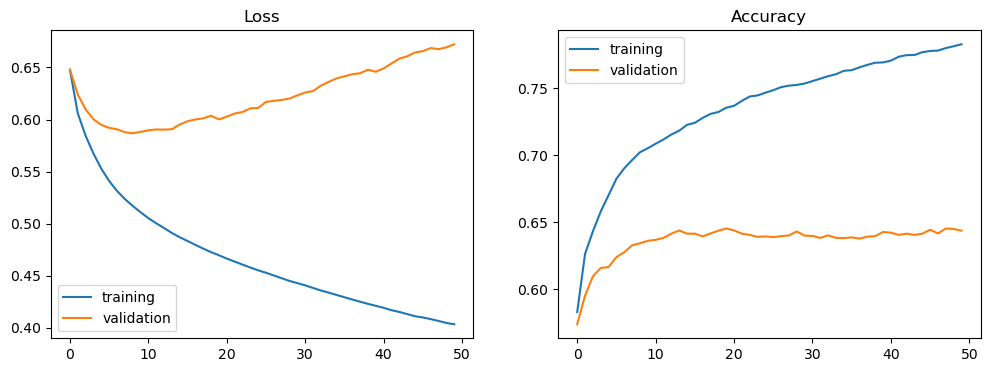

In [1332]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(history_v1.history["loss"], label="training")
axes[0].plot(history_v1.history["val_loss"], label="validation")
axes[0].set_title("Loss")
axes[0].legend()

# Accuracy
axes[1].plot(history_v1.history["accuracy"], label="training")
axes[1].plot(history_v1.history["val_accuracy"], label="validation")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.show()

The training curves suggest that the unregularised neural network does learn useful signal but they also show clear signs of overfitting. Training loss falls steadily throughout the full training run, while validation loss improves only in the earlier epochs before beginning to rise again. A similar pattern appears in the accuracy curves: training accuracy continues to improve but validation accuracy levels off and changes very little after the earlier part of training.

The model is becoming increasingly specialised to the training data rather than continuing to improve its ability to generalise. The plain feedforward network is flexible enough to fit structure in the data however without regularisation it begins to fit the training sample more closely than is desirable. This is exactly the reason for introducing dropout, batch normalisation and early stopping in the next specification.

Neural Network v1 - Validation
Accuracy : 0.6436
ROC-AUC  : 0.748
PR-AUC   : 0.5486

Neural Network v1 - Test
Accuracy : 0.6502
ROC-AUC  : 0.7409
PR-AUC   : 0.55

Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.64      0.72      3909
         1.0       0.42      0.69      0.52      1517

    accuracy                           0.65      5426
   macro avg       0.63      0.66      0.62      5426
weighted avg       0.72      0.65      0.67      5426



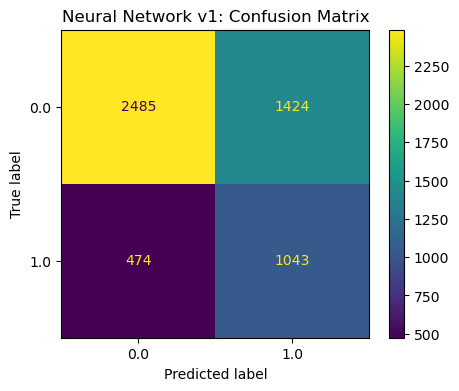

In [ ]:
# Validation probabilities and class predictions
nn_v1_prob_val = nn_v1.predict(X_val_nn, verbose=0).ravel()
nn_v1_pred_val = (nn_v1_prob_val >= 0.5).astype(int)

# validation metrics
nn_v1_acc_val = accuracy_score(y_val_nn, nn_v1_pred_val)
nn_v1_auc_val = roc_auc_score(y_val_nn, nn_v1_prob_val)
nn_v1_pr_val  = average_precision_score(y_val_nn, nn_v1_prob_val)

print("Neural Network v1 - Validation")
print("Accuracy :", round(nn_v1_acc_val, 4))
print("ROC-AUC  :", round(nn_v1_auc_val, 4))
print("PR-AUC   :", round(nn_v1_pr_val, 4))

# Test predictions
nn_v1_prob_test = nn_v1.predict(X_test_nn, verbose=0).ravel()
nn_v1_pred_test = (nn_v1_prob_test >= 0.5).astype(int)

#test metrics
nn_v1_acc_test = accuracy_score(y_test_nn, nn_v1_pred_test)
nn_v1_auc_test = roc_auc_score(y_test_nn, nn_v1_prob_test)
nn_v1_pr_test  = average_precision_score(y_test_nn, nn_v1_prob_test)

print("\nNeural Network v1 - Test")
print("Accuracy :", round(nn_v1_acc_test, 4))
print("ROC-AUC  :", round(nn_v1_auc_test, 4))
print("PR-AUC   :", round(nn_v1_pr_test, 4))

print("\nClassification Report:")
print(classification_report(y_test_nn, nn_v1_pred_test))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test_nn, nn_v1_pred_test, ax=ax)
ax.set_title("Neural Network v1: Confusion Matrix")
plt.show()

Despite the overfitting visible in the training curves, the unregularised neural network improves noticeably on the logistic regression benchmark. On the validation set, it achieves an accuracy of 0.6436, a ROC-AUC of 0.7480 and a PR-AUC of 0.5486. On the test set, it achieves an accuracy of 0.6502, a ROC-AUC of 0.7409 and a PR-AUC of 0.5500.

The dataset contains useful non-linear signal that the logistic regression models do not capture fully. Allowing for a more flexible functional form does improve predictive performance. As the validation and test scores remain below the training trajectory suggested by the curves, the results also confirm that flexibility alone is not enough. The network needs better control of generalisation, which motivates the regularised version in the next section.

### 5.6.2 Neural Network v2: Regularised

The second neural network specification keeps the same basic feedforward structure but adds explicit regularisation. The earlier unregularised network achieved stronger predictive performance than logistic regression but the training curves showed a widening gap between training and validation behaviour. That pattern raised concerns about overfitting and made a more controlled specification necessary.

Three regularisation choices are introduced here. First, dropout is added after each hidden layer so that the network cannot rely too heavily on a small subset of units during training. Second, batch normalisation is included to stabilise the learning process and make optimisation less erratic. Third, early stopping is used so that training halts once validation loss stops improving, with the best weights restored automatically.

The architecture itself remains close to the first network. Keeping the same broad structure makes the comparison easier to interpret, because any change in performance can be linked more directly to regularisation rather than to a completely different model design. The key question in this section is whether a more disciplined neural network setup can improve out of sample performance while reducing the instability seen in v1.

In [ ]:
tf.keras.utils.set_random_seed(42) # fixxing the random seed so this training run is reproducible

nn_v2 = Sequential([ # keeping the same 64-32 structure as v1 but add regularisation after each hidden layer
    Dense(64, activation="relu", input_shape=(X_train_nn.shape[1],)),
    BatchNormalization(),
    Dropout(0.30),

    Dense(32, activation="relu"),
    BatchNormalization(),
    Dropout(0.30),

    Dense(1, activation="sigmoid")
])

#compiling for binary classification and track both accuracy and ROC-AUC
nn_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.AUC(name="roc_auc")
    ]
)

early_stop_v2 = EarlyStopping( #stops once validation loss stops improving and keep the best weights
    monitor="val_loss",
    mode="min",
    patience=5,
    restore_best_weights=True
)

# it trains long enough to let the model learn but allow early stopping to cut training short
history_v2 = nn_v2.fit(
    X_train_nn, y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=50,
    batch_size=64,
    class_weight=class_weight_nn,
    callbacks=[early_stop_v2],
    verbose=1
)

Epoch 1/50
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5479 - loss: 0.7375 - roc_auc: 0.5844 - val_accuracy: 0.5509 - val_loss: 0.6605 - val_roc_auc: 0.6738
Epoch 2/50
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 594us/step - accuracy: 0.5788 - loss: 0.6574 - roc_auc: 0.6464 - val_accuracy: 0.5728 - val_loss: 0.6376 - val_roc_auc: 0.6919
Epoch 3/50
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5955 - loss: 0.6343 - roc_auc: 0.6795 - val_accuracy: 0.5805 - val_loss: 0.6276 - val_roc_auc: 0.7002
Epoch 4/50
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 603us/step - accuracy: 0.6076 - loss: 0.6239 - roc_auc: 0.6947 - val_accuracy: 0.5916 - val_loss: 0.6171 - val_roc_auc: 0.7094
Epoch 5/50
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 554us/step - accuracy: 0.6125 - loss: 0.6155 - roc_auc: 0.7037 - val_accuracy: 0.5993 - val_loss: 0.6057 - val_roc_auc: 0.7166
Epoch 6/50
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 556us/step - accuracy: 0.6144 - loss: 0.6084 - roc_auc: 0.7113 - val_accuracy: 0.6067 - val_loss: 0.5987 - val_

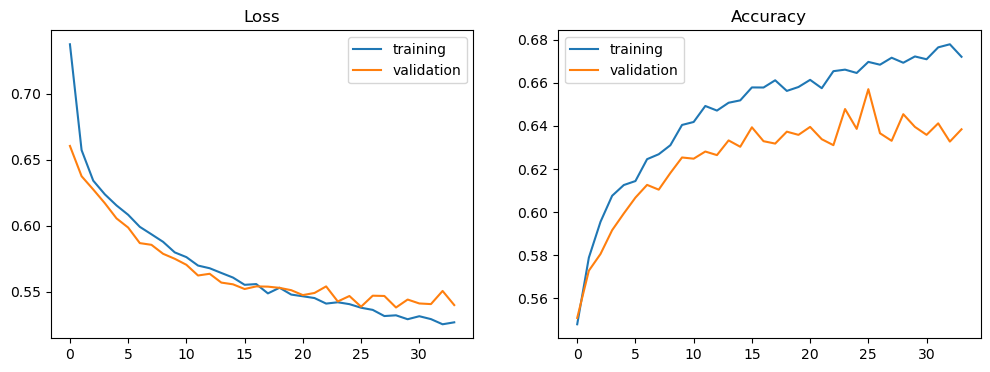

In [1335]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(history_v2.history["loss"], label="training")
axes[0].plot(history_v2.history["val_loss"], label="validation")
axes[0].set_title("Loss")
axes[0].legend()

# Accuracy
axes[1].plot(history_v2.history["accuracy"], label="training")
axes[1].plot(history_v2.history["val_accuracy"], label="validation")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.show()

The training curves are noticeably more stable than in the unregularised network. Both training and validation loss fall sharply in the early epochs and then flatten gradually, with only a modest gap between them. Validation loss no longer drifts upward in the way seen previously, which means the model is no longer fitting the training data at the expense of generalisation to the same degree.

The accuracy curves tell a similar story. Training accuracy continues to rise but validation accuracy also improves and remains comparatively steady rather than flattening too early or deteriorating. The remaining gap between the two curves shows that the model is still more confident on the training set than on unseen data however the divergence is much smaller than before.

Taken together, the curves indicate that the regularisation choices are helping the network learn in a more controlled way. The model still benefits from the flexibility of a neural network but the learning process is less unstable and less prone to the clear overfitting pattern observed in v1.

Neural Network v2 - Validation
Accuracy : 0.6454
ROC-AUC  : 0.7717
PR-AUC   : 0.5958

Neural Network v2 - Test
Accuracy : 0.6447
ROC-AUC  : 0.7702
PR-AUC   : 0.5915

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.60      0.71      3909
         1.0       0.42      0.77      0.55      1517

    accuracy                           0.64      5426
   macro avg       0.65      0.68      0.63      5426
weighted avg       0.74      0.64      0.66      5426



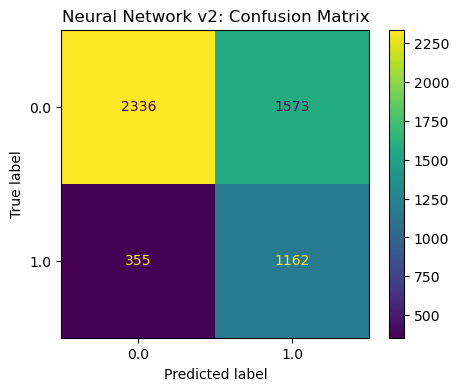

In [ ]:
# Validation predictions
nn_v2_prob_val = nn_v2.predict(X_val_nn, verbose=0).ravel()
nn_v2_pred_val = (nn_v2_prob_val >= 0.5).astype(int)

#validation metrics 
nn_v2_acc_val = accuracy_score(y_val_nn, nn_v2_pred_val)
nn_v2_auc_val = roc_auc_score(y_val_nn, nn_v2_prob_val)
nn_v2_pr_val  = average_precision_score(y_val_nn, nn_v2_prob_val)

print("Neural Network v2 - Validation")
print("Accuracy :", round(nn_v2_acc_val, 4))
print("ROC-AUC  :", round(nn_v2_auc_val, 4))
print("PR-AUC   :", round(nn_v2_pr_val, 4))

# Test predictions
nn_v2_prob_test = nn_v2.predict(X_test_nn, verbose=0).ravel()
nn_v2_pred_test = (nn_v2_prob_test >= 0.5).astype(int)

#test metrics
nn_v2_acc_test = accuracy_score(y_test_nn, nn_v2_pred_test)
nn_v2_auc_test = roc_auc_score(y_test_nn, nn_v2_prob_test)
nn_v2_pr_test  = average_precision_score(y_test_nn, nn_v2_prob_test)

print("\nNeural Network v2 - Test")
print("Accuracy :", round(nn_v2_acc_test, 4))
print("ROC-AUC  :", round(nn_v2_auc_test, 4))
print("PR-AUC   :", round(nn_v2_pr_test, 4))

#classification report results 
print("\nClassification Report:")
print(classification_report(y_test_nn, nn_v2_pred_test))

#confusin matrix display for the neural network v2 model on the test set
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test_nn, nn_v2_pred_test, ax=ax)
ax.set_title("Neural Network v2: Confusion Matrix")
plt.show()

The regularised network delivers the strongest results so far. On the validation set, it reaches an accuracy of 0.6454, a ROC-AUC of 0.7717 and a PR-AUC of 0.5958. On the test set, it records an accuracy of 0.6447, a ROC-AUC of 0.7702 and a PR-AUC of 0.5915.

These numbers are important for two reasons. First, the model continues to outperform both versions of logistic regression, which reinforces the view that the dataset contains useful non-linear structure. Second, the validation and test scores remain very close to one another, which points to stronger generalisation than in the earlier unregularised network.

The gain is especially clear in ROC-AUC and PR-AUC. Since the target class is imbalanced, improvement on these measures carries more weight than a small movement in raw accuracy alone. In practical terms, the regularised network is not just fitting the training set more effectively; it is also ranking and separating purchased quotes more successfully on unseen data.

The classification report shows a more balanced practical profile than the earlier models. For the non purchased class (0), precision is high at 0.87, which means the model is usually correct when it predicts that a quote will not convert. For the purchased class (1), recall rises to 0.77, showing that a larger share of actual purchasers is being captured than before. Precision for the purchased class remains lower at 0.42, so false positives are still a material issue but the model now identifies positive cases more effectively.

The confusion matrix supports that reading. The network correctly identifies 1,162 purchased quotes and misses 355, which is an improvement over v1 in terms of false negatives. At the same time, 1,573 non purchased quotes are still incorrectly flagged as purchased. So the model remains relatively aggressive in identifying likely purchasers however the stronger recall is now achieved alongside better overall ranking performance and a more stable training pattern.

From a business perspective, this version is more appealing than the earlier models when missing potential purchasers is considered more costly than reviewing some false alarms. The remaining weakness is that the model still lacks high precision on the purchased class, so it is better suited to prioritisation or screening than to fully automated decision-making.

The regularised network is a meaningful step forward from both the unregularised neural network and the logistic regression benchmarks. The curves are more stable, validation and test performance are closely aligned and the ranking metrics improve further. The remaining question is whether a more systematic tuning process can push performance higher still without sacrificing this stronger generalisation pattern.

### 5.6.3 Neural Network v3: Optional Tuned Network

The third neural network specification introduces a more structured tuning step. At this stage, the aim is no longer to prove that neural networks can work on this dataset, because that has already been shown in the previous two models. The purpose here is to check whether a more careful choice of hyperparameters can produce an additional gain beyond the regularised network.

The tuning focuses on a small set of hyperparameters that usually have a strong effect on feedforward networks for tabular classification. The learning rate controls how quickly the optimiser updates the weights. The hidden-layer layout controls model capacity. The dropout rate affects how strongly the network is regularised. Batch size influences the stability and speed of optimisation. These are practical tuning levers with a direct connection to model behaviour, so they are a sensible place to concentrate the search.

To keep the process manageable, tuning is carried out in two stages. A broader search is used first to identify the most promising region of the search space. A narrower local search is then run around the strongest broad candidate. Validation results are used for model selection throughout, while the test set stays untouched until the final tuned network has been chosen.

In [ ]:
# building  a feedforward network where the main design choices can be changed easily
def build_nn_tuned(input_dim, learning_rate=0.001, units=(128, 64), dropout_rate=0.30):
    model = Sequential()

    # First hidden layer takes the full input feature vector
    model.add(Dense(units[0], activation="relu", input_shape=(input_dim,)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    #adds any remaining hidden layers from the chosen architecture
    for u in units[1:]:
        model.add(Dense(u, activation="relu"))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    # single sigmoid output for binary classification
    model.add(Dense(1, activation="sigmoid"))

    # compiling with Adam and evaluate both threshold-based and ranking performance
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="roc_auc")
        ]
    )
    return model

The first tuning stage uses a compact broad search over a small number of candidate configurations. Rather than searching every possible combination, the goal is to compare a few plausible settings that differ in learning rate, network width, dropout strength and batch size. This gives a practical overview of which region of the hyperparameter space deserves closer attention.

The search remains deliberately limited. Since neural network tuning can become very expensive, a focused search is more appropriate here than a very large grid with weak justification. What matters is not exhaustively checking every possibility but identifying whether a materially stronger configuration appears within a sensible range.

In [ ]:
# broad candidate configurations for the tuned network
#these vary optimisation speed, model size, regularisation strength and batch size
broad_configs = [
    {"learning_rate": 1e-4, "units": (64, 32),     "dropout": 0.20, "batch_size": 32},
    {"learning_rate": 1e-4, "units": (128, 64),    "dropout": 0.30, "batch_size": 64},
    {"learning_rate": 5e-4, "units": (64, 32),     "dropout": 0.30, "batch_size": 64},
    {"learning_rate": 5e-4, "units": (128, 64),    "dropout": 0.30, "batch_size": 64},
    {"learning_rate": 1e-3, "units": (64, 32),     "dropout": 0.20, "batch_size": 64},
    {"learning_rate": 1e-3, "units": (128, 64),    "dropout": 0.30, "batch_size": 64},
    {"learning_rate": 1e-3, "units": (128, 64, 32),"dropout": 0.40, "batch_size": 128}
]

nn_broad_results = []

for cfg in broad_configs:
    tf.keras.utils.set_random_seed(42)   # ressetting the random seed so the configuration comparison is as fair as possible

    #building one candidate model from the current configuration
    nn_broad = build_nn_tuned(
        input_dim=X_train_nn.shape[1],
        learning_rate=cfg["learning_rate"],
        units=cfg["units"],
        dropout_rate=cfg["dropout"]
    )

    early_stop_broad = EarlyStopping( # stopping early if validation loss no longer improves
        monitor="val_loss",
        mode="min",
        patience=5,
        restore_best_weights=True
    )

    history_broad = nn_broad.fit( # train and validate the candidate network
        X_train_nn, y_train_nn,
        validation_data=(X_val_nn, y_val_nn),
        epochs=40,
        batch_size=cfg["batch_size"],
        class_weight=class_weight_nn,
        callbacks=[early_stop_broad],
        verbose=0
    )

    # getting the validation probabilities and convert them to class predictions
    y_val_prob_nn_broad = nn_broad.predict(X_val_nn, verbose=0).ravel()
    y_val_pred_nn_broad = (y_val_prob_nn_broad >= 0.5).astype(int)

    nn_broad_results.append({ # storing the validation metrics for later comparison
        "learning_rate": cfg["learning_rate"],
        "units": cfg["units"],
        "dropout": cfg["dropout"],
        "batch_size": cfg["batch_size"],
        "val_accuracy": accuracy_score(y_val_nn, y_val_pred_nn_broad),
        "val_roc_auc": roc_auc_score(y_val_nn, y_val_prob_nn_broad),
        "val_pr_auc": average_precision_score(y_val_nn, y_val_prob_nn_broad),
        "epochs_ran": len(history_broad.history["loss"])
    })

nn_broad_results = pd.DataFrame(nn_broad_results).sort_values( # ranking by valuation ROC-AUC 
    "val_roc_auc", ascending=False
)

nn_broad_results.round(4)

,learning_rate,units,dropout,batch_size,val_accuracy,val_roc_auc,val_pr_auc,epochs_ran
6,0.0010,"(128, 64, 32)",0.4,128,0.6664,0.7848,0.6065,36
4,0.0010,"(64, 32)",0.2,64,0.6718,0.7833,0.6094,30
3,0.0005,"(128, 64)",0.3,64,0.6672,0.7788,0.6026,35
5,0.0010,"(128, 64)",0.3,64,0.6672,0.7776,0.5999,22
2,0.0005,"(64, 32)",0.3,64,0.6432,0.7726,0.5965,40
1,0.0001,"(128, 64)",0.3,64,0.6283,0.7441,0.5457,40
0,0.0001,"(64, 32)",0.2,32,0.6237,0.7350,0.5309,40


The broad search points to a clear leading region. The strongest candidate uses a learning rate of 0.001, a three-layer structure of (128, 64, 32), a dropout rate of 0.40 and a batch size of 128. This configuration reaches a validation ROC-AUC of 0.7848 and a validation PR-AUC of 0.6065.

Two patterns stand out from this first stage. First, the stronger candidates tend to use the deeper (128, 64, 32) layout rather than the smaller two-layer versions, which suggests that the dataset benefits from a little more representational capacity. Second, relatively strong dropout remains near the top of the table, which is consistent with the earlier finding that this modelling problem still needs regularisation even when predictive performance is improving.

The broad search is not treated as the final answer. Its role is to locate a promising neighbourhood. The best broad candidate is therefore used as the centre of a narrower refinement step.

In [ ]:
best_broad_row = nn_broad_results.iloc[0] # taking the highest-ranked broad-search result as the centre of the local refinement

best_lr_broad = float(best_broad_row["learning_rate"])
best_dropout_broad = float(best_broad_row["dropout"])
best_batch_broad = int(best_broad_row["batch_size"])
best_units_broad = best_broad_row["units"]

print("Best broad configuration:")
print("learning_rate =", best_lr_broad)
print("units         =", best_units_broad)
print("dropout       =", best_dropout_broad)
print("batch_size    =", best_batch_broad)

Best broad configuration:
learning_rate = 0.001
units         = (128, 64, 32)
dropout       = 0.4
batch_size    = 128


The second tuning stage narrows the search around the strongest broad candidate. At this point, the architecture is fixed at the best broad layout, while the search focuses on smaller adjustments to learning rate, dropout and batch size. This makes the tuning more targeted and avoids spending time on combinations that already looked weaker in the broad stage.

The local search serves a different purpose from the broad one. The broad stage is mainly directional, while the fine stage is used to see whether small changes around the leading configuration can extract a little more validation performance without changing the overall shape of the model.

In [ ]:
# local refinement around the best broad-search candidate
lr_fine_grid = [0.0008, 0.0010, 0.0012]
dropout_fine_grid = [0.30, 0.35, 0.40, 0.45]
batch_fine_grid = [64, 128]

nn_fine_results = []

for lr in lr_fine_grid:
    for dr in dropout_fine_grid:
        for bs in batch_fine_grid:
            tf.keras.utils.set_random_seed(42) # keeping the run reproducible across fine-grid trials

            nn_fine = build_nn_tuned( # rebuilding the model using the best broad architecture
                input_dim=X_train_nn.shape[1],
                learning_rate=lr,
                units=best_units_broad,
                dropout_rate=dr
            )

            # early stopping again protects against unnecessary over-training
            early_stop_fine = EarlyStopping(
                monitor="val_loss",
                mode="min",
                patience=5,
                restore_best_weights=True
            )

            history_fine = nn_fine.fit( #trainning the fine-grid candidate
                X_train_nn, y_train_nn,
                validation_data=(X_val_nn, y_val_nn),
                epochs=50,
                batch_size=bs,
                class_weight=class_weight_nn,
                callbacks=[early_stop_fine],
                verbose=0
            )
            # evaluating on the validation set
            y_val_prob_nn_fine = nn_fine.predict(X_val_nn, verbose=0).ravel()
            y_val_pred_nn_fine = (y_val_prob_nn_fine >= 0.5).astype(int)

            nn_fine_results.append({
                "learning_rate": lr,
                "units": best_units_broad,
                "dropout": dr,
                "batch_size": bs,
                "val_accuracy": accuracy_score(y_val_nn, y_val_pred_nn_fine),
                "val_roc_auc": roc_auc_score(y_val_nn, y_val_prob_nn_fine),
                "val_pr_auc": average_precision_score(y_val_nn, y_val_prob_nn_fine),
                "epochs_ran": len(history_fine.history["loss"])
            })

nn_fine_results = pd.DataFrame(nn_fine_results).sort_values(
    "val_roc_auc", ascending=False
)

nn_fine_results.round(4)

,learning_rate,units,dropout,batch_size,val_accuracy,val_roc_auc,val_pr_auc,epochs_ran
12,0.0010,"(128, 64, 32)",0.40,64,0.6732,0.7902,0.6221,43
2,0.0008,"(128, 64, 32)",0.35,64,0.6738,0.7852,0.6165,40
3,0.0008,"(128, 64, 32)",0.35,128,0.6790,0.7851,0.6123,44
13,0.0010,"(128, 64, 32)",0.40,128,0.6664,0.7848,0.6065,36
4,0.0008,"(128, 64, 32)",0.40,64,0.6751,0.7840,0.6132,46
5,0.0008,"(128, 64, 32)",0.40,128,0.6791,0.7837,0.6121,49
9,0.0010,"(128, 64, 32)",0.30,128,0.6692,0.7825,0.6104,34
8,0.0010,"(128, 64, 32)",0.30,64,0.6771,0.7819,0.6096,34
23,0.0012,"(128, 64, 32)",0.45,128,0.6731,0.7817,0.6108,37
19,0.0012,"(128, 64, 32)",0.35,128,0.6699,0.7817,0.6083,30


In [1341]:
best_nn_row = nn_fine_results.iloc[0]

best_lr_final = float(best_nn_row["learning_rate"])
best_units_final = best_nn_row["units"]
best_dropout_final = float(best_nn_row["dropout"])
best_batch_final = int(best_nn_row["batch_size"])

print("Best final configuration:")
print("learning_rate =", best_lr_final)
print("units         =", best_units_final)
print("dropout       =", best_dropout_final)
print("batch_size    =", best_batch_final)

Best final configuration:
learning_rate = 0.001
units         = (128, 64, 32)
dropout       = 0.4
batch_size    = 64


The local refinement produces a modest but meaningful improvement over the broad search. The best refined configuration keeps the same three-layer structure and the same learning rate of 0.001 but it performs best with a batch size of 64 rather than 128, while retaining dropout at 0.40. This version reaches a validation accuracy of 0.6732, a validation ROC-AUC of 0.7902 and a validation PR-AUC of 0.6221.

That outcome is useful because it shows that the broad search had already located the right part of the tuning space. The fine search does not overturn the earlier result; instead, it sharpens it. In particular, the gain in PR-AUC is notable, since that metric is especially relevant when the positive class is less frequent and the task involves ranking likely purchasers effectively.

The tuned configuration is therefore taken forward as the final neural network specification for test set evaluation.

In [ ]:
tf.keras.utils.set_random_seed(42) #refitting the tuned network using the best hyperparameters found in the refinement step

nn_v3 = build_nn_tuned(
    input_dim=X_train_nn.shape[1],
    learning_rate=best_lr_final,
    units=best_units_final,
    dropout_rate=best_dropout_final
)

early_stop_v3 = EarlyStopping( # using early stopping once more when fitting the final tuned model
    monitor="val_loss",
    mode="min",
    patience=5,
    restore_best_weights=True
)

history_v3 = nn_v3.fit( # training the final tuned network
    X_train_nn, y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=50,
    batch_size=best_batch_final,
    class_weight=class_weight_nn,
    callbacks=[early_stop_v3],
    verbose=1
)

Epoch 1/50
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5390 - loss: 0.7709 - roc_auc: 0.5653 - val_accuracy: 0.5676 - val_loss: 0.6410 - val_roc_auc: 0.6642
Epoch 2/50
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 710us/step - accuracy: 0.5661 - loss: 0.6656 - roc_auc: 0.6296 - val_accuracy: 0.5765 - val_loss: 0.6275 - val_roc_auc: 0.6855
Epoch 3/50
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 704us/step - accuracy: 0.5793 - loss: 0.6452 - roc_auc: 0.6608 - val_accuracy: 0.5851 - val_loss: 0.6191 - val_roc_auc: 0.7041
Epoch 4/50
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 702us/step - accuracy: 0.5922 - loss: 0.6313 - roc_auc: 0.6828 - val_accuracy: 0.6126 - val_loss: 0.6059 - val_roc_auc: 0.7164
Epoch 5/50
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 714us/step - accuracy: 0.6008 - loss: 0.6225 - roc_auc: 0.6932 - val_accuracy: 0.6108 - val_loss: 0.5970 - val_roc_auc: 0.7221
Epoch 6/50
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 699us/step - accuracy: 0.6087 - loss: 0.6142 - roc_auc: 0.7050 - val_accuracy: 0.6176 - val_loss: 0.5893 - va

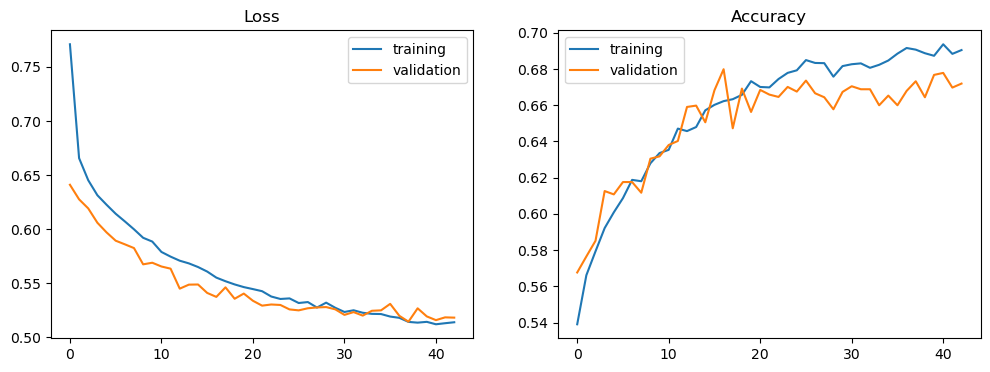

In [1343]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(history_v3.history["loss"], label="training")
axes[0].plot(history_v3.history["val_loss"], label="validation")
axes[0].set_title("Loss")
axes[0].legend()

# Accuracy
axes[1].plot(history_v3.history["accuracy"], label="training")
axes[1].plot(history_v3.history["val_accuracy"], label="validation")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.show()

The training curves show a controlled learning pattern for the tuned network. Both training and validation loss fall steadily and by the later epochs the two curves remain close rather than drifting apart sharply. Validation accuracy also improves gradually and stays fairly stable, while training accuracy continues to edge higher without creating an excessive gap.

Compared with the earlier unregularised model, the signs of overfitting are much weaker here. Compared with the regularised network in v2, the main difference is not a dramatic change in curve shape but a slightly stronger and more consistent validation profile. This is the kind of behaviour expected from successful tuning: not a chaotic jump in performance but a small improvement built on an already stable specification.

The curves therefore support the view that the tuned network is learning efficiently without losing the generalisation benefits introduced in v2.

Neural Network v3 - Validation
Accuracy : 0.6732
ROC-AUC  : 0.7902
PR-AUC   : 0.6221

Neural Network v3 - Test
Accuracy : 0.6718
ROC-AUC  : 0.7855
PR-AUC   : 0.6117

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.64      0.74      3909
         1.0       0.45      0.74      0.56      1517

    accuracy                           0.67      5426
   macro avg       0.66      0.69      0.65      5426
weighted avg       0.75      0.67      0.69      5426



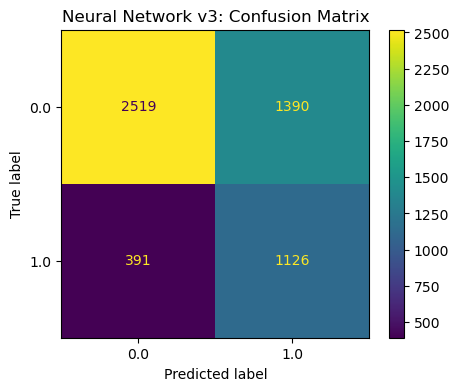

In [1344]:
# Validation predictions
nn_v3_prob_val = nn_v3.predict(X_val_nn, verbose=0).ravel()
nn_v3_pred_val = (nn_v3_prob_val >= 0.5).astype(int)

nn_v3_acc_val = accuracy_score(y_val_nn, nn_v3_pred_val)
nn_v3_auc_val = roc_auc_score(y_val_nn, nn_v3_prob_val)
nn_v3_pr_val  = average_precision_score(y_val_nn, nn_v3_prob_val)

print("Neural Network v3 - Validation")
print("Accuracy :", round(nn_v3_acc_val, 4))
print("ROC-AUC  :", round(nn_v3_auc_val, 4))
print("PR-AUC   :", round(nn_v3_pr_val, 4))

# Test predictions
nn_v3_prob_test = nn_v3.predict(X_test_nn, verbose=0).ravel()
nn_v3_pred_test = (nn_v3_prob_test >= 0.5).astype(int)

nn_v3_acc_test = accuracy_score(y_test_nn, nn_v3_pred_test)
nn_v3_auc_test = roc_auc_score(y_test_nn, nn_v3_prob_test)
nn_v3_pr_test  = average_precision_score(y_test_nn, nn_v3_prob_test)

print("\nNeural Network v3 - Test")
print("Accuracy :", round(nn_v3_acc_test, 4))
print("ROC-AUC  :", round(nn_v3_auc_test, 4))
print("PR-AUC   :", round(nn_v3_pr_test, 4))

print("\nClassification Report:")
print(classification_report(y_test_nn, nn_v3_pred_test))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test_nn, nn_v3_pred_test, ax=ax)
ax.set_title("Neural Network v3: Confusion Matrix")
plt.show()

The tuned network delivers the strongest overall results in the modelling section. On the validation set, it achieves an accuracy of 0.6732, a ROC-AUC of 0.7902,and a PR-AUC of 0.6221. On the test set, it records an accuracy of 0.6718, a ROC-AUC of 0.7855 and a PR-AUC of 0.6117.

These figures show that tuning adds value, although the gain is incremental rather than dramatic. Relative to v2, the tuned network improves test accuracy from 0.6447 to 0.6718, lifts ROC-AUC from 0.7702 to 0.7855 and raises PR-AUC from 0.5915 to 0.6117. That pattern indicates that the tuning step does not merely reshape the threshold-based predictions; it also improves the model’s ability to rank purchased quotes ahead of non-purchased ones.

Another reassuring feature is the small gap between validation and test performance. The validation ROC-AUC of 0.7902 and test ROC-AUC of 0.7855 are closely aligned and the same is true for PR-AUC. This supports the view that the tuned specification has not simply adapted to the validation set but is carrying its gains through to unseen data.

The classification report shows that the tuned network keeps a useful balance between identifying purchased quotes and controlling false alarms. For class 0, precision is 0.87 and recall is 0.64, which means the model remains reliable when predicting non-purchase while also recovering a reasonable share of those cases. For class 1, recall reaches 0.74 and precision rises to 0.45, giving the tuned model its strongest positive-class precision so far while still maintaining strong sensitivity to actual purchasers.

The confusion matrix gives the same message in raw counts. The model correctly identifies 1,126 purchased quotes and misses 391, while also correctly classifying 2,519 non-purchased quotes. False positives remain substantial at 1,390, so the model is still not conservative when flagging likely purchasers but this is partly the cost of maintaining high recall for the minority class.

Compared with the earlier neural networks, this version offers the most attractive compromise. It captures purchased quotes more effectively than logistic regression and it also improves the precision of positive predictions relative to the previous neural network specifications. In practical terms, this makes it the strongest candidate for prioritising leads or supporting targeted intervention, especially in a setting where missing real purchasers is more costly than reviewing some additional false positives.

---

# **6. Model Comparison and Interpretation**

## 6.1 Final Test Set Comparison

This section compares the final models using only the test set. Validation results were used earlier for model development and tuning but the final comparison is based on test performance so that all models are assessed on the same untouched out-of-sample data.

Because the target class is imbalanced, the main comparison focuses on ROC-AUC and PR-AUC, while accuracy is treated as a secondary metric.

In [ ]:
# final test set comparison across all candidate models
# only test metrics are used here because validation results were already used during model development
comparison_test = pd.DataFrame({
    "model": [
        "LR default",
        "LR tuned",
        "NN v1",
        "NN v2",
        "NN v3"
    ],
    "test_accuracy": [
        lr_default_acc_test,
        lr_tuned_acc_test,
        nn_v1_acc_test,
        nn_v2_acc_test,
        nn_v3_acc_test
    ],
    "test_roc_auc": [
        lr_default_auc_test,
        lr_tuned_auc_test,
        nn_v1_auc_test,
        nn_v2_auc_test,
        nn_v3_auc_test
    ],
    "test_pr_auc": [
        lr_default_pr_test,
        lr_tuned_pr_test,
        nn_v1_pr_test,
        nn_v2_pr_test,
        nn_v3_pr_test
    ]
})

comparison_test = comparison_test.sort_values("test_roc_auc", ascending=False)
comparison_test.round(4)

,model,test_accuracy,test_roc_auc,test_pr_auc
4,NN v3,0.6718,0.7855,0.6117
3,NN v2,0.6447,0.7702,0.5915
2,NN v1,0.6502,0.7409,0.5500
0,LR default,0.6017,0.6925,0.4375
1,LR tuned,0.6006,0.6921,0.4359


The final test set comparison shows a clear ranking across the five models. Neural Network v3 achieves the strongest overall performance, with a test accuracy of 0.6718, a ROC-AUC of 0.7855 and a PR-AUC of 0.6117. Neural Network v2 ranks second, followed by Neural Network v1. Both logistic regression models perform substantially worse on the ranking-based measures.

This ordering is important because the target class is imbalanced, so the main emphasis is placed on ROC-AUC and PR-AUC rather than accuracy alone. On both of these metrics, all three neural networks outperform the logistic regression benchmarks by a clear margin. This indicates that the relationship between the predictors and quote purchase is not fully captured by a linear decision boundary and that the more flexible neural network models extract additional predictive signal from the dataset.

Another notable result is that the tuned logistic regression model does not improve meaningfully over the default specification. Its test ROC-AUC and PR-AUC are slightly below the default logistic model, which suggests that tuning the regularisation strength does not materially change the predictive ceiling of the linear approach in this case.

## 6.2 Interpretation of the Ranking

The ranking of the models reveals two main patterns. First, the shift from logistic regression to feedforward neural networks produces a clear improvement in predictive performance. This is visible not only in accuracy but more importantly in ROC-AUC and PR-AUC, which are the more informative measures in this imbalanced classification setting. The result suggests that the modelling problem contains non-linear structure that the neural networks are better able to capture.

Second, the progression from Neural Network v1 to v2 and then to v3 shows that the improvements were not driven by adding complexity blindly. The unregularised network already outperforms logistic regression however the regularised version improves further, which shows that controlling overfitting was useful. The tuned network then delivers another lift, indicating that careful adjustment of the learning rate, dropout, architecture and batch size improves generalisation rather than simply fitting the training data more closely.

Taken together, the results support a consistent modelling story: model flexibility helps, regularisation helps and tuning helps most when it is applied to an already sensible regularised specification.

## 6.3 Preferred Final Model

Based on the final test set comparison, Neural Network v3 is the preferred model. It records the highest test accuracy, the highest ROC-AUC and the highest PR-AUC among all candidates. This means it provides the strongest overall discrimination between purchased and non-purchased quotes and the best ranking of likely purchasers.

The preference for Neural Network v3 is not based on a single metric in isolation. Its advantage is consistent across the main evaluation measures and its validation and test results are also closely aligned, which supports the view that its performance is stable rather than accidental. For that reason, Neural Network v3 is taken forward as the final recommended predictive model.

To conlcude,  the comparison shows that the neural network models outperform the logistic regression benchmarks by a substantial margin on the final test set. Among them, Neural Network v3 delivers the strongest results on all three reported metrics and therefore stands out as the best final model. The modelling exercise also shows that regularisation and targeted tuning improve neural network performance in a meaningful way, whereas tuning makes very little difference for logistic regression. The final recommendation is therefore based on Neural Network v3.

----

# **7. Recommendation to Telepass**

## 7.1 Commercial Recommendations

First, outreach should focus on customers who are already active in the Telepass ecosystem.In the exploratory analysis, customers with observed prior transaction history converted at 29.19% compared with 27.43% for those with no history. Among those with history, buyers had a mean prior spend of roughly €180 compared with €96 for non-buyers and those with any TelepassPay usage converted at 31.11% versus 28.08% for those without. The predictive models point in the same direction. Performance improved once behavioural variables were included alongside traditional quote characteristics. In practical terms, outreach should be directed first at customers with an established platform relationship. Timing also matters: the data shows that buyers had on average 37 days remaining on their current policy at quote time, compared with 77 days for non-buyers. Conversion appears stronger closer to renewal, so outreach should be concentrated in the weeks before policy expiry rather than sent too early.

Second, price competitiveness should be treated as the main commercial lever. The exploratory analysis showed a clearer difference in final quoted sale price than in discount generosity. Issued quotes had a mean sale price of approximately €399, compared with €467 for non-issued quotes, a gap of roughly €68 at the mean. Discount percentages and discount amounts showed weaker differences, suggesting customers respond more to the price they actually see than to the size of the reduction from a higher base. Broker-level differences compound this: conversion rates vary from about 13% for broker 5 to around 32% for broker 2, with the remaining brokers falling in between. This variation is large enough to be practically significant. Broker routing and insurer negotiation should therefore be treated as an immediate operational priority. These broker differences are still descriptive rather than causal but they are consistent and large enough to justify closer monitoring and targeted testing.

Third, the strongest model should be used as a lead scoring tool rather than as a fully automated decision rule. The tuned neural network delivered the best out-of-sample performance, with a test ROC-AUC of 0.7855 and a PR-AUC of 0.6117, outperforming both logistic regression benchmarks and the simpler neural network versions. Its recall for the purchased class is relatively strong at 0.74, meaning it captures a large share of true purchasers. Precision is more moderate at 0.45, so the model should not be treated as a reliable individual-level classifier. Its practical value is as a ranking tool: scoring all eligible subscribers by predicted purchase probability before each outreach campaign, then directing sales effort toward the highest-scoring segment. This would improve the commission yield per contact without requiring any change to the underlying brokerage infrastructure.

Together, these three recommendations can be implemented within the existing brokerage model. The more fundamental question is whether Telepass should remain a broker at all or move in a different strategic direction.

## 7.2 Strategic Direction

The results favour continuing with the brokerage model rather than moving into direct insurance provision. The available dataset works well for analysing quote conversion but it does not contain realised claims, loss ratios or other direct measures of underwriting risk. That is an important limitation. Mobility and transaction data may help explain who is more likely to buy insurance but they do not show whether those customers are profitable to insure. Without claims information, there is no solid basis for setting premiums or managing underwriting risk. Moving into direct provision at this stage would expose Telepass to pricing mistakes and adverse selection that the risk of attracting customers who are systematically more expensive to insure than the premiums reflect.

The third strategic option is the prioritising further TelepassPay expansion. Thhis is not directly testable with this dataset but the EDA offers a relevant observation. Only around 30% of customers in the insurance quotes dataset have any prior transaction history at all. This could be mean that most quoted customers are not yet deeply embedded in the TelepassPay ecosystem. Growing that base would likely improve the effectiveness of future insurance targeting, since behavioural engagement is positively associated with conversion. In that sense, TelepassPay expansion and brokerage improvement are complements rather than alternatives. A broader platform base creates a larger pool of engaged customers to whom insurance offers are more likely to convert, so investment in platform growth strengthens the long-run case for the brokerage model rather than undermining it.

Based on analyses, the most defensible short run path is to strengthen and optimise the brokerage model using the tools already in place for better targeting, better broker routing and model assisted lead scoring, while continuing to grow TelepassPay engagement as a foundation for future cross-selling.The case also highlights that insurers already use black-box telematics to price driving risk and whether Telepass’s mobility data could outperform that benchmark remains unresolved.

---

# **8. Limitations, Ethics and Next Steps**

## 8.1 Main Limitations of the Analysis

This analysis has an important boundary: it explains and predicts quote conversion, not underlying insurance risk. That distinction matters for the managerial decision. The available data make it possible to study which quotes are more likely to be purchased but they do not observe realised claims, loss ratios or the full economics of underwriting. As a result, the models are useful for improving the current brokerage activity but they cannot establish whether Telepass is ready to price risk as a direct insurer. This is also consistent with the assignment brief, which explicitly notes that the dataset supports the study of quote conversion but does not directly observe realised insurance claims.

A second limitation is that the data come from a very unusual period. The case is set in 2020, when Italy was experiencing repeated COVID disruption and restrictions on mobility. That means several behavioural variables, especially those linked to transactions, travel intensity and platform usage, may partly reflect temporary conditions rather than stable long-run patterns. For this reason, the behavioural signals identified in the notebook should be treated as useful but time-specific, rather than as fixed facts about customer behaviour. 

A third limitation is interpretive rather than technical. Several relationships in the exploratory analysis are descriptive, not causal. For example, broker level differences, subscription status, transaction activity and price related differences are commercially relevant however, they do not by themselves prove what would happen under an intervention. A higher conversion rate for one broker does not automatically mean that routing every customer to that broker would produce the same result, because customer mix, quote mix and insurer appetite may also differ across partners.

Finally, the predictive models should not be overread. Even the strongest model improves ranking and prioritisation but it is not a perfect classifier. That means the output is most useful for supporting commercial decisions such as lead scoring, targeting and testing, rather than replacing human judgement altogether.


## 8.2 Ethics and Regulatory Considerations


The ethical side of this project is closely tied to the way Telepass collects and uses customer data. The case makes clear that data use is governed by explicit consent rules. Subscribers had to accept data use for service delivery in order to join TelepassPay, while targeted offers required a separate permission. Telepass could analyse user data in aggregate to understand patterns and build models but personalised offers could only be sent to customers who had explicitly agreed to that use. This creates a clear practical constrain. Even if the model identifies a high-probability prospect that prediction should not be used for personalised marketing unless the relevant consent is in place. 

There is also a broader fairness issue. Behavioural and demographic variables can improve prediction but they may also create unequal treatment if they are used mechanically. In a brokerage setting, this risk is more limited because the model is being used to prioritise outreach rather than to set premiums directly. However, if Telepass were to move toward direct insurance provision, the ethical stakes would become much higher, because model outputs could start affecting prices, eligibility or product access. At that point, questions of explainability, fairness and regulatory compliance would become much more central.

A related issue concerns purpose limitation. Telepass’s data were originally generated through tolling, payments and platform usage. Using those data to improve the relevance of mobility services or insurance offers may be commercially attractive but it also requires discipline. The fact that data exist does not mean every possible use is equally justified. The model should therefore be framed as a tool for improving customer relevance and operational efficiency within the existing consent framework, not as a licence for unrestricted profiling.

There is also an ethical distinction between predicting purchase and predicting risk. A customer who is more likely to buy insurance is not necessarily a safer or more profitable customer to insure. Treating conversion propensity as if it were a measure of underwriting quality would be a mistake, both analytically and ethically. This reinforces the case for caution about any move into direct underwriting, quite apart from the commercial and data limitations already noted.

A related concern is that the engineered missingness indicators, particularly age_missing, which captures 37.7% of observations largely concentrated among company accounts. This means the model treats customers with incomplete profiles as a distinct group. This may be analytically appropriate but should be monitored for differential treatment effects in deployment.

## 8.3 Next Steps

The first practical next step is operational testing inside the current brokerage model. The tuned neural network can be used to rank prospects by predicted purchase probability but that ranking should be evaluated through controlled commercial pilots rather than assumed to be optimal automatically. A sensible next step would be to compare model-based targeting against the current outreach process and measure whether it improves conversion, commission yield or customer response rates.

The second next step is to strengthen the evidence base around partner and pricing decisions. The analysis suggests that final price matters more clearly than discount generosity and it also shows meaningful broker-level conversion differences. The next stage should therefore include structured commercial testing: for example, monitoring whether certain brokers consistently convert better after controlling more carefully for quote characteristics and testing whether price improvements generate larger gains than broader discount campaigns.

The third next step is methodological. Future model development should place more emphasis on robustness over a longer time horizon. That includes checking whether model performance remains stable across different months, whether the same behavioural variables remain predictive outside the COVID period and whether the ranking performance is still strong when the commercial environment changes.

he final next step is strategic. If Telepass were to revisit direct insurance provision, the essential prerequisite would be access to realised claims data and without that, the conversion evidence developed here is useful for brokerage but insufficient for underwriting.

---

# **9. References**

AI use statement: Claude AI and ChatGPT were used for brainstorming structure and for limited editing support. All final wording choices, analytical decisions, interpretations and conclusions are the author’s own.

Abadi, M., et al. (2015). TensorFlow: Large-scale machine learning on heterogeneous systems (Version 2) [Software]. Google. https://www.tensorflow.org

Burato, M. (2026). Lecture 2: Data preprocessing and feature engineering [Lecture slides]. SMM760 Digital Technologies & People Analytics, Bayes Business School.

Burato, M. (2026). Lecture 3: Using TensorFlow to create and train neural networks  [Lecture notebook]. SMM768 Applied Deep Learning, Bayes Business School.

Burato, M. (2026). Tutorial 1: Implementing advanced procedures and algorithms in TensorFlow  [Tutorial notebook]. SMM768 Applied Deep Learning, Bayes Business School.

Farronato, C., Denicolai, S., & Mehta, S. (2021). *Telepass: From tolling to mobility platform*  (Case No. 9-622-011). Harvard Business School.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M.,  Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M.,  Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python.  Journal of Machine Learning Research*, 12, 2825–2830.

Zhu, R. (2026). Lecture 2: Classification — logistic regression and k nearest neighbours [Lecture slides]. SMM636 Machine Learning, Bayes Business School.